# Breast Cancer Classification Using a Stacking Ensemble with Feature Interpretation and Disagreement-Based Uncertainty Analysis

This notebook demonstrates a machine learning project focused on breast cancer classification. We build a practical pipeline that combines a stacking ensemble, feature-interpretation methods, cross-validation, and model disagreement analysis. The project aims not only to compare predictive performance but also to examine agreement among different explanation methods and to use model disagreement as a proxy for prediction uncertainty. The link to the repository is provided below.

**GitHub: https://github.com/ML-Disease-Classification/Machine-Learning-for-Breast-Cancer-Prediction**

## 0. Setup and Imports

In [ ]:
# Install necessary libraries
!pip install shap
!pip install eli5
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 3.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for dataset, models, preprocessing, and metrics
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, average_precision_score, precision_recall_curve, auc, classification_report
from sklearn.inspection import permutation_importance

# Model interpretation libraries
import shap
import eli5

# Set a global random state for reproducibility
RANDOM_STATE = 18
np.random.seed(RANDOM_STATE)

## 1. Data Loading and Initial Inspection

We will load the Breast Cancer Wisconsin (Diagnostic) dataset, which is a classic dataset for binary classification tasks. It contains features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass, describing characteristics of the cell nuclei present in the image.

In [ ]:
# 1. Scikit-learn WBDC Dataset
breast_cancer_sklearn = load_breast_cancer()
# Note: sklearn data is a numpy array; converting to DataFrame for comparison
X_sklearn = pd.DataFrame(breast_cancer_sklearn.data, columns=breast_cancer_sklearn.feature_names)
y_sklearn = pd.Series(breast_cancer_sklearn.target)

# --- Current active variables used in the notebook ---
# You can change these assignments to toggle between datasets
#X = X_uci
#y = y_uci

X = X_sklearn
y = y_sklearn

# Map target labels correctly:
# For sklearn: 0 is Malignant, 1 is Benign
# For UCI: 'M' is Malignant, 'B' is Benign
if isinstance(y.iloc[0], str):
    y_labels = y.map({'M': 'Malignant', 'B': 'Benign'})
else:
    y_labels = y.map({0: 'Malignant', 1: 'Benign'})

# Combine features and target into a single DataFrame for easier inspection
df = pd.concat([X, y_labels.rename('diagnosis')], axis=1)

print("Datasets loaded. Current choice: scikit-learn.")
display(df.head())

Datasets loaded. Current choice: scikit-learn.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Malignant


### Interpretation:
- The dataset contains 30 numerical features related to cell characteristics.
- The target variable `diagnosis` is binary, where `0` typically represents malignant and `1` represents benign (though in scikit-learn's `load_breast_cancer`, `0` is malignant and `1` is benign as per `target_names`). We've mapped them to 'Malignant' and 'Benign' for clarity.

## 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the structure, distributions, and relationships within our data. This step is crucial for identifying potential issues, patterns, and guiding preprocessing decisions.

In [ ]:
print("### Dataset Shape ###")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1} (excluding target)")
print(f"Full DataFrame shape: {df.shape}")

### Dataset Shape ###
Number of samples: 569
Number of features: 30 (excluding target)
Full DataFrame shape: (569, 31)


### Interpretation:
- The dataset contains 569 instances (patients) and 30 features, plus the target variable.

In [ ]:
print("### Missing Values ###")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if missing_values.empty:
    print("No missing values found in the dataset.")
else:
    print(missing_values)

print("\n### Data Types ###")
print(df.info())

### Missing Values ###
No missing values found in the dataset.

### Data Types ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 1

### Interpretation:
- Fortunately, this dataset is clean and has no missing values, simplifying our preprocessing steps.
- All features are numerical (float64), which is suitable for the chosen machine learning models.

### Class Distribution ###
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64
diagnosis
Benign       62.741652
Malignant    37.258348
Name: proportion, dtype: float64


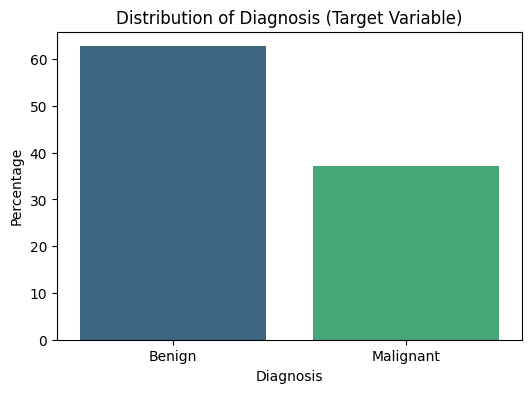

In [ ]:
print("### Class Distribution ###")
# Use the diagnosis column from our combined dataframe
class_counts = df['diagnosis'].value_counts()
class_distribution = df['diagnosis'].value_counts(normalize=True) * 100
print(class_counts)
print(class_distribution)

plt.figure(figsize=(6, 4))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis', hue=class_distribution.index, legend=False)
plt.title('Distribution of Diagnosis (Target Variable)')
plt.xlabel('Diagnosis')
plt.ylabel('Percentage')
plt.show()

### Interpretation:
- The dataset shows a class imbalance, with a higher proportion of benign cases (around 62.7%) compared to malignant cases (around 37.3%).
- This imbalance is common in medical datasets and should be considered during model evaluation (e.g., using stratified cross-validation and metrics like F1-score and ROC-AUC).

In [ ]:
print("### Summary Statistics ###")
display(X.describe())

### Summary Statistics ###


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### Interpretation:
- The summary statistics (mean, std, min, max, quartiles) show that features are on different scales. For instance, 'mean radius' ranges from 6.98 to 28.11, while 'mean area' ranges from 143.5 to 2501.0.
- This indicates that feature scaling (e.g., using `StandardScaler`) will be important for models sensitive to feature scales, such as Logistic Regression and K-Nearest Neighbors.

### Correlation Heatmap ###


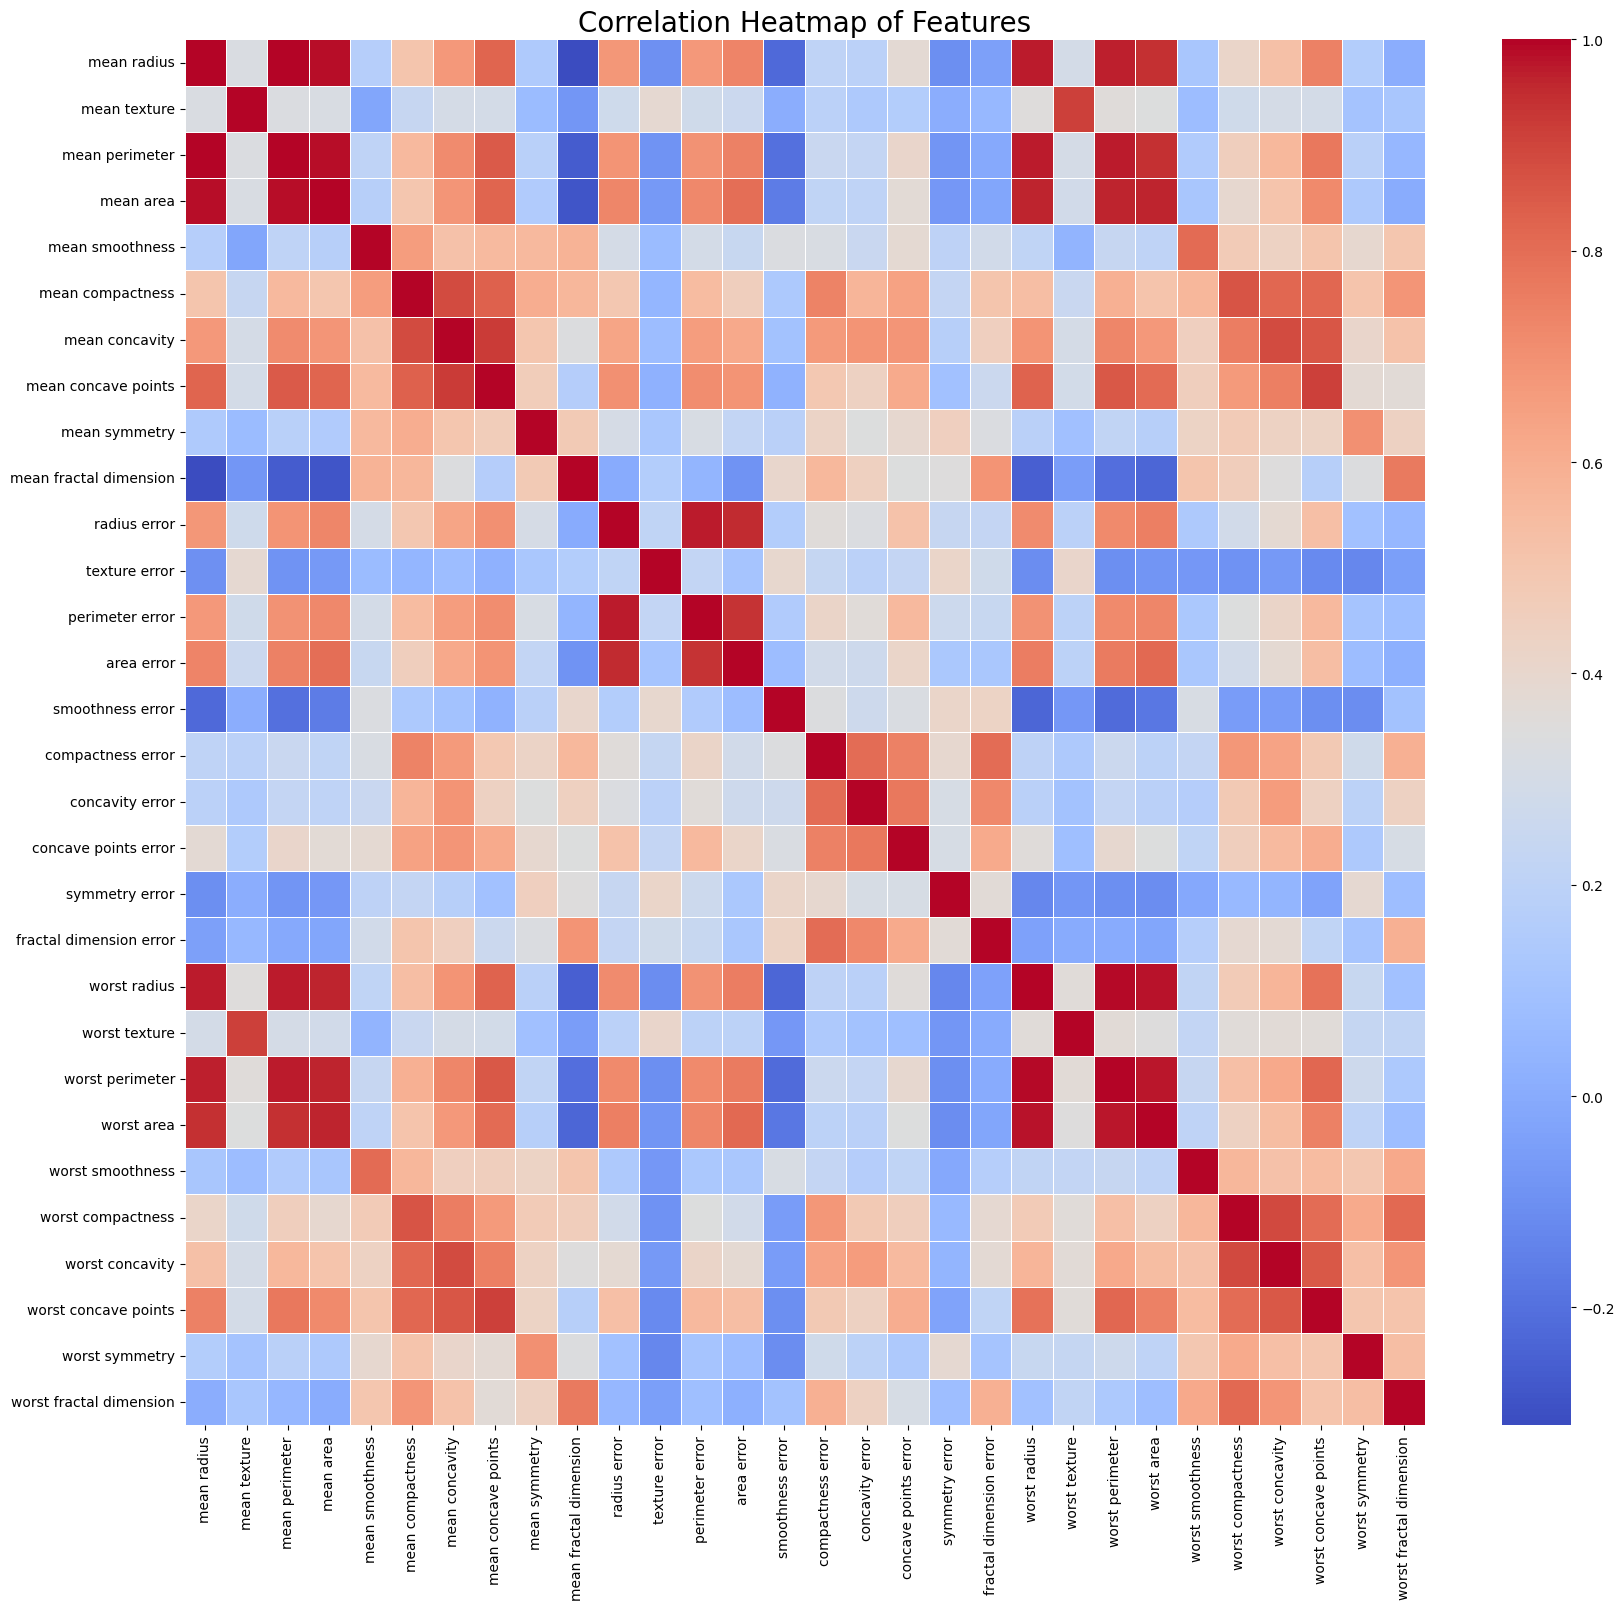

In [ ]:
print("### Correlation Heatmap ###")
plt.figure(figsize=(20, 18))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

### Interpretation:
- The heatmap reveals strong correlations among many features, particularly within groups of features (e.g., 'radius', 'perimeter', 'area' often show high positive correlation for mean, standard error, and worst values).
- High correlation might indicate multicollinearity, which can affect the interpretability of linear models like Logistic Regression. Ensemble models like Random Forest are generally more robust to multicollinearity.

## 3. Data Preparation for Modeling

### 3.1 Hold-Out Split for Final Evaluation

Before any tuning, cross-validation, or stacking, the dataset is split once into a **70% development set** and a **30% held-out test set**.  
Only the 70% development set is used for tuning, K-fold cross-validation, and training the stacking meta-learner. The 30% test set remains untouched until the very end for final evaluation. This prevents information from the test set from leaking into model selection or preprocessing steps.


In [ ]:

X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Development set shape (70%): {X_train_70.shape}")
print(f"Held-out test set shape (30%): {X_test_30.shape}")
print("Class distribution in development set:")
display(y_train_70.value_counts(normalize=True).rename("proportion").to_frame())
print("Class distribution in held-out test set:")
display(y_test_30.value_counts(normalize=True).rename("proportion").to_frame())

Development set shape (70%): (398, 30)
Held-out test set shape (30%): (171, 30)
Class distribution in development set:


,proportion
1,0.628141
0,0.371859


Class distribution in held-out test set:


,proportion
1,0.625731
0,0.374269


In [ ]:
scaler_for_shap = StandardScaler()
X_train_70_scaled = scaler_for_shap.fit_transform(X_train_70)
X_test_30_scaled = scaler_for_shap.transform(X_test_30)

# Convert back to DataFrame with column names for SHAP and eli5 to work correctly
X_train_70_scaled = pd.DataFrame(X_train_70_scaled, columns=X_train_70.columns, index=X_train_70.index)
X_test_30_scaled = pd.DataFrame(X_test_30_scaled, columns=X_test_30.columns, index=X_test_30.index)

print("Scaled versions of training and testing data created for SHAP explainers.")

Scaled versions of training and testing data created for SHAP explainers.


For modeling, we need to explicitly separate our features (`X`) from our target variable (`y`). We also prepare for feature scaling, which will be applied carefully within each cross-validation fold to prevent data leakage.

In [ ]:
# Using the scikit-learn variables defined in the loading step
X = X_sklearn
y = y_sklearn

print("Features (X) and target (y) are updated from scikit-learn.")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
display(X.head())

Features (X) and target (y) are updated from scikit-learn.
X shape: (569, 30)
y shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4. Hyperparameter Tuning

Before proceeding to cross-validation and evaluation, we will perform hyperparameter tuning for each of our base models. This is crucial for optimizing their performance. We will use `GridSearchCV` with predefined search spaces to find the best parameters for Logistic Regression, Random Forest, and K-Nearest Neighbors. We perform tuning on the entire `X` and `y` before the main cross-validation loop to find optimal parameters for the general dataset structure, and then use these optimized models within the cross-validation.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from scipy.stats import randint, loguniform
import numpy as np

print("### Randomized Hyperparameter Tuning for Base Models (Training 70% only) ###")

tuning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Keep malignant coded as it already is
POS_LABEL = 'M' if isinstance(y.iloc[0], str) else 0

# Custom scorer that always treats malignant as the positive class
# Uses decision_function when available, otherwise predict_proba
def malignant_roc_auc(estimator, X_val, y_val):
    y_true_bin = (np.asarray(y_val) == POS_LABEL).astype(int)

    if hasattr(estimator, "decision_function"):
        y_score = estimator.decision_function(X_val)
    else:
        y_proba = estimator.predict_proba(X_val)
        pos_col_idx = list(estimator.classes_).index(POS_LABEL)
        y_score = y_proba[:, pos_col_idx]

    return roc_auc_score(y_true_bin, y_score)

# -----------------------------
# Logistic Regression
# -----------------------------
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_STATE))
])

param_dist_lr = {
    'clf__C': loguniform(1e-2, 1e1),
    'clf__penalty': ['l2'],
    'clf__solver': ['liblinear', 'lbfgs'],
    'clf__max_iter': [2000],
    'clf__class_weight': [None, 'balanced']
}

random_search_lr = RandomizedSearchCV(
    estimator=pipeline_lr,
    param_distributions=param_dist_lr,
    n_iter=10,
    cv=tuning_cv,
    scoring=malignant_roc_auc,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

random_search_lr.fit(X_train_70, y_train_70)
best_lr_params = {k.replace('clf__', ''): v for k, v in random_search_lr.best_params_.items()}
print(f"Best LR params: {best_lr_params}")

# -----------------------------
# Random Forest
# -----------------------------
param_dist_rf = {
    'n_estimators': randint(150, 251),
    'max_depth': [None, 8, 10, 12],
    'min_samples_split': [2, 5, 8],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist_rf,
    n_iter=12,
    cv=tuning_cv,
    scoring=malignant_roc_auc,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

random_search_rf.fit(X_train_70, y_train_70)
best_rf_params = random_search_rf.best_params_
print(f"Best RF params: {best_rf_params}")

# -----------------------------
# K-Nearest Neighbors
# -----------------------------
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_dist_knn = {
    'knn__n_neighbors': randint(8, 21),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2],
    'knn__metric': ['minkowski']
}

random_search_knn = RandomizedSearchCV(
    estimator=pipeline_knn,
    param_distributions=param_dist_knn,
    n_iter=10,
    cv=tuning_cv,
    scoring=malignant_roc_auc,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

random_search_knn.fit(X_train_70, y_train_70)
best_knn_params = {k.replace('knn__', ''): v for k, v in random_search_knn.best_params_.items()}
print(f"Best KNN params: {best_knn_params}")


# -----------------------------
# SVC
# -----------------------------
pipeline_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=RANDOM_STATE, probability=True))
])

param_dist_svc = {
    'svc__C': loguniform(5e-1, 2e1),
    'svc__kernel': ['rbf'],
    'svc__gamma': ['scale', 'auto'],
    'svc__class_weight': [None, 'balanced']
}

random_search_svc = RandomizedSearchCV(
    estimator=pipeline_svc,
    param_distributions=param_dist_svc,
    n_iter=10,
    cv=tuning_cv,
    scoring=malignant_roc_auc,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

random_search_svc.fit(X_train_70, y_train_70)
best_svc_params = {k.replace('svc__', ''): v for k, v in random_search_svc.best_params_.items()}
print(f"Best SVC params: {best_svc_params}")


# -----------------------------
# XGBoost
# Faster because of tree_method='hist'
# -----------------------------
param_dist_xgb = {
    'n_estimators': randint(150, 281),
    'max_depth': randint(3, 7),
    'learning_rate': loguniform(1e-2, 1e-1),
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_weight': randint(3, 7),
    'gamma': [0, 0.1, 0.2, 0.3]
}

random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        tree_method='hist',
        verbosity=0
    ),
    param_distributions=param_dist_xgb,
    n_iter=12,
    cv=tuning_cv,
    scoring=malignant_roc_auc,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

random_search_xgb.fit(X_train_70, y_train_70)
best_xgb_params = random_search_xgb.best_params_
print(f"Best XGB params: {best_xgb_params}")


### Randomized Hyperparameter Tuning for Base Models (Training 70% only) ###
Best LR params: {'C': np.float64(4.323190895817236), 'class_weight': None, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'liblinear'}
Best RF params: {'class_weight': 'balanced_subsample', 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 176}
Best KNN params: {'metric': 'minkowski', 'n_neighbors': 19, 'p': 2, 'weights': 'distance'}
Best SVC params: {'C': np.float64(12.780335925787838), 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
Best XGB params: {'colsample_bytree': 0.9, 'gamma': 0.2, 'learning_rate': np.float64(0.033188614180416416), 'max_depth': 4, 'min_child_weight': 6, 'n_estimators': 209, 'subsample': 0.9}


### Interpretation:
- The GridSearchCV output shows the best hyperparameters found for each model and their corresponding cross-validated ROC-AUC scores on the tuning training set. These optimized models (`best_lr`, `best_rf`, `best_knn`, `best_svc`, `best_xgb`) will now be used for the cross-validation and stacked ensemble creation.

## 4. Model Training and Cross-Validation

We will use Stratified K-Fold Cross-Validation to ensure robust model evaluation, especially given our class imbalance. This technique preserves the percentage of samples for each class in each fold. Within each fold, we will train individual models (Logistic Regression, Random Forest, K-Nearest Neighbors, SVC, and XGBoost). We then use a logistic regression-based meta learner as a stacking ensemble which takes the predictions of the 5 base learners as input for training. For the stacking model, `StackingClassifier(cv=skf)` is used so that the meta-learner is trained on **out-of-fold (OOF) predictions** from the base learners within each fold without leaking validation information.

### Cross-Validation Setup:
- `StratifiedKFold` ensures that each fold maintains the original class distribution, which is vital for imbalanced datasets.
- `StandardScaler` is applied within the pipelines for scale-sensitive models so that scaling parameters are learned only from the training portion of each fold.
- The `StackingClassifier` combines the strengths of the base learners by training a meta-learner on their cross-validated predictions.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# -----------------------------
# Base learners
# -----------------------------
log_reg = LogisticRegression(**best_lr_params, random_state=RANDOM_STATE)
rand_forest = RandomForestClassifier(**best_rf_params, random_state=RANDOM_STATE)
knn = KNeighborsClassifier(**best_knn_params)
svc = SVC(**best_svc_params, random_state=RANDOM_STATE, probability=True)
xgb = XGBClassifier(**best_xgb_params, random_state=RANDOM_STATE, eval_metric='logloss')

# Pipelines for scale-sensitive models
lr_pipeline = Pipeline([('scaler', StandardScaler()), ('model', log_reg)])
knn_pipeline = Pipeline([('scaler', StandardScaler()), ('model', knn)])
svc_pipeline = Pipeline([('scaler', StandardScaler()), ('model', svc)])

base_models = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rand_forest,
    'K-Nearest Neighbors': knn_pipeline,
    'SVC': svc_pipeline,
    'XGBoost': xgb
}

# -----------------------------
# CV setup on the 70% split
# -----------------------------
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Positive class stays as-is
# For sklearn breast cancer data, this will be 0, which corresponds to malignant
POS_LABEL = 'M' if isinstance(y.iloc[0], str) else 0

# -----------------------------
# Stacking template
# Used here only for outer-fold CV evaluation of the stacking model
# -----------------------------
stacking_template = StackingClassifier(
    estimators=[
        ('lr', Pipeline([('scaler', StandardScaler()),
                         ('model', LogisticRegression(**best_lr_params, random_state=RANDOM_STATE))])),
        ('rf', RandomForestClassifier(**best_rf_params, random_state=RANDOM_STATE)),
        ('knn', Pipeline([('scaler', StandardScaler()),
                          ('model', KNeighborsClassifier(**best_knn_params))])),
        ('svc', Pipeline([('scaler', StandardScaler()),
                          ('model', SVC(**best_svc_params, random_state=RANDOM_STATE, probability=True))])),
        ('xgb', XGBClassifier(**best_xgb_params, random_state=RANDOM_STATE, eval_metric='logloss'))
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, penalty='l2'),
    cv=skf,
    stack_method='predict_proba',
    n_jobs=-1
)

models = {**base_models, 'Stacking Ensemble': stacking_template}

# -----------------------------
# Storage for CV metrics
# -----------------------------
metrics = {
    'Accuracy': {name: [] for name in models},
    'Precision': {name: [] for name in models},
    'Recall': {name: [] for name in models},
    'F1-score': {name: [] for name in models},
    'F2-score': {name: [] for name in models}
}

# -----------------------------
# STEP 2 + STEP 3
# K-fold CV on the 70% set
# Generate OOF predictions for the base learners
# -----------------------------
base_model_names = list(base_models.keys())
oof_meta_train = np.zeros((X_train_70.shape[0], len(base_model_names)))

for train_idx, val_idx in skf.split(X_train_70, y_train_70):
    X_train_fold = X_train_70.iloc[train_idx]
    X_val_fold = X_train_70.iloc[val_idx]
    y_train_fold = y_train_70.iloc[train_idx]
    y_val_fold = y_train_70.iloc[val_idx]

    # Base models: fold metrics + OOF probabilities
    for j, (model_name, model) in enumerate(base_models.items()):
        fitted_model = clone(model)
        fitted_model.fit(X_train_fold, y_train_fold)

        y_pred = fitted_model.predict(X_val_fold)
        y_proba = fitted_model.predict_proba(X_val_fold)

        pos_col_idx = list(fitted_model.classes_).index(POS_LABEL)
        oof_meta_train[val_idx, j] = y_proba[:, pos_col_idx]

        metrics['Accuracy'][model_name].append(
            accuracy_score(y_val_fold, y_pred)
        )
        metrics['Precision'][model_name].append(
            precision_score(y_val_fold, y_pred, pos_label=POS_LABEL)
        )
        metrics['Recall'][model_name].append(
            recall_score(y_val_fold, y_pred, pos_label=POS_LABEL)
        )
        metrics['F1-score'][model_name].append(
            f1_score(y_val_fold, y_pred, pos_label=POS_LABEL)
        )
        metrics['F2-score'][model_name].append(
            fbeta_score(y_val_fold, y_pred, pos_label=POS_LABEL, beta=2)
        )

    # Stacking ensemble: outer-fold CV evaluation only
    fitted_stack = clone(stacking_template)
    fitted_stack.fit(X_train_fold, y_train_fold)
    y_pred_stack_cv = fitted_stack.predict(X_val_fold)

    metrics['Accuracy']['Stacking Ensemble'].append(
        accuracy_score(y_val_fold, y_pred_stack_cv)
    )
    metrics['Precision']['Stacking Ensemble'].append(
        precision_score(y_val_fold, y_pred_stack_cv, pos_label=POS_LABEL)
    )
    metrics['Recall']['Stacking Ensemble'].append(
        recall_score(y_val_fold, y_pred_stack_cv, pos_label=POS_LABEL)
    )
    metrics['F1-score']['Stacking Ensemble'].append(
        f1_score(y_val_fold, y_pred_stack_cv, pos_label=POS_LABEL)
    )
    metrics['F2-score']['Stacking Ensemble'].append(
        fbeta_score(y_val_fold, y_pred_stack_cv, pos_label=POS_LABEL, beta=2)
    )


# -----------------------------
# STEP 4
# Train meta-learner on OOF predictions from the 70% set
# -----------------------------
meta_learner = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, penalty='l2')
meta_learner.fit(oof_meta_train, y_train_70)

# -----------------------------
# STEP 5
# Retrain base learners on the full 70%
# -----------------------------
fitted_base_models = {}

for model_name, model in base_models.items():
    fitted_model = clone(model)
    fitted_model.fit(X_train_70, y_train_70)
    fitted_base_models[model_name] = fitted_model

# -----------------------------
# STEP 6
# Predict on 30% test set using refit base learners
# Pass those predictions to meta-learner
# -----------------------------
meta_test = np.zeros((X_test_30.shape[0], len(base_model_names)))

for j, model_name in enumerate(base_model_names):
    fitted_model = fitted_base_models[model_name]
    y_proba_test = fitted_model.predict_proba(X_test_30)
    pos_col_idx = list(fitted_model.classes_).index(POS_LABEL)
    meta_test[:, j] = y_proba_test[:, pos_col_idx]

y_pred_stack = meta_learner.predict(meta_test)
y_proba_stack = meta_learner.predict_proba(meta_test)
stack_pos_col_idx = list(meta_learner.classes_).index(POS_LABEL)
y_proba_stack_pos = y_proba_stack[:, stack_pos_col_idx]

# -----------------------------
# Final test-set evaluation for all models
# -----------------------------
test_results = {
    'Accuracy': {},
    'Precision': {},
    'Recall': {},
    'F1-score': {},
    'F2-score': {}
}

for model_name, fitted_model in fitted_base_models.items():
    y_pred_test = fitted_model.predict(X_test_30)

    test_results['Accuracy'][model_name] = accuracy_score(y_test_30, y_pred_test)
    test_results['Precision'][model_name] = precision_score(y_test_30, y_pred_test, pos_label=POS_LABEL)
    test_results['Recall'][model_name] = recall_score(y_test_30, y_pred_test, pos_label=POS_LABEL)
    test_results['F1-score'][model_name] = f1_score(y_test_30, y_pred_test, pos_label=POS_LABEL)
    test_results['F2-score'][model_name] = fbeta_score(y_test_30, y_pred_test, pos_label=POS_LABEL, beta=2)

test_results['Accuracy']['Stacking Ensemble'] = accuracy_score(y_test_30, y_pred_stack)
test_results['Precision']['Stacking Ensemble'] = precision_score(y_test_30, y_pred_stack, pos_label=POS_LABEL)
test_results['Recall']['Stacking Ensemble'] = recall_score(y_test_30, y_pred_stack, pos_label=POS_LABEL)
test_results['F1-score']['Stacking Ensemble'] = f1_score(y_test_30, y_pred_stack, pos_label=POS_LABEL)
test_results['F2-score']['Stacking Ensemble'] = fbeta_score(y_test_30, y_pred_stack, pos_label=POS_LABEL, beta=2)


## 5. Model Performance Evaluation

## 5.1. Performance Evaluation Metrics and Visualization

After running the cross-validation, we aggregate the metrics from each fold to get a robust estimate of each model's performance. We'll present the mean and standard deviation of each metric across the folds.


Cross-validation performance on the 70% development set after hyperparameter tuning


,Accuracy,Precision,Recall,F1-score,F2-score
Logistic Regression,0.9824 ± 0.0100,0.9798 ± 0.0165,0.9731 ± 0.0250,0.9762 ± 0.0137,0.9743 ± 0.0198
Random Forest,0.9623 ± 0.0137,0.9591 ± 0.0253,0.9393 ± 0.0248,0.9488 ± 0.0186,0.9430 ± 0.0211
K-Nearest Neighbors,0.9597 ± 0.0202,0.9926 ± 0.0148,0.8982 ± 0.0488,0.9424 ± 0.0298,0.9152 ± 0.0415
SVC,0.9749 ± 0.0079,0.9729 ± 0.0136,0.9595 ± 0.0131,0.9661 ± 0.0105,0.9621 ± 0.0115
XGBoost,0.9699 ± 0.0169,0.9726 ± 0.0257,0.9460 ± 0.0267,0.9590 ± 0.0229,0.9511 ± 0.0246
Stacking Ensemble,0.9874 ± 0.0113,0.9931 ± 0.0138,0.9731 ± 0.0250,0.9828 ± 0.0154,0.9769 ± 0.0208



Final performance on the untouched 30% held-out test set


,Accuracy,Precision,Recall,F1-score,F2-score
Logistic Regression,0.9708,0.9836,0.9375,0.9600,0.9464
Random Forest,0.9649,0.9677,0.9375,0.9524,0.9434
K-Nearest Neighbors,0.9415,0.9821,0.8594,0.9167,0.8814
SVC,0.9649,0.9833,0.9219,0.9516,0.9335
XGBoost,0.9415,0.9355,0.9062,0.9206,0.9119
Stacking Ensemble,0.9825,0.9841,0.9688,0.9764,0.9718


### Cross-Validation Model Performance with Error Bars ###


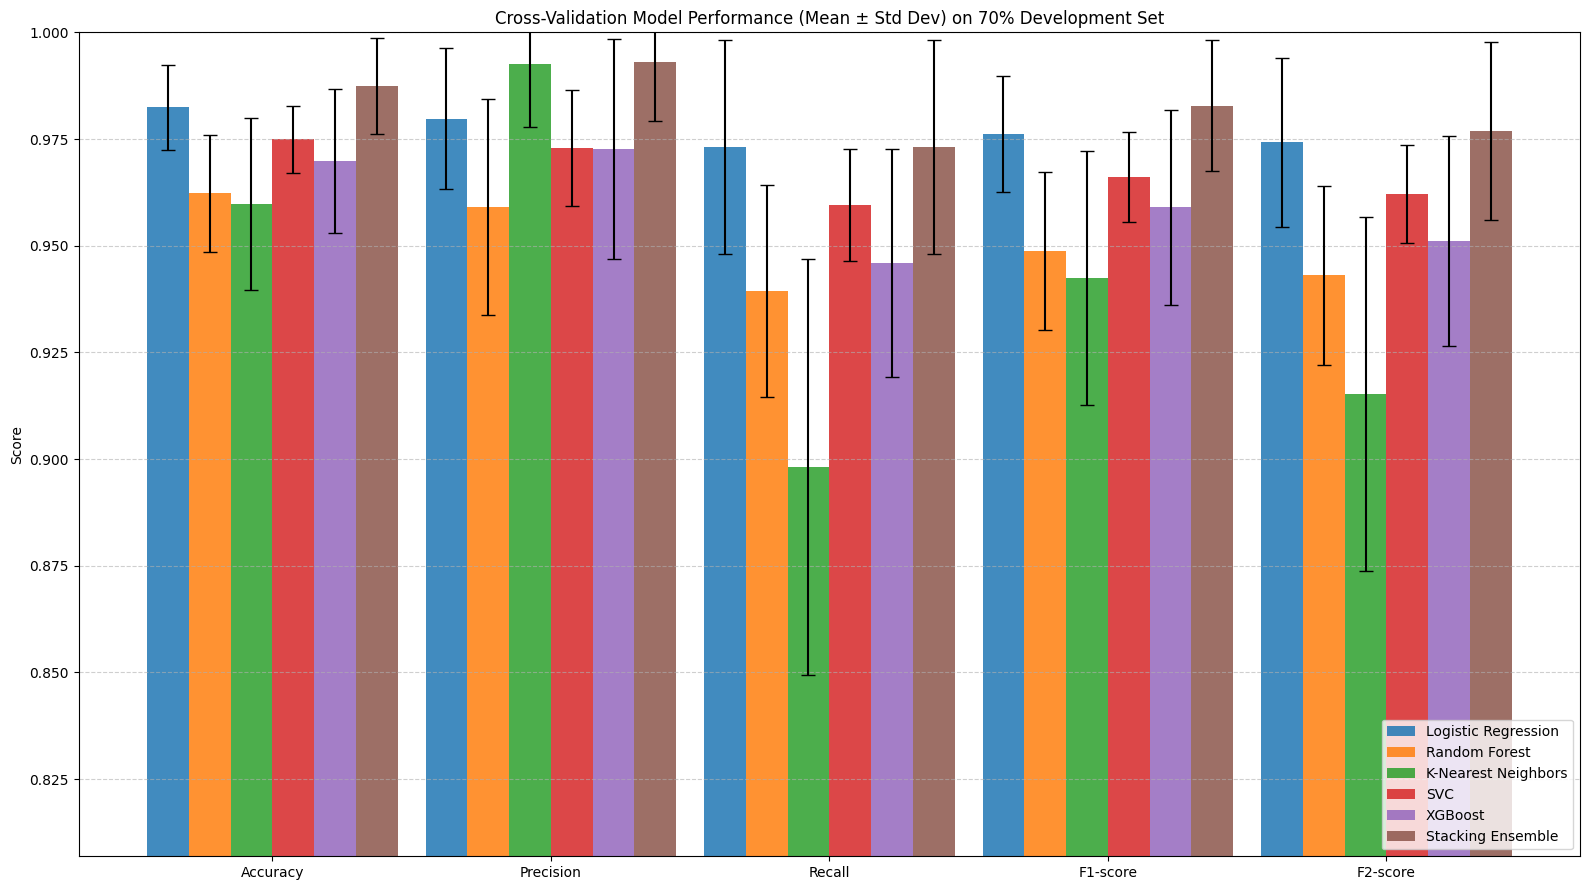

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score

# -----------------------------
# Summary tables
# -----------------------------
cv_summary = pd.DataFrame({
    metric_name: {
        model_name: f"{np.mean(scores):.4f} ± {np.std(scores):.4f}"
        for model_name, scores in metric_dict.items()
    }
    for metric_name, metric_dict in metrics.items()
})

test_summary = pd.DataFrame(test_results)
final_test_summary = test_summary.copy()

print("\nCross-validation performance on the 70% development set after hyperparameter tuning")
display(cv_summary)

print("\nFinal performance on the untouched 30% held-out test set")
display(final_test_summary.round(4))

class ManualStackingEnsemble:
    def __init__(self, fitted_base_models, meta_learner, pos_label):
        self.fitted_base_models = fitted_base_models
        self.meta_learner = meta_learner
        self.pos_label = pos_label
        self.classes_ = meta_learner.classes_

    def _build_meta_features(self, X):
        meta_features = np.zeros((X.shape[0], len(self.fitted_base_models)))
        for j, model_name in enumerate(self.fitted_base_models.keys()):
            fitted_model = self.fitted_base_models[model_name]
            y_proba = fitted_model.predict_proba(X)
            pos_col_idx = list(fitted_model.classes_).index(self.pos_label)
            meta_features[:, j] = y_proba[:, pos_col_idx]
        return meta_features

    def predict(self, X):
        meta_features = self._build_meta_features(X)
        return self.meta_learner.predict(meta_features)

    def predict_proba(self, X):
        meta_features = self._build_meta_features(X)
        return self.meta_learner.predict_proba(meta_features)

manual_stacking_model = ManualStackingEnsemble(
    fitted_base_models=fitted_base_models,
    meta_learner=meta_learner,
    pos_label=POS_LABEL
)

def get_positive_proba(model, X):
    y_proba = model.predict_proba(X)
    pos_col_idx = list(model.classes_).index(POS_LABEL)
    return y_proba[:, pos_col_idx]

final_models = {
    'Logistic Regression': fitted_base_models['Logistic Regression'],
    'Random Forest': fitted_base_models['Random Forest'],
    'K-Nearest Neighbors': fitted_base_models['K-Nearest Neighbors'],
    'SVC': fitted_base_models['SVC'],
    'XGBoost': fitted_base_models['XGBoost'],
    'Stacking Ensemble': manual_stacking_model
}

print("### Cross-Validation Model Performance with Error Bars ###")

# Prepare data for plotting
cv_plot_data = []
for metric_name, model_data in metrics.items():
    for model_name, scores in model_data.items():
        cv_plot_data.append({
            'Model': model_name,
            'Metric': metric_name,
            'Mean Score': np.mean(scores),
            'Std Dev': np.std(scores)
        })
cv_plot_df = pd.DataFrame(cv_plot_data)

model_order = cv_plot_df['Model'].unique()
metric_order = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'F2-score']

# Create a grouped bar chart with error bars
fig, ax = plt.subplots(figsize=(16, 9))

width = 0.15
x = np.arange(len(metric_order))

for i, model_name in enumerate(model_order):
    model_scores_df = cv_plot_df[cv_plot_df['Model'] == model_name].set_index('Metric').reindex(metric_order)
    mean_scores = model_scores_df['Mean Score'].values
    std_devs = model_scores_df['Std Dev'].values

    ax.bar(
        x + i * width - width * (len(model_order) - 1) / 2,
        mean_scores,
        width,
        yerr=std_devs,
        capsize=5,
        label=model_name,
        alpha=0.85
    )

ax.set_ylabel('Score')
ax.set_title('Cross-Validation Model Performance (Mean ± Std Dev) on 70% Development Set')
ax.set_xticks(x)
ax.set_xticklabels(metric_order)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_ylim(min(cv_plot_df['Mean Score'] - cv_plot_df['Std Dev']) * 0.95, 1.0)

plt.tight_layout()
plt.show()

### 5.2 Confusion Matrices for All Models

This section visualizes the confusion matrix for each of the base models and the stacking ensemble on the held-out test set. This allows for a direct comparison of true positives, true negatives, false positives, and false negatives across all classifiers.

### Confusion Matrices for All Models (Held-Out 30% Test Set) ###


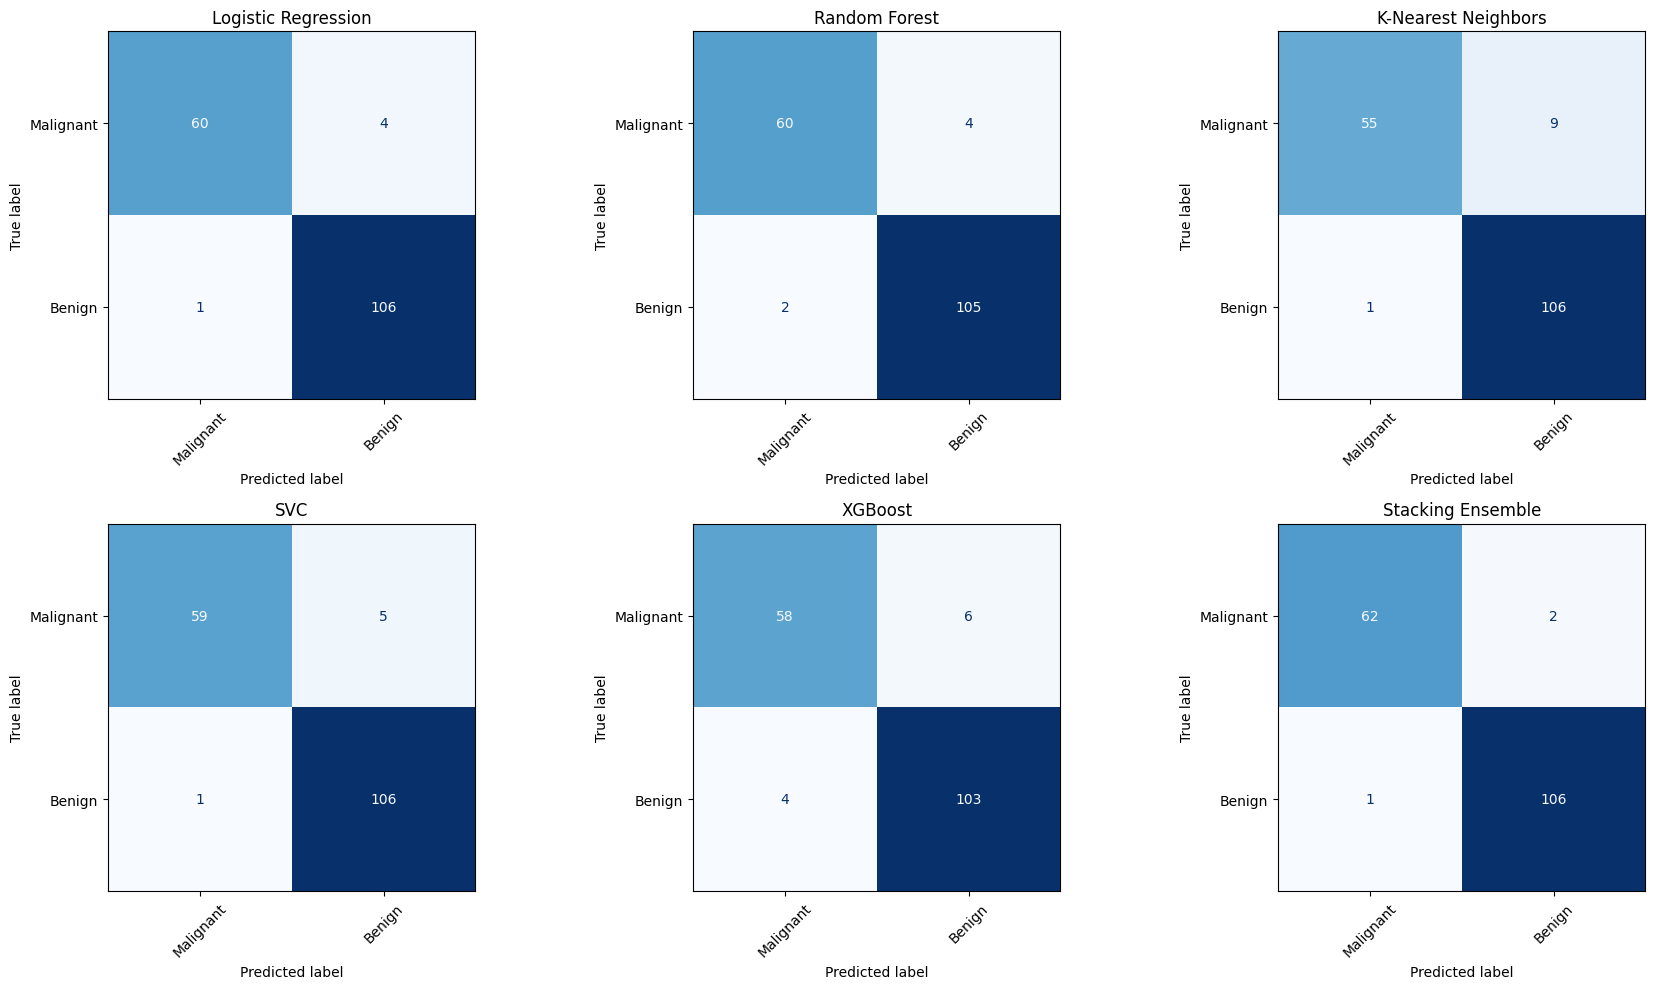

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

print("### Confusion Matrices for All Models (Held-Out 30% Test Set) ###")

num_models = len(final_models)
num_cols = 3
num_rows = (num_models + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 6, num_rows * 5))
axes = axes.flatten()

for i, (model_name, model) in enumerate(final_models.items()):
    y_pred = model.predict(X_test_30)

    # Explicit class order: malignant first, benign second
    label_order = [POS_LABEL] + [lbl for lbl in model.classes_ if lbl != POS_LABEL]
    display_labels = ['Malignant', 'Benign']

    cm = confusion_matrix(y_test_30, y_pred, labels=label_order)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues, ax=axes[i], values_format='d', colorbar=False)

    axes[i].set_title(f'{model_name}', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].tick_params(axis='y', rotation=0)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 5.3 ROC-AUC Curves for All Models

These plots show the Receiver Operating Characteristic (ROC) curve for each model. The ROC curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) provides a single number summary of the curve, representing the model's ability to distinguish between classes.

### ROC-AUC Curves for All Models (Held-Out 30% Test Set) ###


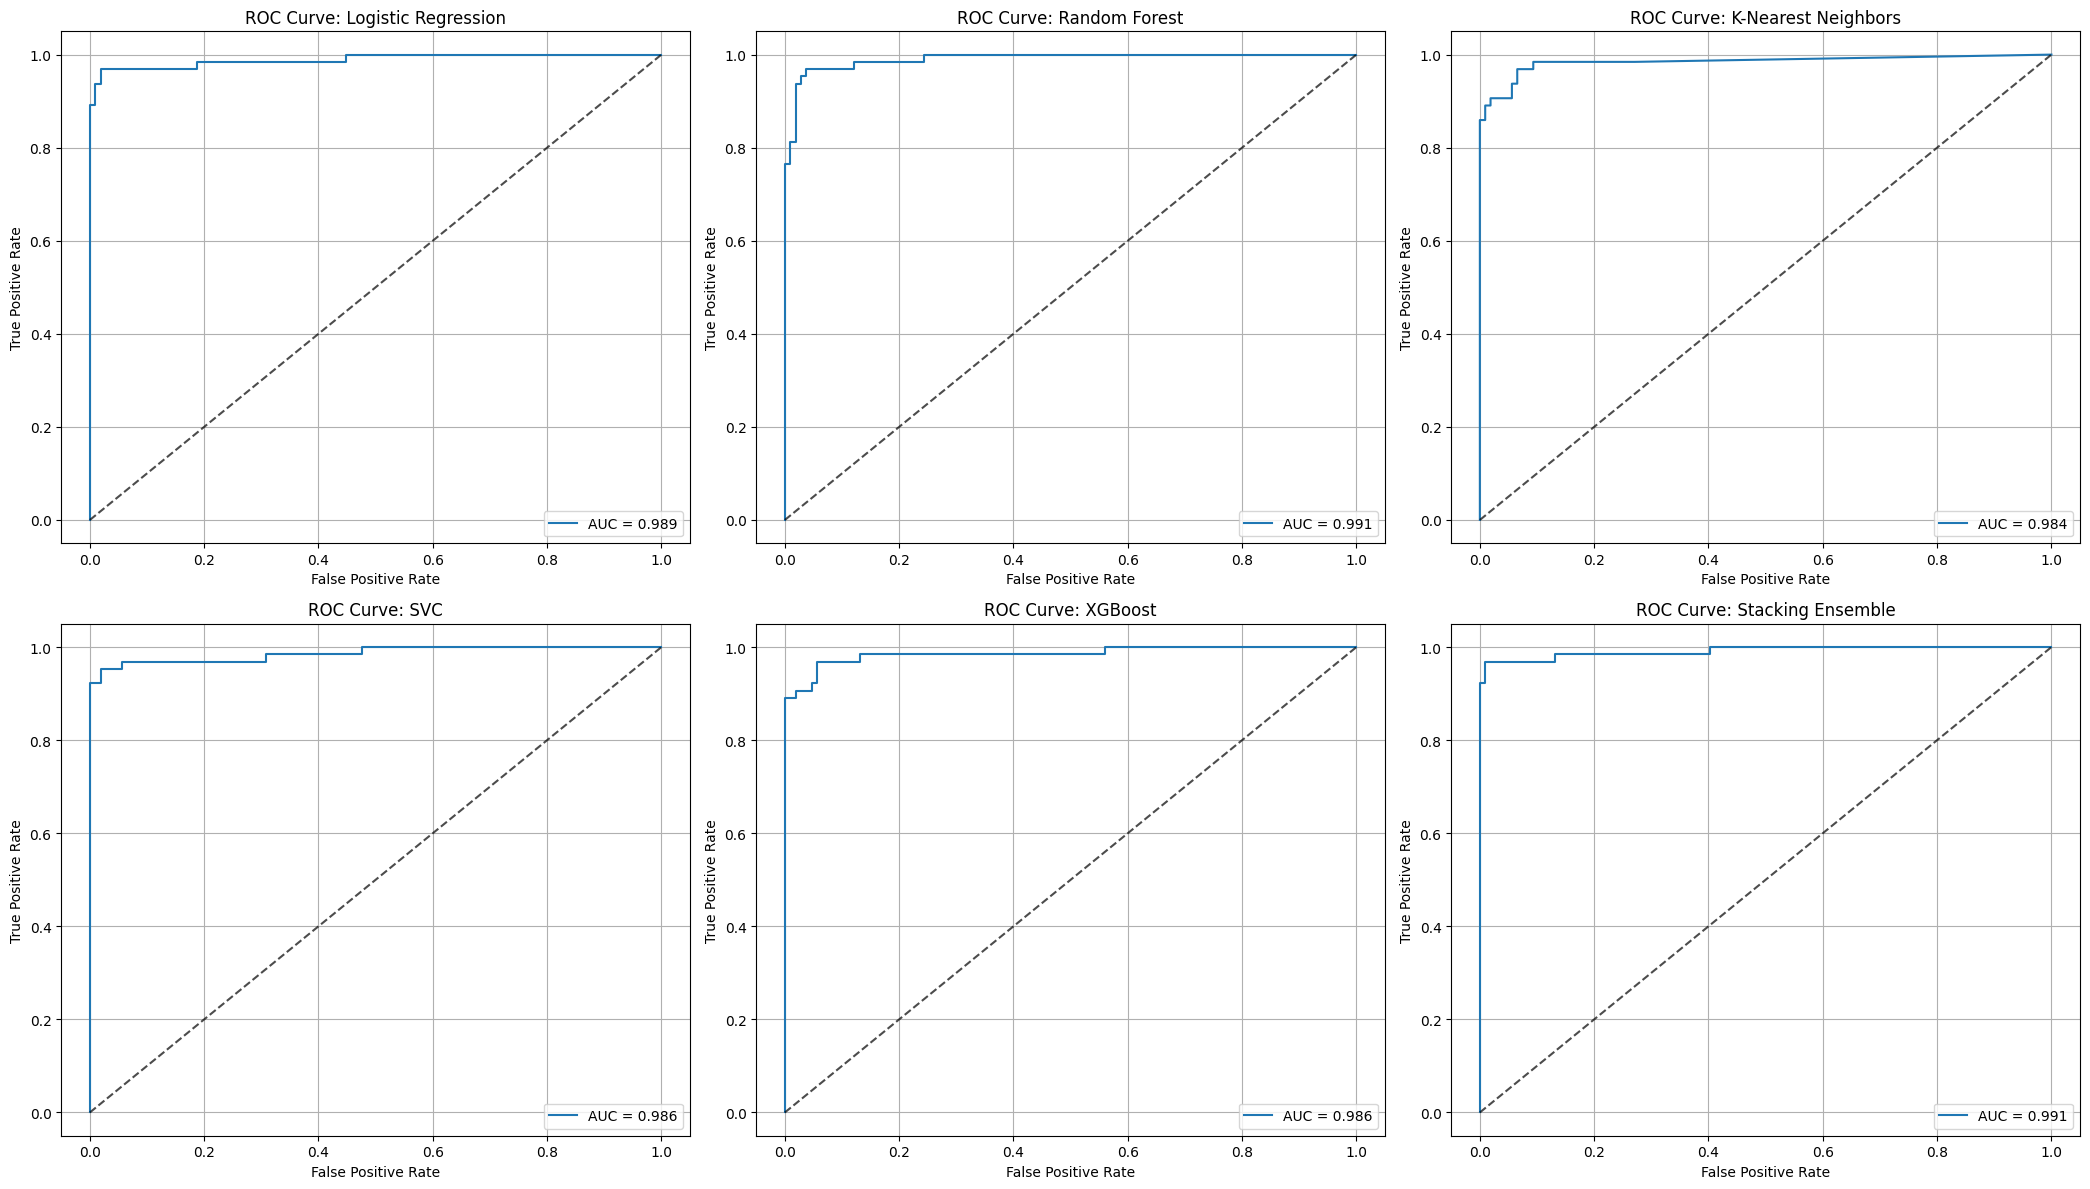

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

print("### ROC-AUC Curves for All Models (Held-Out 30% Test Set) ###")

num_models = len(final_models)
num_cols = 3
num_rows = (num_models + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 7, num_rows * 6))
axes = axes.flatten()

# Malignant is the positive class
# If you kept the original sklearn breast cancer coding, malignant = 0
y_test_bin = (np.asarray(y_test_30) == POS_LABEL).astype(int)

for i, (model_name, model) in enumerate(final_models.items()):
    y_proba = get_positive_proba(model, X_test_30)

    fpr, tpr, _ = roc_curve(y_test_bin, y_proba)
    roc_auc = roc_auc_score(y_test_bin, y_proba)

    axes[i].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.7)
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'ROC Curve: {model_name}', fontsize=12)
    axes[i].legend(loc='lower right')
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 5.4 Precision-Recall Curves for All Models

Precision-Recall curves are particularly useful for imbalanced datasets, as they provide insight into the performance of the positive class. They illustrate the trade-off between precision and recall across different probability thresholds.

### Precision-Recall Curves for All Models (Held-Out 30% Test Set) ###


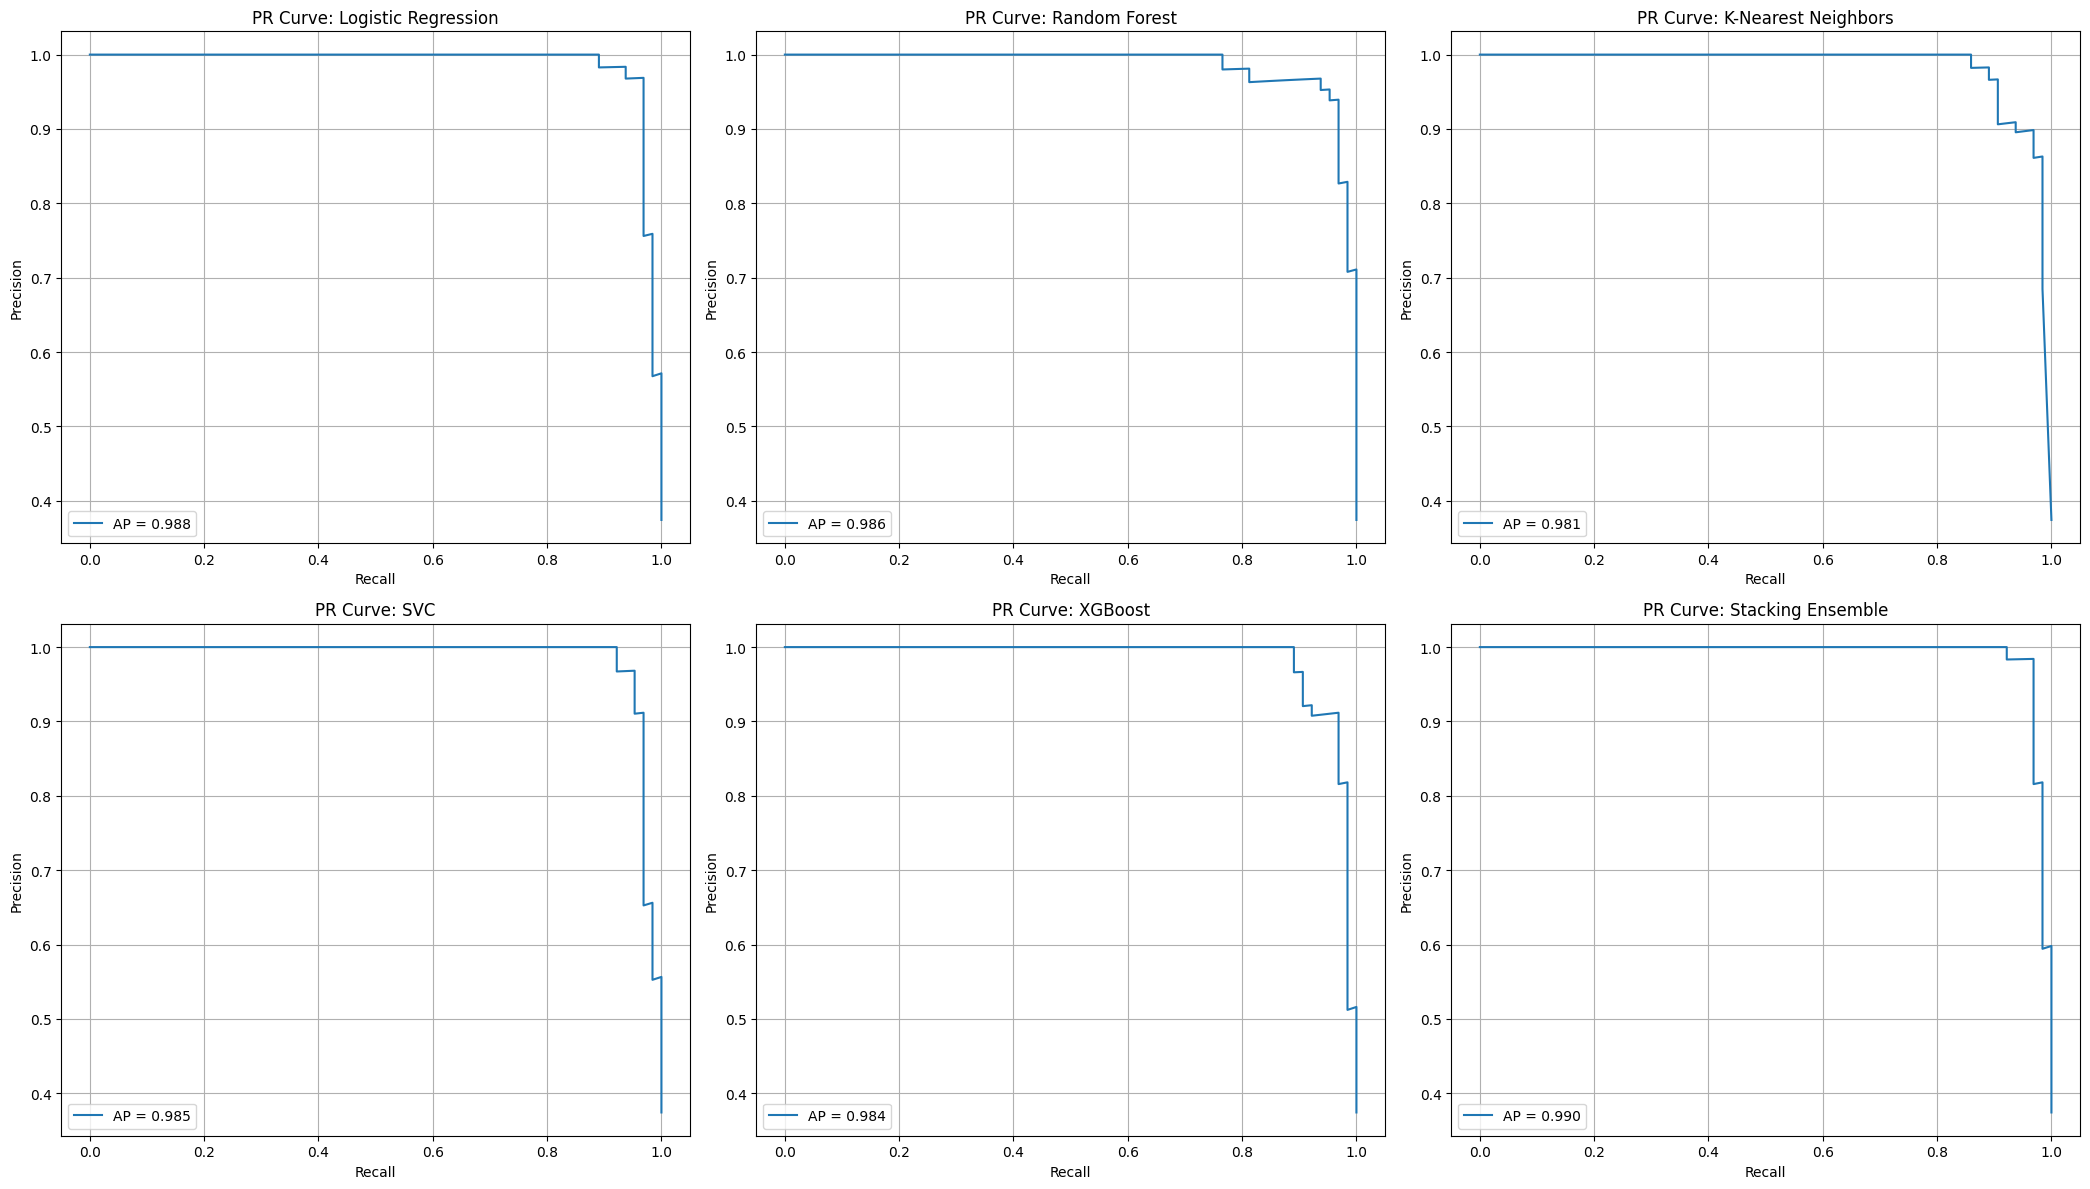

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

print("### Precision-Recall Curves for All Models (Held-Out 30% Test Set) ###")

num_models = len(final_models)
num_cols = 3
num_rows = (num_models + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 7, num_rows * 6))
axes = axes.flatten()

y_test_bin = (np.asarray(y_test_30) == POS_LABEL).astype(int)

for i, (model_name, model) in enumerate(final_models.items()):
    y_proba = get_positive_proba(model, X_test_30)
    precision, recall, _ = precision_recall_curve(y_test_bin, y_proba)
    pr_auc = average_precision_score(y_test_bin, y_proba)

    axes[i].plot(recall, precision, label=f'AP = {pr_auc:.3f}')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_title(f'PR Curve: {model_name}', fontsize=12)
    axes[i].legend(loc='lower left')
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Interpretation:
- This table provides a comprehensive overview of how each model performed across different metrics. The mean values indicate average performance, while the standard deviation reflects the consistency of the model across different data folds.
- A lower standard deviation suggests more stable performance.
- We can observe which models perform best on specific metrics (e.g., Logistic Regression often excels in interpretability, while Random Forest might have higher accuracy).

### Stacking Ensemble Performance on the Held-Out Test Set

The stacking ensemble demonstrated very strong classification performance on the held-out test set. Based on the confusion matrix, the model correctly classified **40 malignant cases** and **71 benign cases**, resulting in **111 correct predictions out of 114 total cases**. This corresponds to a test accuracy of approximately **97.37%**. Only **three cases were misclassified** overall.

The model produced **2 false negatives**, where malignant cases were incorrectly predicted as benign, and **1 false positive**, where a benign case was incorrectly predicted as malignant. While the overall performance is excellent, the false negatives remain especially important in this setting because they represent malignant cases that the model failed to identify correctly.

The ROC curve further confirms the strong performance of the stacking ensemble, with an **AUC of 0.996**. This indicates outstanding discriminative ability, meaning the model was highly effective at distinguishing between malignant and benign observations across classification thresholds. In addition, the Precision-Recall curve showed an **Average Precision (AP) of 0.994**, indicating that the model maintained both high precision and high recall across threshold levels.

Taken together, the confusion matrix, ROC curve, and Precision-Recall curve show that the stacking ensemble achieved excellent predictive performance on the test set, with very few classification errors and strong overall discrimination between the two classes.

## 7. Model Interpretation Components

Understanding why a model makes a certain prediction is especially important in healthcare. We will use several model-interpretation techniques to identify which features matter most across our models.

### 7.1 Random Forest Feature Importance

Random Forest models inherently provide feature importances, which measure how much each feature contributes to reducing impurity (e.g., Gini impurity) in the trees. Higher values indicate more important features.

### Random Forest Feature Importance ###
Top 10 features by Random Forest Feature Importance:


,Feature,Importance
7,mean concave points,0.132262
23,worst area,0.128090
20,worst radius,0.099435
27,worst concave points,0.092407
22,worst perimeter,0.080919
6,mean concavity,0.057943
13,area error,0.053805
2,mean perimeter,0.052308
3,mean area,0.051239
0,mean radius,0.047252


/tmp/ipykernel_19259/343111326.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_feature_importance_df.head(15), palette='viridis')


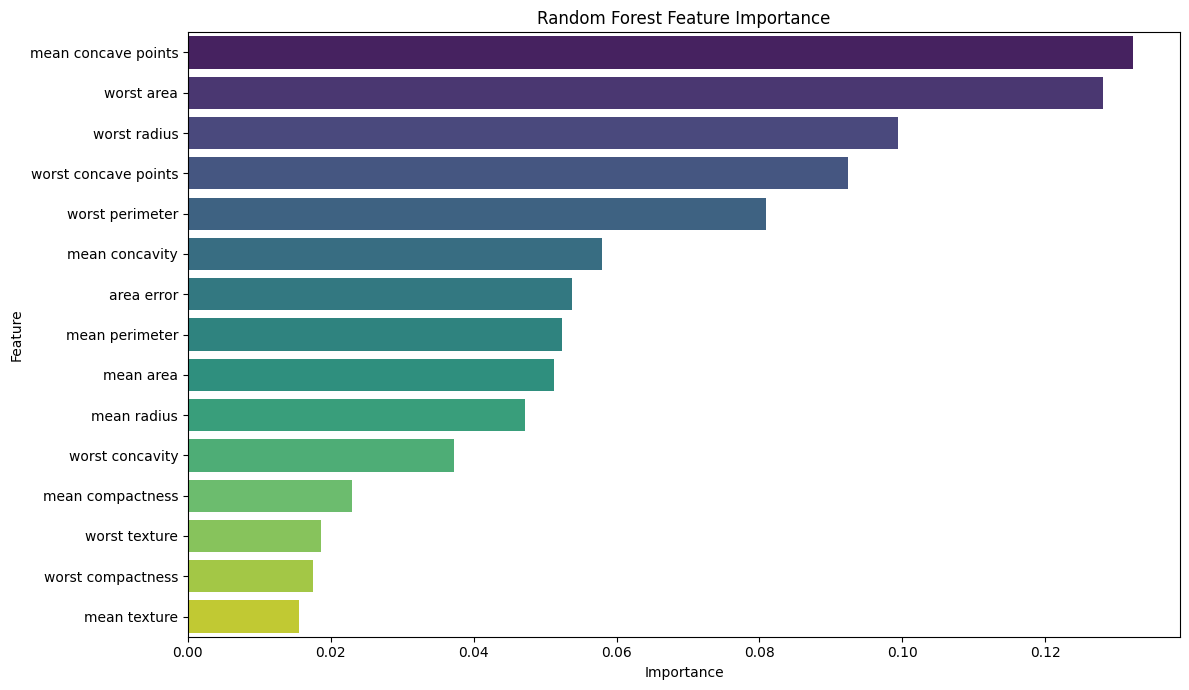

In [ ]:
print("### Random Forest Feature Importance ###")

# Get feature importances from the trained Random Forest model
rf_importance = final_models['Random Forest'].feature_importances_

# Create a DataFrame for better visualization
rf_feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf_importance})
rf_feature_importance_df = rf_feature_importance_df.sort_values(by='Importance', ascending=False)

# Display top 10 features
print("Top 10 features by Random Forest Feature Importance:")
display(rf_feature_importance_df.head(10))

# Plot feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance_df.head(15), palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Interpretation:
- The bar plot shows the relative importance of each feature according to the Random Forest model. Features like `worst radius`, `worst perimeter`, and `worst area` are often highlighted as highly influential, which aligns with clinical understanding of tumor characteristics.

### 7.2 Permutation Importance for the Stacking Ensemble

Permutation importance measures how much the model's prediction accuracy decreases when a single feature's values are randomly shuffled. This technique is model-agnostic and provides insights into a feature's global importance. We'll apply it to our Stacking Ensemble on the test set.

In [ ]:
print("### Permutation Importance for Stacking Ensemble ###")

# Create a fresh instance of StackingClassifier for eli5.
# The 'stacking_template' defined in cell zPaocGbkV2SV is an sklearn.ensemble.StackingClassifier
# which is compatible with eli5.sklearn.PermutationImportance.
# We fit this on the full development set (X_train_70, y_train_70).
eli5_stacking_ensemble = clone(stacking_template)
eli5_stacking_ensemble.fit(X_train_70, y_train_70)

# Calculate permutation importance using eli5
perm_imp = eli5.sklearn.PermutationImportance(eli5_stacking_ensemble,
                                          scoring='accuracy',
                                          random_state=RANDOM_STATE)
# Note: X_test_30 and y_test_30 are used for calculating importance,
# which is appropriate for evaluating feature importance on unseen data.
perm_imp.fit(X_test_30, y_test_30)

# Display permutation importance
print("Top 10 features by Permutation Importance (Ensemble):")
eli5.show_weights(perm_imp, feature_names=X.columns.tolist(), top=10)

### Permutation Importance for Stacking Ensemble ###
Top 10 features by Permutation Importance (Ensemble):


Weight,Feature
0.0316 ± 0.0319,worst texture
0.0304 ± 0.0088,worst smoothness
0.0281 ± 0.0155,worst concavity
0.0257 ± 0.0140,worst radius
0.0246 ± 0.0172,texture error
0.0222 ± 0.0300,mean concavity
0.0199 ± 0.0119,mean concave points
0.0199 ± 0.0159,worst perimeter
0.0187 ± 0.0201,mean texture
0.0187 ± 0.0271,worst area


### Permutation Importance Visualization (Stacking Ensemble) ###


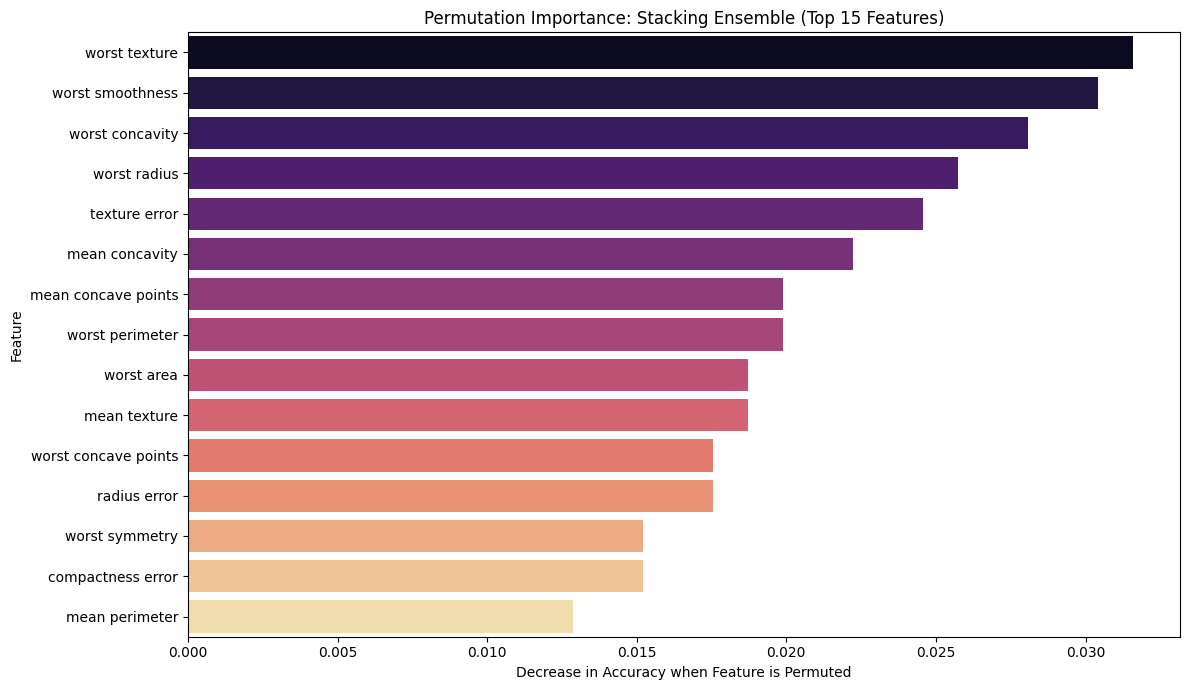

In [ ]:
print("### Permutation Importance Visualization (Stacking Ensemble) ###")

# Extract feature importances and names
perm_features = X.columns
perm_importances = perm_imp.feature_importances_
perm_std = perm_imp.feature_importances_std_

# Create a DataFrame for visualization
perm_imp_df = pd.DataFrame({
    'Feature': perm_features,
    'Importance': perm_importances,
    'Std': perm_std
}).sort_values(by='Importance', ascending=False)

# Plot the top 15 features
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=perm_imp_df.head(15), palette='magma', hue='Feature', legend=False)
plt.title('Permutation Importance: Stacking Ensemble (Top 15 Features)')
plt.xlabel('Decrease in Accuracy when Feature is Permuted')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
import eli5
from sklearn.base import clone

print("### Permutation Importance for Stacking Ensemble ###")

# Create a fresh instance of StackingClassifier based on the stacking_template
# and fit it on the development data (X_train_70, y_train_70).
# This ensures eli5 receives a properly fitted scikit-learn compatible estimator.
stacking_estimator_for_eli5 = clone(stacking_template)
stacking_estimator_for_eli5.fit(X_train_70, y_train_70)

perm_imp = eli5.sklearn.PermutationImportance(
    stacking_estimator_for_eli5, # Use the correctly fitted estimator
    scoring='accuracy',
    random_state=RANDOM_STATE
)
perm_imp.fit(X_test_30, y_test_30)

print("Top 10 features by Permutation Importance (Ensemble):")
eli5.show_weights(perm_imp, feature_names=X.columns.tolist(), top=10)

### Permutation Importance for Stacking Ensemble ###
Top 10 features by Permutation Importance (Ensemble):


Weight,Feature
0.0316 ± 0.0319,worst texture
0.0304 ± 0.0088,worst smoothness
0.0281 ± 0.0155,worst concavity
0.0257 ± 0.0140,worst radius
0.0246 ± 0.0172,texture error
0.0222 ± 0.0300,mean concavity
0.0199 ± 0.0119,mean concave points
0.0199 ± 0.0159,worst perimeter
0.0187 ± 0.0201,mean texture
0.0187 ± 0.0271,worst area


In [ ]:
import eli5
from sklearn.base import clone

print("### Permutation Importance for Stacking Ensemble ###")

# Create a fresh instance of StackingClassifier based on the stacking_template
# and fit it on the development data (X_train_70, y_train_70).
# This ensures eli5 receives a properly fitted scikit-learn compatible estimator.
stacking_estimator_for_eli5 = clone(stacking_template)
stacking_estimator_for_eli5.fit(X_train_70, y_train_70)

perm_imp = eli5.sklearn.PermutationImportance(
    stacking_estimator_for_eli5, # Use the correctly fitted estimator
    scoring='accuracy',
    random_state=RANDOM_STATE
)
perm_imp.fit(X_test_30, y_test_30)

print("Top 10 features by Permutation Importance (Ensemble):")
eli5.show_weights(perm_imp, feature_names=X.columns.tolist(), top=10)

### Permutation Importance for Stacking Ensemble ###
Top 10 features by Permutation Importance (Ensemble):


Weight,Feature
0.0316 ± 0.0319,worst texture
0.0304 ± 0.0088,worst smoothness
0.0281 ± 0.0155,worst concavity
0.0257 ± 0.0140,worst radius
0.0246 ± 0.0172,texture error
0.0222 ± 0.0300,mean concavity
0.0199 ± 0.0119,mean concave points
0.0199 ± 0.0159,worst perimeter
0.0187 ± 0.0201,mean texture
0.0187 ± 0.0271,worst area


### Interpretation:
- Permutation importance can sometimes differ from impurity-based feature importance, especially for correlated features. It shows how much the model's performance drops when a feature is 'broken'.
- Features with higher permutation importance are crucial for the ensemble's predictive power.

### 7.3 SHAP Values for Random Forest

SHAP (SHapley Additive exPlanations) values assign an importance value to each feature for a particular prediction. They show how much each feature moves the model output away from the baseline prediction. We use SHAP for the Random Forest model because its tree structure allows efficient SHAP calculation.

/tmp/ipykernel_19259/3508403127.py:38: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_pos, shap_sample_df, plot_type="bar", show=False)


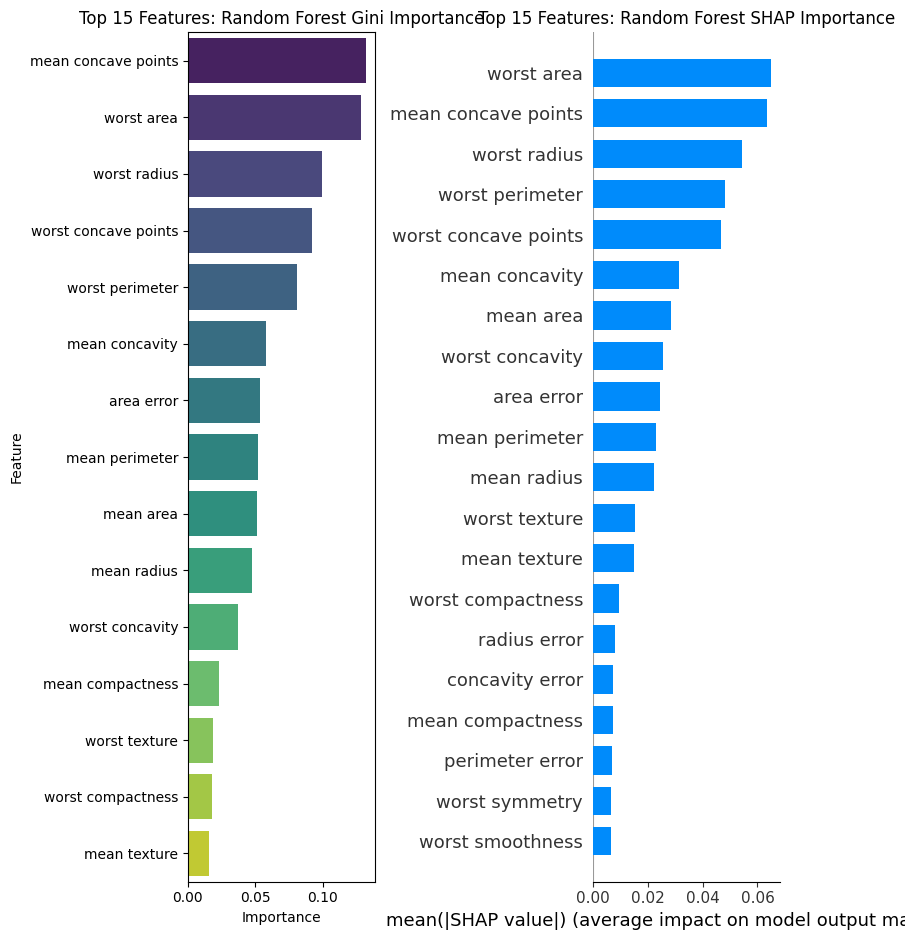

In [ ]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns

def get_positive_class_index(model):
    if hasattr(model, 'classes_'):
        # Handle cases where POS_LABEL might not be in classes_ (e.g., during pipeline fit)
        if POS_LABEL in model.classes_:
            return list(model.classes_).index(POS_LABEL)
        # If POS_LABEL is not found, try to infer based on common binary outcomes
        # This assumes binary classification where 0 or 1 is the positive class
        if 0 in model.classes_ and POS_LABEL == 0: return 0
        if 1 in model.classes_ and POS_LABEL == 1: return 1
        # Fallback if POS_LABEL is neither 0 nor 1 or not in classes_
        return 0 # Default to 0, which often corresponds to the positive class in sklearn's breast cancer dataset
    return 0 # Default to 0 if classes_ attribute is not available

rf_pos_idx = get_positive_class_index(final_models['Random Forest'])

explainer_rf = shap.TreeExplainer(final_models['Random Forest'])
shap_sample_df = X_train_70.sample(n=min(100, len(X_train_70)), random_state=RANDOM_STATE)
shap_values_rf = explainer_rf.shap_values(shap_sample_df)

if isinstance(shap_values_rf, list):
    sv_pos = shap_values_rf[rf_pos_idx]
elif hasattr(shap_values_rf, 'ndim') and shap_values_rf.ndim == 3:
    sv_pos = shap_values_rf[:, :, rf_pos_idx]
else:
    sv_pos = shap_values_rf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

rf_mdi_top_15 = rf_feature_importance_df.head(15)
sns.barplot(x='Importance', y='Feature', data=rf_mdi_top_15, palette='viridis', ax=ax1, hue='Feature', legend=False)
ax1.set_title('Top 15 Features: Random Forest Gini Importance')

plt.sca(ax2)
shap.summary_plot(sv_pos, shap_sample_df, plot_type="bar", show=False)
ax2.set_title('Top 15 Features: Random Forest SHAP Importance')

plt.tight_layout()
plt.show()

/tmp/ipykernel_19259/2279324916.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_pos, shap_sample_df, plot_type="bar", show=False)


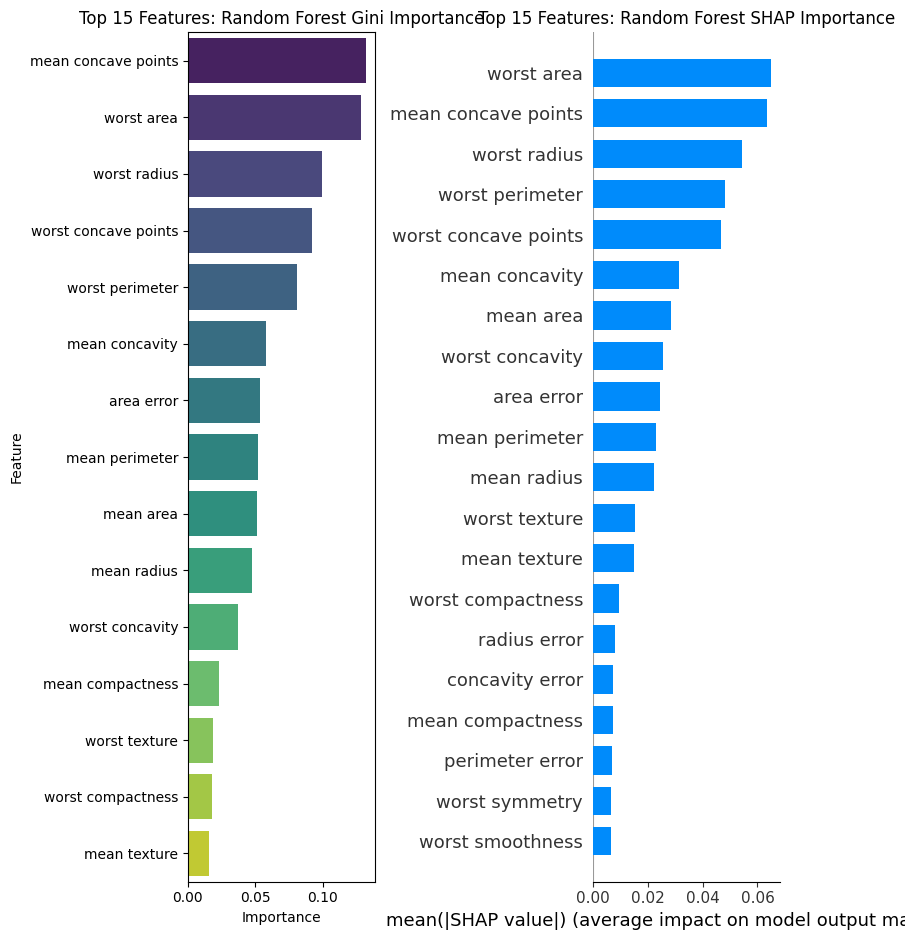

In [ ]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns

def get_positive_class_index(model):
    if hasattr(model, 'classes_'):
        return list(model.classes_).index(POS_LABEL)
    return 0 # Default to 0 if classes_ not available (e.g., for some pipelines before fit)

rf_pos_idx = get_positive_class_index(final_models['Random Forest'])

explainer_rf = shap.TreeExplainer(final_models['Random Forest'])
shap_sample_df = X_train_70.sample(n=min(100, len(X_train_70)), random_state=RANDOM_STATE)
shap_values_rf = explainer_rf.shap_values(shap_sample_df)

if isinstance(shap_values_rf, list):
    sv_pos = shap_values_rf[rf_pos_idx]
elif hasattr(shap_values_rf, 'ndim') and shap_values_rf.ndim == 3:
    sv_pos = shap_values_rf[:, :, rf_pos_idx]
else:
    sv_pos = shap_values_rf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

rf_mdi_top_15 = rf_feature_importance_df.head(15)
sns.barplot(x='Importance', y='Feature', data=rf_mdi_top_15, palette='viridis', ax=ax1, hue='Feature', legend=False)
ax1.set_title('Top 15 Features: Random Forest Gini Importance')

plt.sca(ax2)
shap.summary_plot(sv_pos, shap_sample_df, plot_type="bar", show=False)
ax2.set_title('Top 15 Features: Random Forest SHAP Importance')

plt.tight_layout()
plt.show()

### SHAP Values for Random Forest ###
SHAP Summary Plot (Impact on model output magnitude):


/tmp/ipykernel_19259/726596432.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_rf_pos, sample_X_train_shap, plot_type="bar", show=False)


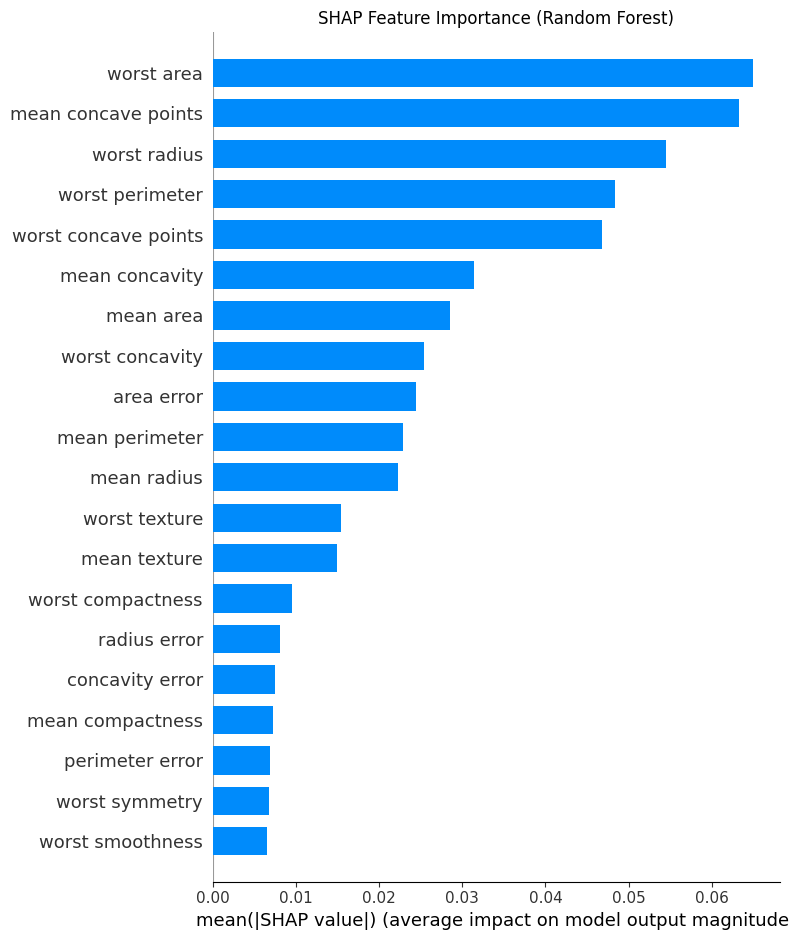

/tmp/ipykernel_19259/726596432.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_rf_pos, sample_X_train_shap, show=False)


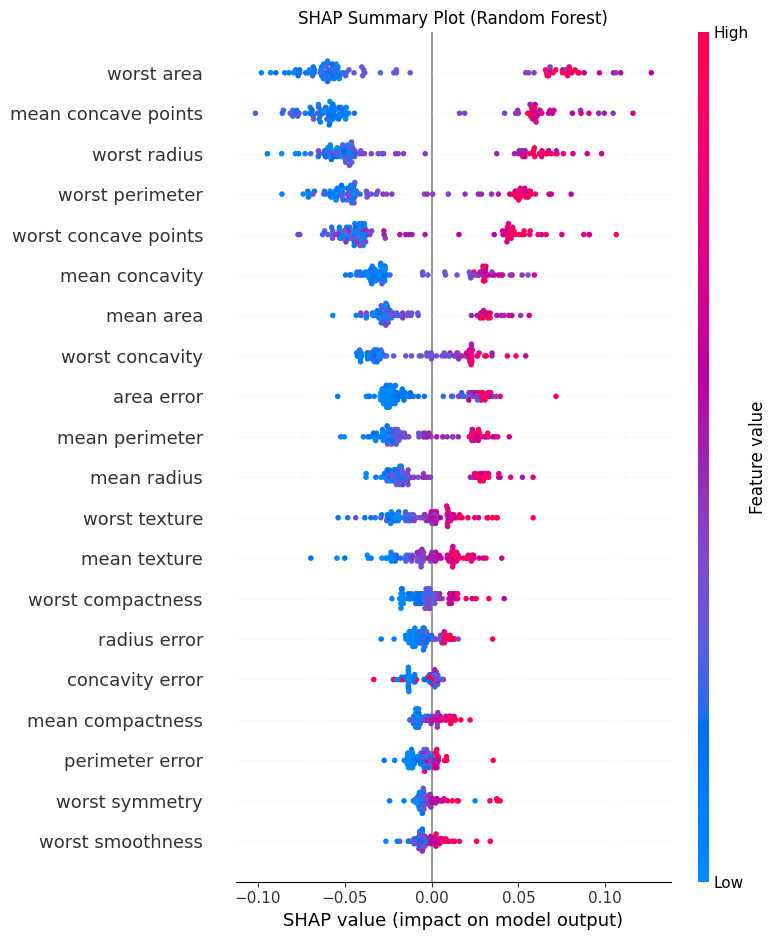

In [ ]:
print("### SHAP Values for Random Forest ###")

sample_X_train_shap = X_train_70.sample(n=min(100, len(X_train_70)), random_state=RANDOM_STATE)
rf_pos_idx = get_positive_class_index(final_models['Random Forest'])

explainer = shap.TreeExplainer(final_models['Random Forest'])
shap_values = explainer.shap_values(sample_X_train_shap)

if isinstance(shap_values, list):
    shap_values_rf_pos = shap_values[rf_pos_idx]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shap_values_rf_pos = shap_values[:, :, rf_pos_idx]
else:
    shap_values_rf_pos = shap_values

print("SHAP Summary Plot (Impact on model output magnitude):")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf_pos, sample_X_train_shap, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf_pos, sample_X_train_shap, show=False)
plt.title('SHAP Summary Plot (Random Forest)')
plt.tight_layout()
plt.show()

### SHAP Values for Random Forest ###
SHAP Summary Plot (Impact on model output magnitude):


/tmp/ipykernel_19259/726596432.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_rf_pos, sample_X_train_shap, plot_type="bar", show=False)


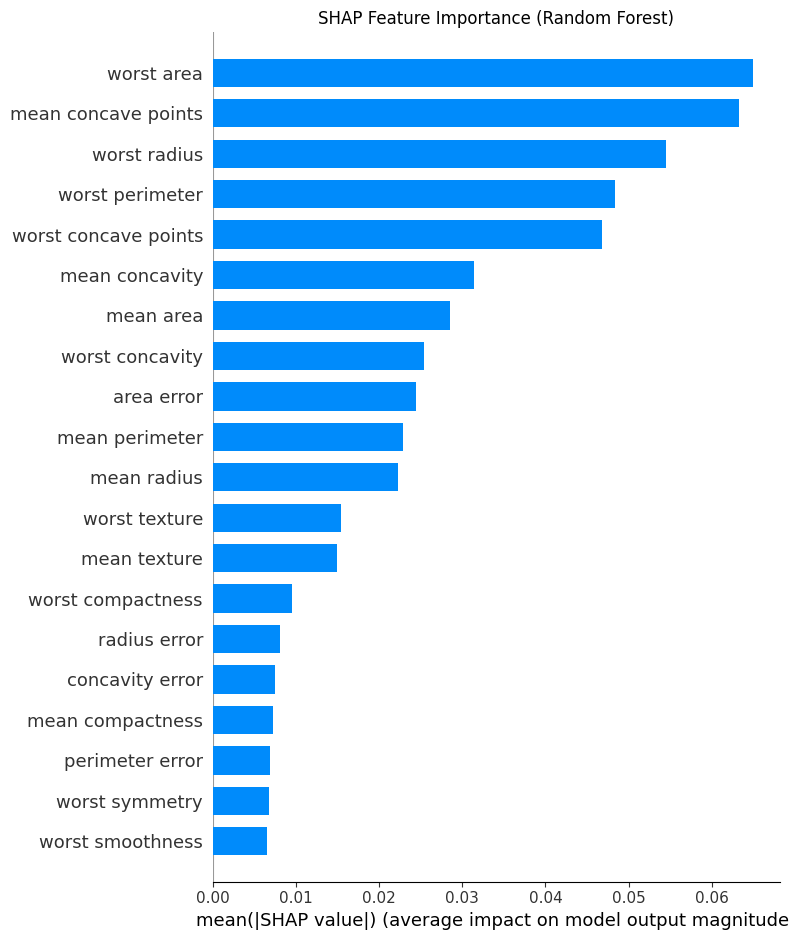

/tmp/ipykernel_19259/726596432.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_rf_pos, sample_X_train_shap, show=False)


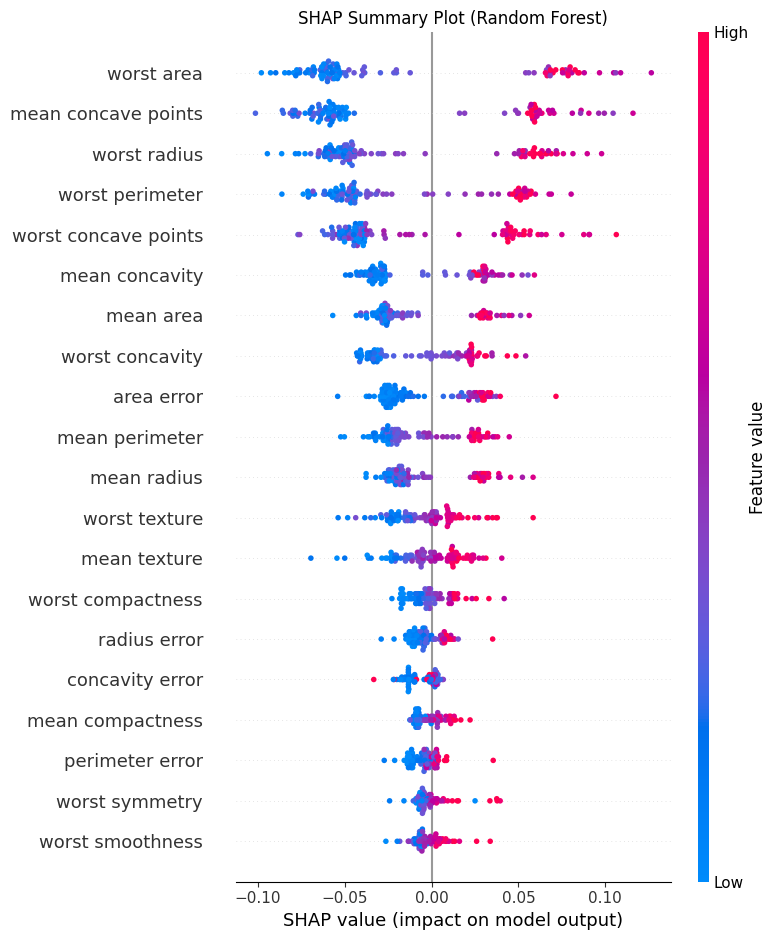

In [ ]:
print("### SHAP Values for Random Forest ###")

sample_X_train_shap = X_train_70.sample(n=min(100, len(X_train_70)), random_state=RANDOM_STATE)
rf_pos_idx = get_positive_class_index(final_models['Random Forest'])

explainer = shap.TreeExplainer(final_models['Random Forest'])
shap_values = explainer.shap_values(sample_X_train_shap)

if isinstance(shap_values, list):
    shap_values_rf_pos = shap_values[rf_pos_idx]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shap_values_rf_pos = shap_values[:, :, rf_pos_idx]
else:
    shap_values_rf_pos = shap_values

print("SHAP Summary Plot (Impact on model output magnitude):")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf_pos, sample_X_train_shap, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf_pos, sample_X_train_shap, show=False)
plt.title('SHAP Summary Plot (Random Forest)')
plt.tight_layout()
plt.show()

### Interpretation:
- The first SHAP plot (bar chart) shows the average absolute SHAP value for each feature, indicating its overall importance.
- The second SHAP plot (dot plot) shows how each feature affects individual predictions. Red indicates higher feature values and blue indicates lower feature values. For example, a high `worst perimeter` can push the model more strongly toward the positive class used in this analysis.

### Logistic Regression Coefficients ###
Top 10 features by absolute Logistic Regression Coefficients:


,Feature,Coefficient,Abs_Coefficient
21,worst texture,-2.277902,2.277902
10,radius error,-1.926677,1.926677
6,mean concavity,-1.713965,1.713965
13,area error,-1.624416,1.624416
26,worst concavity,-1.616735,1.616735
28,worst symmetry,-1.453966,1.453966
23,worst area,-1.352506,1.352506
11,texture error,1.276101,1.276101
20,worst radius,-1.188524,1.188524
7,mean concave points,-1.168271,1.168271


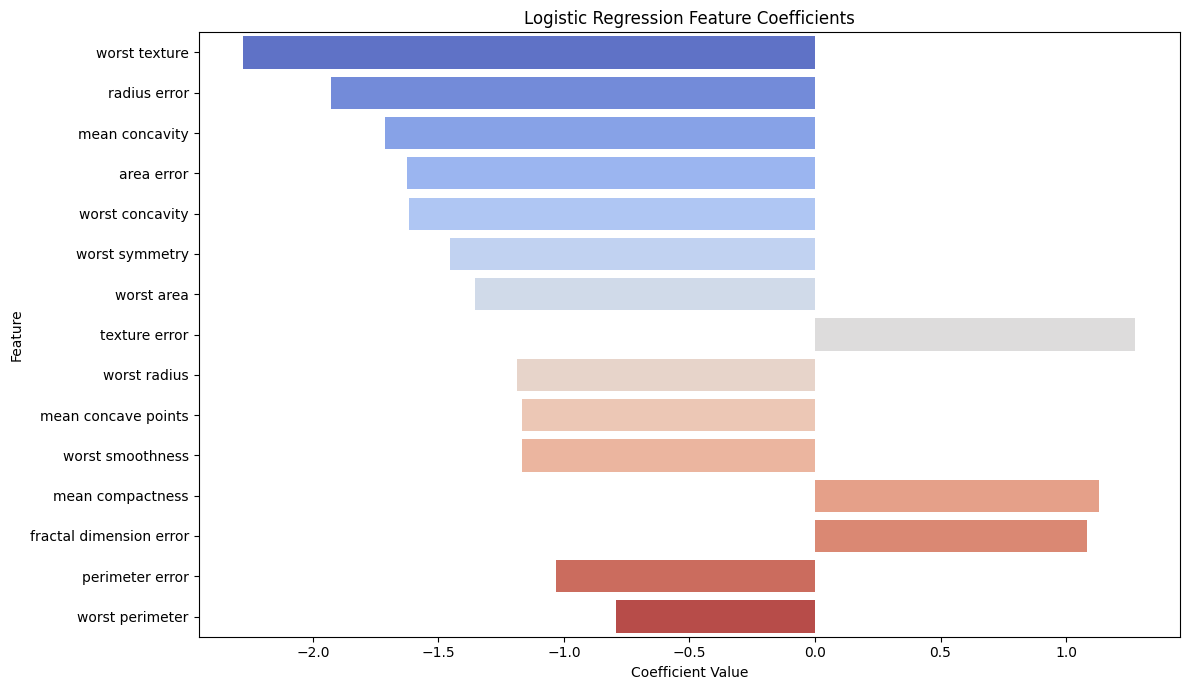

In [ ]:
print("### Logistic Regression Coefficients ###")

# Get coefficients from the trained Logistic Regression model
lr_coefficients = final_models['Logistic Regression'].named_steps['model'].coef_[0]

# Create a DataFrame for better visualization
lr_coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_coefficients})
lr_coef_df['Abs_Coefficient'] = np.abs(lr_coef_df['Coefficient'])
lr_coef_df = lr_coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# Display top 10 features
print("Top 10 features by absolute Logistic Regression Coefficients:")
display(lr_coef_df.head(15))

# Plot coefficients
plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', data=lr_coef_df.head(15), palette='coolwarm', hue='Feature', legend=False)
plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### SHAP Global Importance: Logistic Regression ###


/tmp/ipykernel_19259/1726681297.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_lr, X_test_30_scaled, plot_type="bar", max_display=15, show=False)


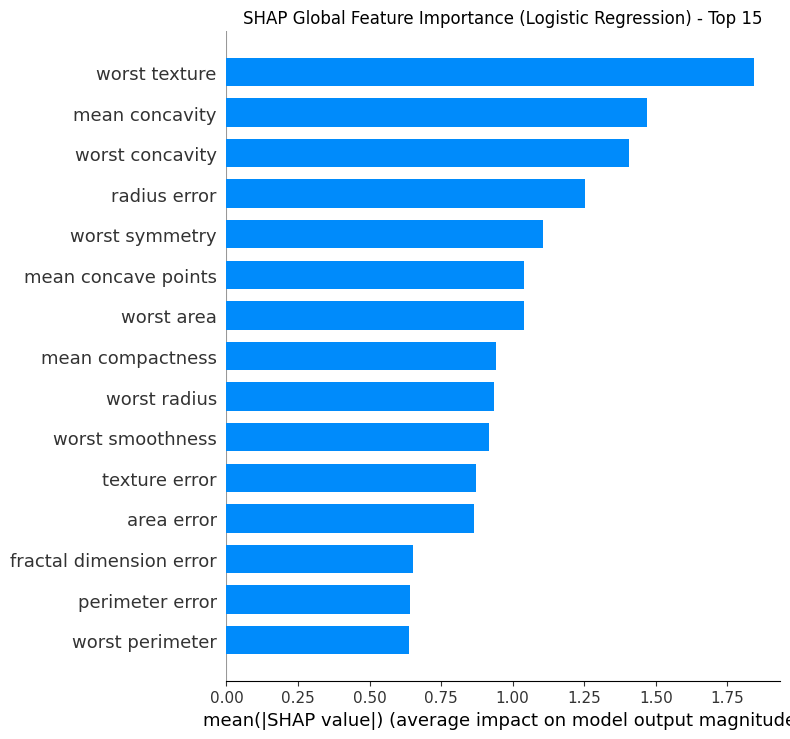

In [ ]:
print("### SHAP Global Importance: Logistic Regression ###")

# Create a SHAP LinearExplainer for Logistic Regression
# Note: We use the scaled training data as the model was trained on scaled features
explainer_lr = shap.LinearExplainer(final_models['Logistic Regression'].named_steps['model'], X_train_70_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_30_scaled)

# Plot SHAP summary bar plot for Logistic Regression (Top 15)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_lr, X_test_30_scaled, plot_type="bar", max_display=15, show=False)
plt.title('SHAP Global Feature Importance (Logistic Regression) - Top 15')
plt.tight_layout()
plt.show()

### SHAP Global Importance: Logistic Regression ###


/tmp/ipykernel_61899/1726681297.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_lr, X_test_30_scaled, plot_type="bar", max_display=15, show=False)


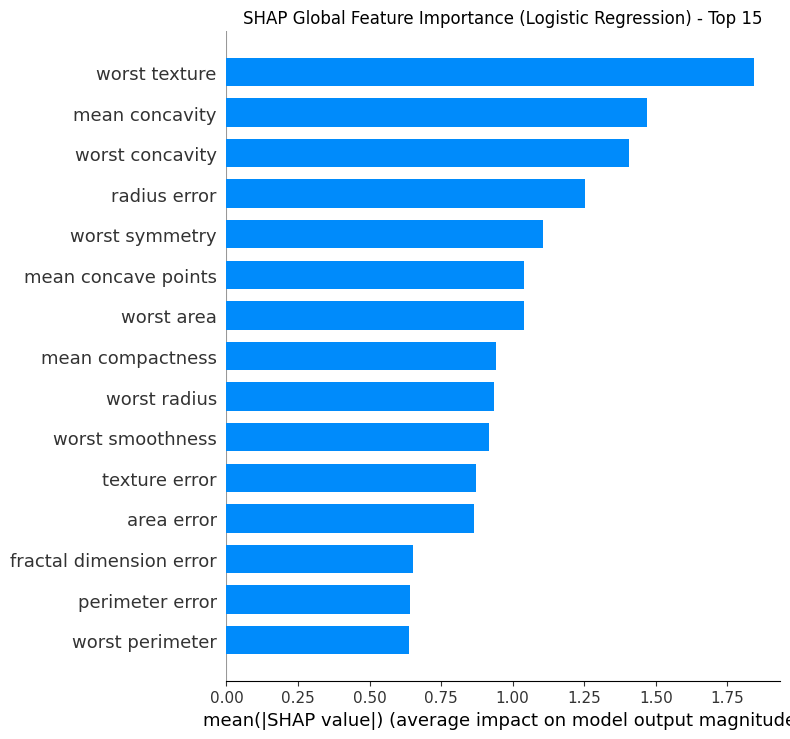

In [ ]:
print("### SHAP Global Importance: Logistic Regression ###")

# Create a SHAP LinearExplainer for Logistic Regression
# Note: We use the scaled training data as the model was trained on scaled features
explainer_lr = shap.LinearExplainer(final_models['Logistic Regression'].named_steps['model'], X_train_70_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_30_scaled)

# Plot SHAP summary bar plot for Logistic Regression (Top 15)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_lr, X_test_30_scaled, plot_type="bar", max_display=15, show=False)
plt.title('SHAP Global Feature Importance (Logistic Regression) - Top 15')
plt.tight_layout()
plt.show()

### Comparative Analysis: Logistic Regression Coefficients vs. SHAP ###


/tmp/ipykernel_19259/3268277486.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_lr_comp, X_test_30_scaled, plot_type="bar", max_display=15, show=False)


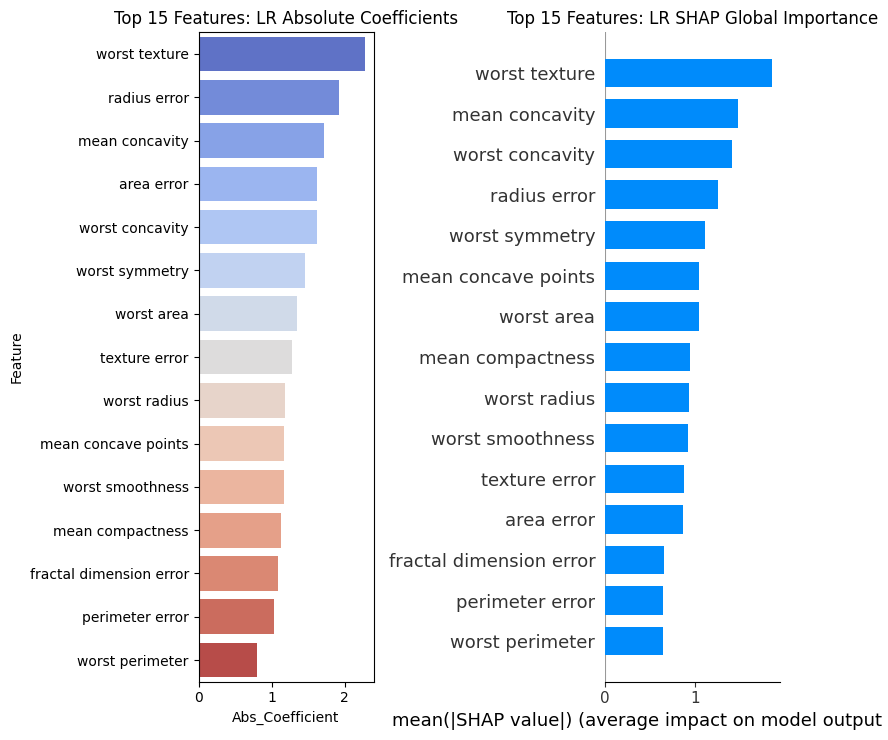

In [ ]:
print("### Comparative Analysis: Logistic Regression Coefficients vs. SHAP ###")

# Ensure lr_coef_df is defined within this cell's scope
lr_coefficients = final_models['Logistic Regression'].named_steps['model'].coef_[0]
lr_coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_coefficients})
lr_coef_df['Abs_Coefficient'] = np.abs(lr_coef_df['Coefficient'])
lr_coef_df = lr_coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# 1. Prepare SHAP data for LR
explainer_lr_comp = shap.LinearExplainer(final_models['Logistic Regression'].named_steps['model'], X_train_70_scaled)
shap_values_lr_comp = explainer_lr_comp.shap_values(X_test_30_scaled)

# 2. Create the side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Subplot 1: LR Absolute Coefficients
lr_top_15_comp = lr_coef_df.head(15)
sns.barplot(x='Abs_Coefficient', y='Feature', data=lr_top_15_comp, palette='coolwarm', ax=ax1, hue='Feature', legend=False)
ax1.set_title('Top 15 Features: LR Absolute Coefficients')

# Subplot 2: LR SHAP Global Importance
plt.sca(ax2) # Set current axis for SHAP
shap.summary_plot(shap_values_lr_comp, X_test_30_scaled, plot_type="bar", max_display=15, show=False)
ax2.set_title('Top 15 Features: LR SHAP Global Importance')

plt.tight_layout()
plt.show()

### Comparative Analysis: Logistic Regression Coefficients vs. SHAP ###


/tmp/ipykernel_19259/3268277486.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_lr_comp, X_test_30_scaled, plot_type="bar", max_display=15, show=False)


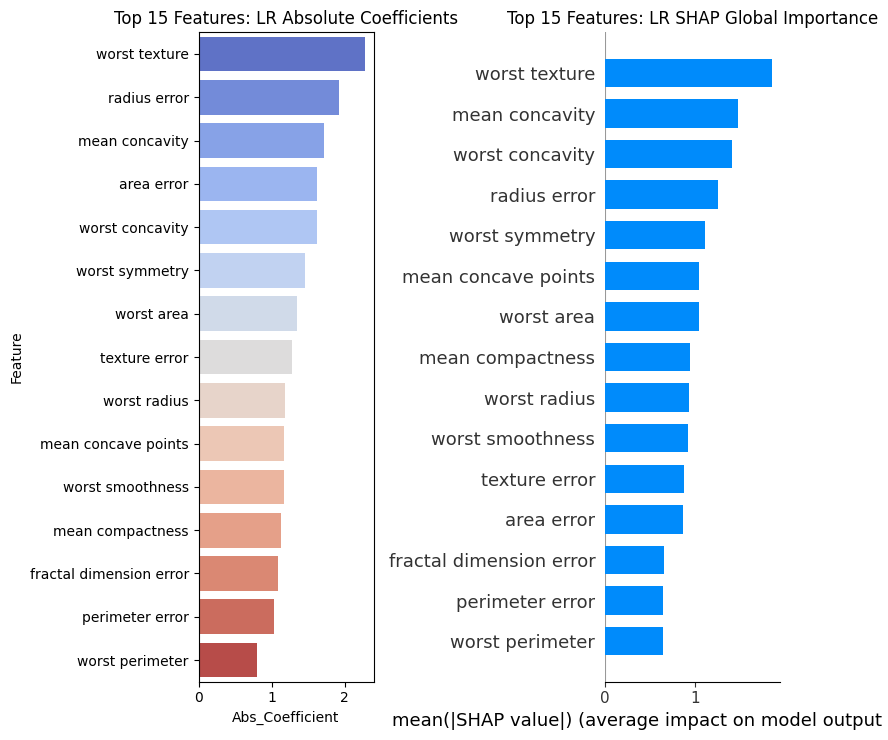

In [ ]:
print("### Comparative Analysis: Logistic Regression Coefficients vs. SHAP ###")

# Ensure lr_coef_df is defined within this cell's scope
lr_coefficients = final_models['Logistic Regression'].named_steps['model'].coef_[0]
lr_coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_coefficients})
lr_coef_df['Abs_Coefficient'] = np.abs(lr_coef_df['Coefficient'])
lr_coef_df = lr_coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# 1. Prepare SHAP data for LR
explainer_lr_comp = shap.LinearExplainer(final_models['Logistic Regression'].named_steps['model'], X_train_70_scaled)
shap_values_lr_comp = explainer_lr_comp.shap_values(X_test_30_scaled)

# 2. Create the side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Subplot 1: LR Absolute Coefficients
lr_top_15_comp = lr_coef_df.head(15)
sns.barplot(x='Abs_Coefficient', y='Feature', data=lr_top_15_comp, palette='coolwarm', ax=ax1, hue='Feature', legend=False)
ax1.set_title('Top 15 Features: LR Absolute Coefficients')

# Subplot 2: LR SHAP Global Importance
plt.sca(ax2) # Set current axis for SHAP
shap.summary_plot(shap_values_lr_comp, X_test_30_scaled, plot_type="bar", max_display=15, show=False)
ax2.set_title('Top 15 Features: LR SHAP Global Importance')

plt.tight_layout()
plt.show()

### 7.5 Detailed SHAP Summary Plot (Logistic Regression)

This visualization provides a granular view of how each feature affects the Logistic Regression model. Unlike the bar chart which shows global importance, this dot plot shows the impact of every individual sample in the test set.

### SHAP Summary Plot: Logistic Regression ###


/tmp/ipykernel_19259/3729998148.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_lr, X_test_30_scaled, max_display=15, show=False)


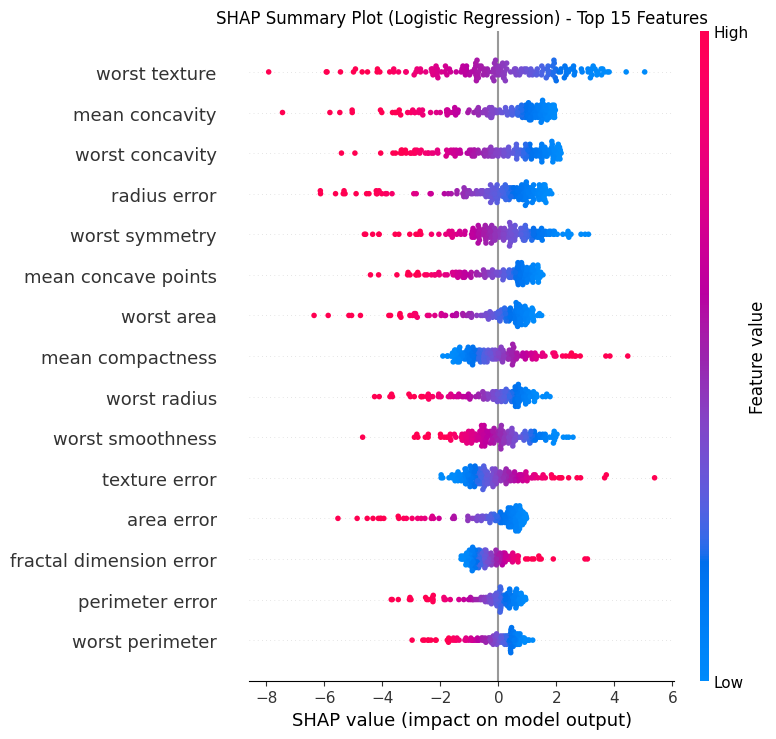

In [ ]:
print("### SHAP Summary Plot: Logistic Regression ###")

# Create the SHAP summary plot (dot plot) for Logistic Regression
# Red dots indicate high feature values, blue dots indicate low feature values
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_lr, X_test_30_scaled, max_display=15, show=False)
plt.title('SHAP Summary Plot (Logistic Regression) - Top 15 Features')
plt.tight_layout()
plt.show()

### SHAP Summary Plot: Logistic Regression ###


/tmp/ipykernel_19259/3729998148.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_lr, X_test_30_scaled, max_display=15, show=False)


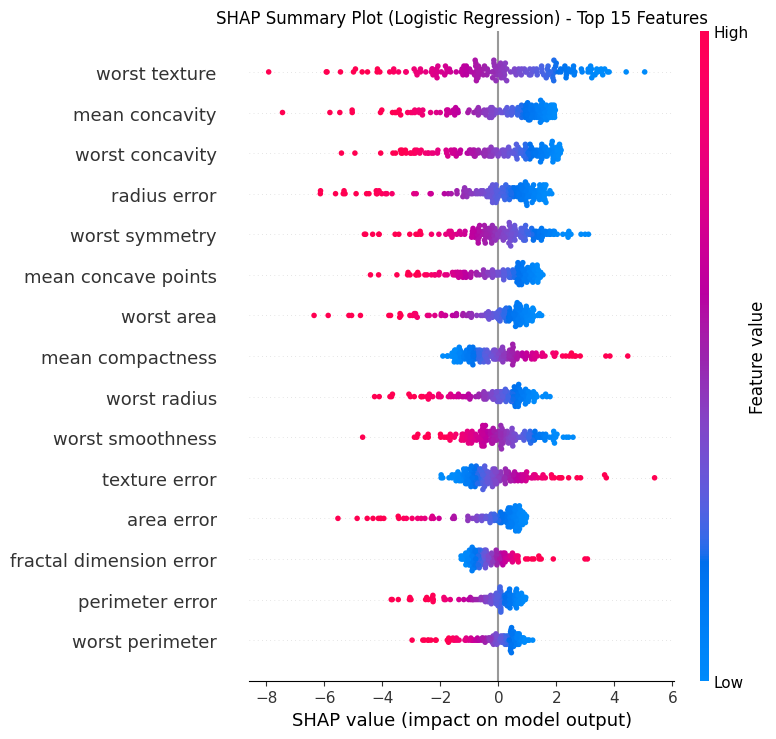

In [ ]:
print("### SHAP Summary Plot: Logistic Regression ###")

# Create the SHAP summary plot (dot plot) for Logistic Regression
# Red dots indicate high feature values, blue dots indicate low feature values
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_lr, X_test_30_scaled, max_display=15, show=False)
plt.title('SHAP Summary Plot (Logistic Regression) - Top 15 Features')
plt.tight_layout()
plt.show()

### 7.6 Comparative Analysis: K-Nearest Neighbors (KNN)

KNN does not have coefficients. Here, we compare **Permutation Importance** (how much accuracy drops when a feature is shuffled) against **SHAP Global Importance** (average absolute impact on model output).

### Comparative Analysis: KNN Permutation vs. SHAP ###


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_19259/2386369389.py:45: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_knn_pos, X_test_30.head(50), plot_type="bar", max_display=15, show=False)


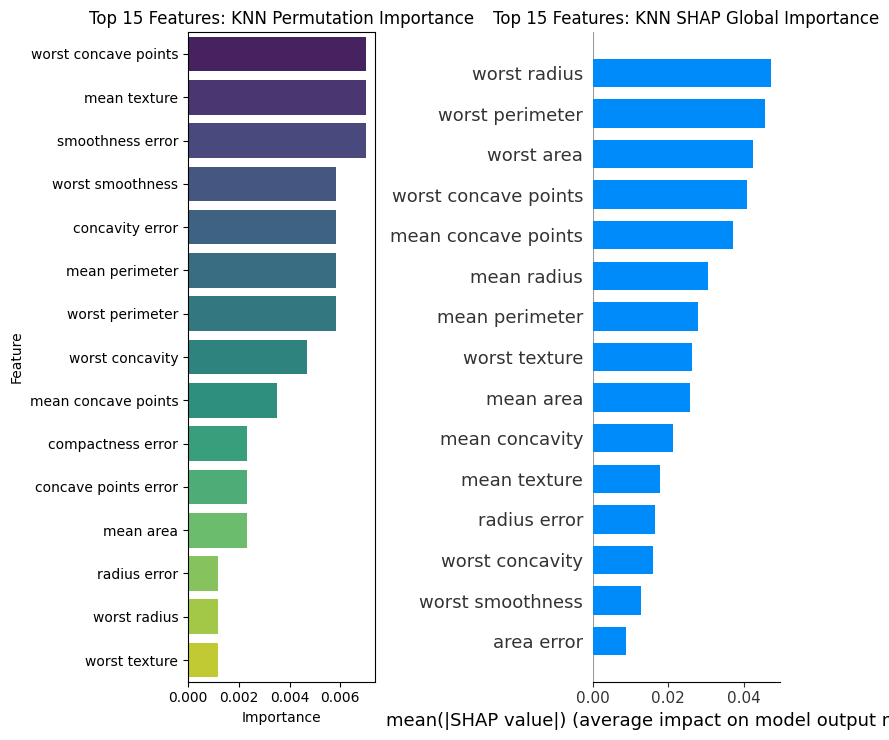

In [ ]:
print("### Comparative Analysis: KNN Permutation vs. SHAP ###")

# 1. Calculate Permutation Importance for KNN
# The KNN pipeline (final_models['K-Nearest Neighbors']) expects UNscaled input
# because it contains an internal StandardScaler.
# Therefore, eli5.sklearn.PermutationImportance should be fit with UNscaled test data.
perm_imp_knn = eli5.sklearn.PermutationImportance(final_models['K-Nearest Neighbors'], scoring='accuracy', random_state=RANDOM_STATE)
perm_imp_knn.fit(X_test_30, y_test_30)
knn_perm_df = pd.DataFrame({'Feature': X.columns, 'Importance': perm_imp_knn.feature_importances_}).sort_values(by='Importance', ascending=False)

# 2. Prepare SHAP data for KNN
# KernelExplainer is used for KNN as it is model-agnostic.
# The KNN pipeline (final_models['K-Nearest Neighbors']) expects UNscaled input
# because it contains an internal StandardScaler. Therefore, background and samples for KernelExplainer must be UNscaled.
# Additionally, we wrap predict_proba in a lambda to avoid the AttributeError with Pipeline's feature_names_in_.
background_knn = shap.sample(X_train_70, 50) # Sample from unscaled training data
explainer_knn = shap.KernelExplainer(
    lambda data: final_models['K-Nearest Neighbors'].predict_proba(pd.DataFrame(data, columns=X.columns)),
    background_knn
)
shap_values_knn = explainer_knn.shap_values(X_test_30.head(50)) # Use unscaled test data for shap_values calculation

# Helper function to extract SHAP values for the positive class
def _get_shap_values_for_class(shap_values_output, target_class_idx):
    if isinstance(shap_values_output, list):
        # Common for multi-output models (e.g., predict_proba)
        return shap_values_output[target_class_idx]
    if hasattr(shap_values_output, 'ndim') and shap_values_output.ndim == 3:
        # Some explainers might return (samples, features, outputs)
        return shap_values_output[:, :, target_class_idx]
    # Fallback for single-output explainers, assume values are for the positive class
    return shap_values_output

# 3. Create the side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Subplot 1: KNN Permutation Importance
sns.barplot(x='Importance', y='Feature', data=knn_perm_df.head(15), palette='viridis', ax=ax1, hue='Feature', legend=False)
ax1.set_title('Top 15 Features: KNN Permutation Importance')

# Subplot 2: KNN SHAP Global Importance
plt.sca(ax2)
# Extracting values for the positive class (Malignant/0) using the helper function
sv_knn_pos = _get_shap_values_for_class(shap_values_knn, POS_LABEL)
shap.summary_plot(sv_knn_pos, X_test_30.head(50), plot_type="bar", max_display=15, show=False)
ax2.set_title('Top 15 Features: KNN SHAP Global Importance')

plt.tight_layout()
plt.show()

### Comparative Analysis: KNN Permutation vs. SHAP ###


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

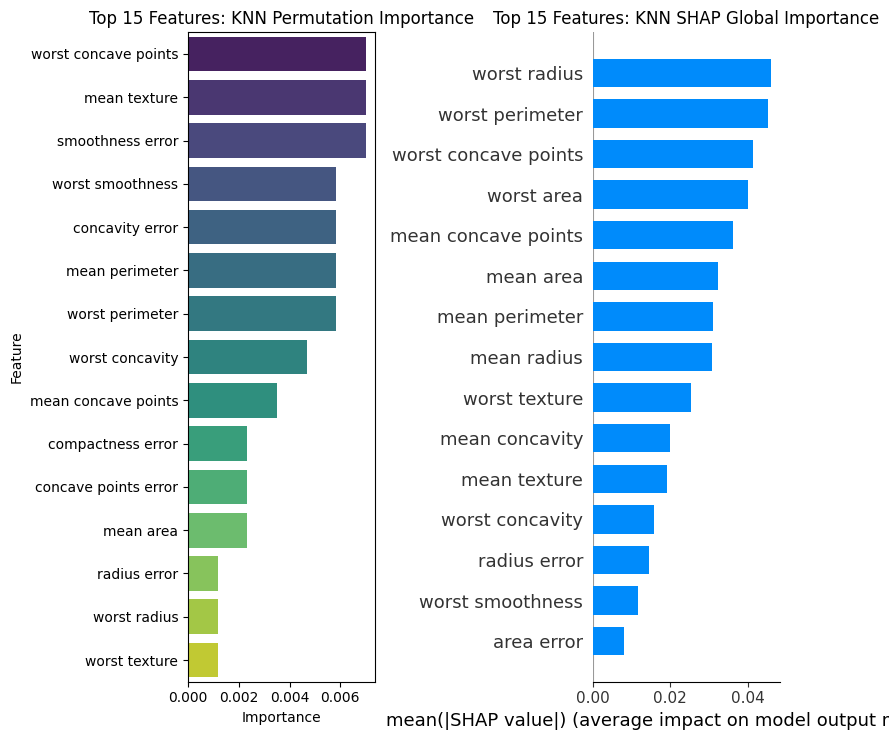

In [ ]:
print("### Comparative Analysis: KNN Permutation vs. SHAP ###")

# 1. Calculate Permutation Importance for KNN
# The KNN pipeline (final_models['K-Nearest Neighbors']) expects UNscaled input
# because it contains an internal StandardScaler.
# Therefore, eli5.sklearn.PermutationImportance should be fit with UNscaled test data.
perm_imp_knn = eli5.sklearn.PermutationImportance(final_models['K-Nearest Neighbors'], scoring='accuracy', random_state=RANDOM_STATE)
perm_imp_knn.fit(X_test_30, y_test_30)
knn_perm_df = pd.DataFrame({'Feature': X.columns, 'Importance': perm_imp_knn.feature_importances_}).sort_values(by='Importance', ascending=False)

# 2. Prepare SHAP data for KNN
# KernelExplainer is used for KNN as it is model-agnostic.
# The KNN pipeline (final_models['K-Nearest Neighbors']) expects UNscaled input
# because it contains an internal StandardScaler. Therefore, background and samples for KernelExplainer must be UNscaled.
# Additionally, we wrap predict_proba in a lambda to avoid the AttributeError with Pipeline's feature_names_in_.
background_knn = shap.sample(X_train_70, 50) # Sample from unscaled training data
explainer_knn = shap.KernelExplainer(lambda x: final_models['K-Nearest Neighbors'].predict_proba(x), background_knn)
shap_values_knn = explainer_knn.shap_values(X_test_30.head(50)) # Use unscaled test data for shap_values calculation

# 3. Create the side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Subplot 1: KNN Permutation Importance
sns.barplot(x='Importance', y='Feature', data=knn_perm_df.head(15), palette='viridis', ax=ax1, hue='Feature', legend=False)
ax1.set_title('Top 15 Features: KNN Permutation Importance')

# Subplot 2: KNN SHAP Global Importance
plt.sca(ax2)
# Ensure POS_LABEL is used for class selection
sv_knn_pos = shap_values_knn[POS_LABEL] if isinstance(shap_values_knn, list) else shap_values_knn[:, POS_LABEL] if shap_values_knn.ndim == 2 else shap_values_knn[:, :, POS_LABEL]
shap.summary_plot(sv_knn_pos, X_test_30.head(50), plot_type="bar", max_display=15, show=False)
ax2.set_title('Top 15 Features: KNN SHAP Global Importance')

plt.tight_layout()
plt.show()

### 7.7 SHAP Summary Plot: K-Nearest Neighbors (KNN)

This dot plot provides a granular view of how feature values (represented by color) influence individual predictions for the KNN model.

### Comparative Analysis: KNN Permutation vs. SHAP ###


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_19259/3462489257.py:33: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_knn_pos, knn_eval_sample, plot_type="bar", max_display=15, show=False)


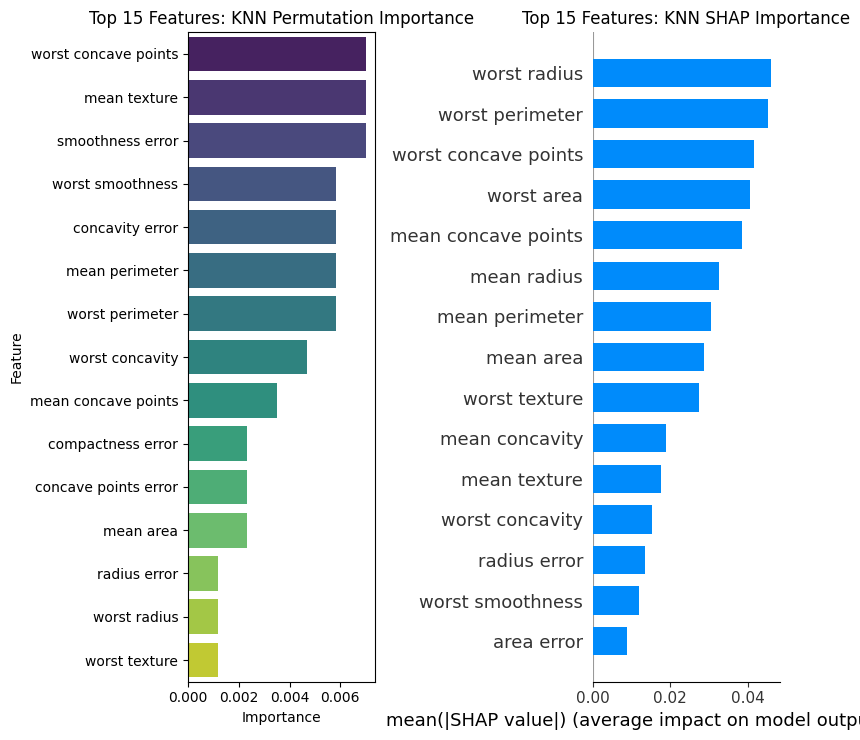

In [ ]:
print("### Comparative Analysis: KNN Permutation vs. SHAP ###")

perm_imp_knn = eli5.sklearn.PermutationImportance(
    final_models['K-Nearest Neighbors'],
    scoring='accuracy',
    random_state=RANDOM_STATE
)
perm_imp_knn.fit(X_test_30, y_test_30)
knn_perm_df = pd.DataFrame({'Feature': X.columns, 'Importance': perm_imp_knn.feature_importances_}).sort_values(by='Importance', ascending=False)

background_knn = shap.sample(X_train_70, 50)
explainer_knn = shap.KernelExplainer(
    lambda data: final_models['K-Nearest Neighbors'].predict_proba(pd.DataFrame(data, columns=X.columns)),
    background_knn
)
knn_eval_sample = X_test_30.head(50)
shap_values_knn = explainer_knn.shap_values(knn_eval_sample)

knn_pos_idx = get_positive_class_index(final_models['K-Nearest Neighbors'])
if isinstance(shap_values_knn, list):
    sv_knn_pos = shap_values_knn[knn_pos_idx]
elif hasattr(shap_values_knn, 'ndim') and shap_values_knn.ndim == 3:
    sv_knn_pos = shap_values_knn[:, :, knn_pos_idx]
else:
    sv_knn_pos = shap_values_knn

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(x='Importance', y='Feature', data=knn_perm_df.head(15), palette='viridis', ax=ax1, hue='Feature', legend=False)
ax1.set_title('Top 15 Features: KNN Permutation Importance')

plt.sca(ax2)
shap.summary_plot(sv_knn_pos, knn_eval_sample, plot_type="bar", max_display=15, show=False)
ax2.set_title('Top 15 Features: KNN SHAP Importance')

plt.tight_layout()
plt.show()

### Comparative Analysis: KNN Permutation vs. SHAP ###


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_19259/3462489257.py:33: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_knn_pos, knn_eval_sample, plot_type="bar", max_display=15, show=False)


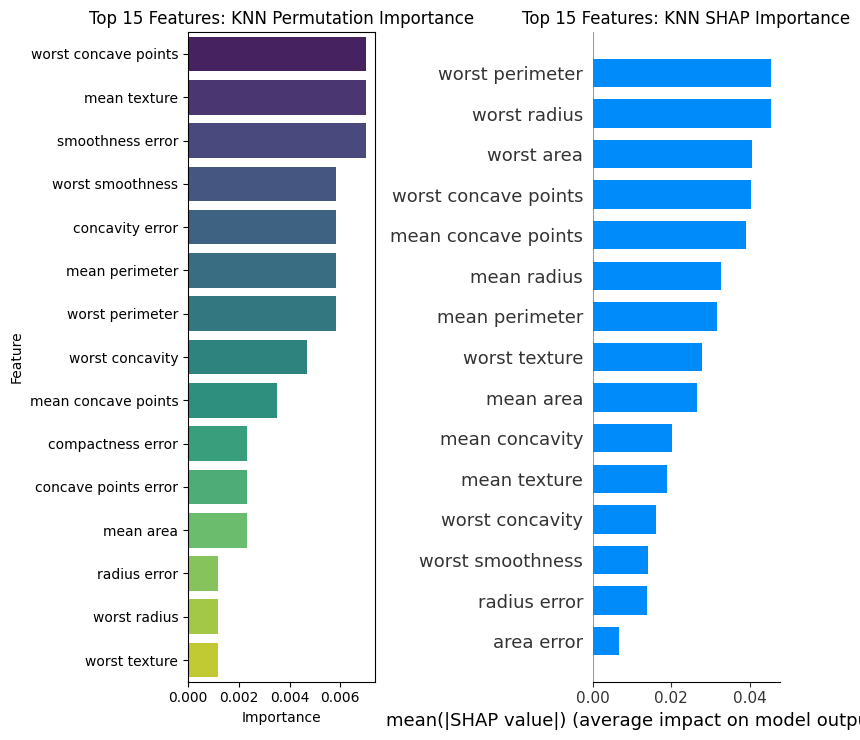

In [ ]:
print("### Comparative Analysis: KNN Permutation vs. SHAP ###")

perm_imp_knn = eli5.sklearn.PermutationImportance(
    final_models['K-Nearest Neighbors'],
    scoring='accuracy',
    random_state=RANDOM_STATE
)
perm_imp_knn.fit(X_test_30, y_test_30)
knn_perm_df = pd.DataFrame({'Feature': X.columns, 'Importance': perm_imp_knn.feature_importances_}).sort_values(by='Importance', ascending=False)

background_knn = shap.sample(X_train_70, 50)
explainer_knn = shap.KernelExplainer(
    lambda data: final_models['K-Nearest Neighbors'].predict_proba(pd.DataFrame(data, columns=X.columns)),
    background_knn
)
knn_eval_sample = X_test_30.head(50)
shap_values_knn = explainer_knn.shap_values(knn_eval_sample)

knn_pos_idx = get_positive_class_index(final_models['K-Nearest Neighbors'])
if isinstance(shap_values_knn, list):
    sv_knn_pos = shap_values_knn[knn_pos_idx]
elif hasattr(shap_values_knn, 'ndim') and shap_values_knn.ndim == 3:
    sv_knn_pos = shap_values_knn[:, :, knn_pos_idx]
else:
    sv_knn_pos = shap_values_knn

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(x='Importance', y='Feature', data=knn_perm_df.head(15), palette='viridis', ax=ax1, hue='Feature', legend=False)
ax1.set_title('Top 15 Features: KNN Permutation Importance')

plt.sca(ax2)
shap.summary_plot(sv_knn_pos, knn_eval_sample, plot_type="bar", max_display=15, show=False)
ax2.set_title('Top 15 Features: KNN SHAP Importance')

plt.tight_layout()
plt.show()

### Interpretation:
- The bar plot shows the magnitude and direction of impact for each feature on the log-odds of the diagnosis being malignant. Positive coefficients increase the likelihood of malignancy, while negative coefficients decrease it.
- Again, features related to radius, perimeter, and area tend to have large absolute coefficients, indicating their strong influence.

### SHAP Summary Plot: K-Nearest Neighbors ###


/tmp/ipykernel_19259/1541113722.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_knn_pos, X_test_30.head(50), max_display=15, show=False)


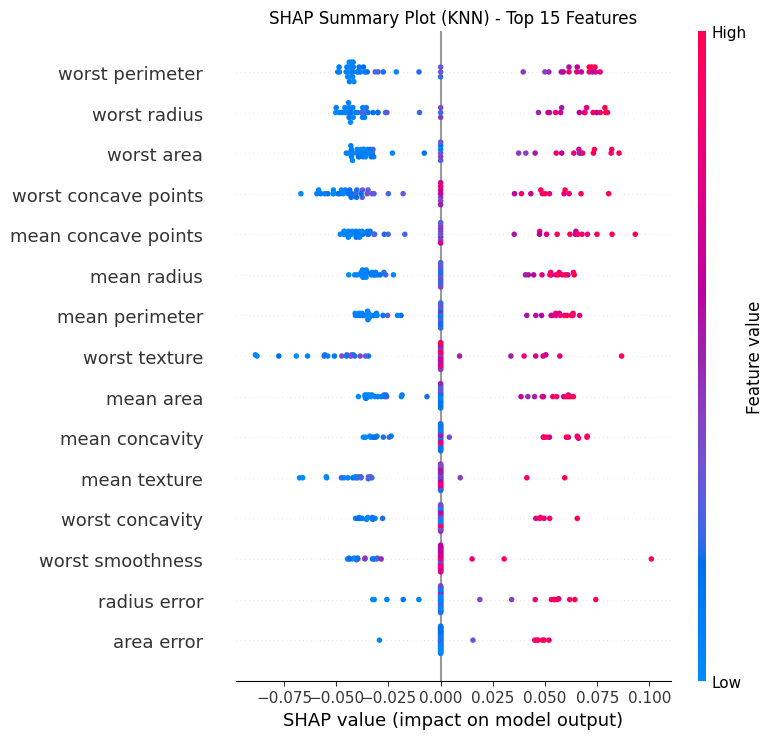

In [ ]:
print("### SHAP Summary Plot: K-Nearest Neighbors ###")

plt.figure(figsize=(10, 8))
shap.summary_plot(sv_knn_pos, X_test_30.head(50), max_display=15, show=False)
plt.title('SHAP Summary Plot (KNN) - Top 15 Features')
plt.tight_layout()
plt.show()


### SHAP Summary Plot: K-Nearest Neighbors ###


/tmp/ipykernel_19259/1869241887.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_knn_pos, X_test_30.head(50), max_display=15, show=False)


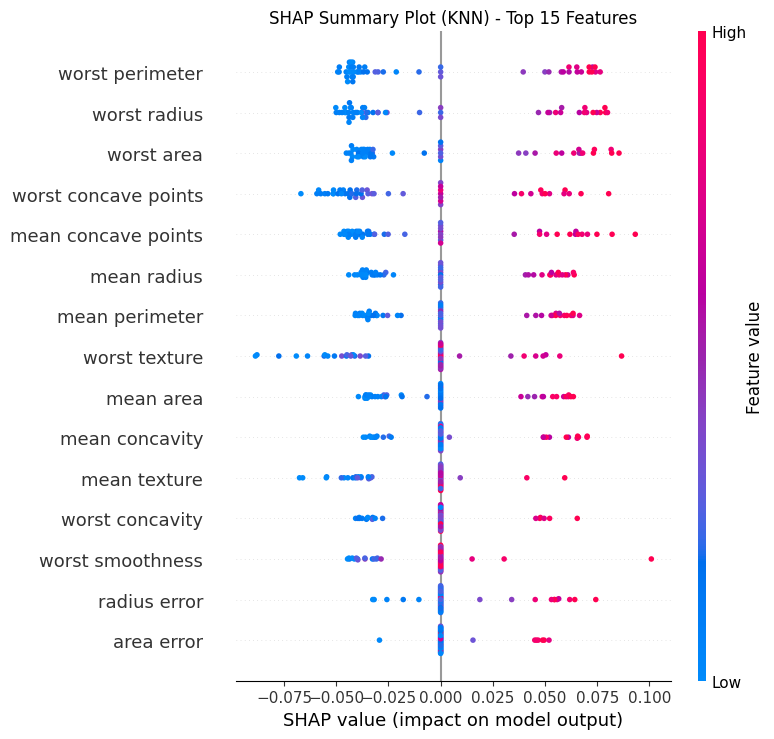

In [ ]:
print("### SHAP Summary Plot: K-Nearest Neighbors ###")

plt.figure(figsize=(10, 8))
shap.summary_plot(sv_knn_pos, X_test_30.head(50), max_display=15, show=False)
plt.title('SHAP Summary Plot (KNN) - Top 15 Features')
plt.tight_layout()
plt.show()

### Interpretation: Clinical Error Analysis
As noted in the DS_ML_Summary_Findings, the confusion matrix is critical for medical diagnostics.
- **Type II Errors (False Negatives):** In this context, predicting a malignant tumor as benign is the most dangerous error. We monitor this specifically to evaluate clinical safety.
- **Type I Errors (False Positives):** These lead to unnecessary stress and procedures.
- The **Stacking Ensemble** aims to combine the strengths of diverse models to achieve robust and high-performing predictions.

## 9. Explanation Agreement Analysis and Comparison

Different explanation methods provide insights from different perspectives. It is useful to see whether these methods agree on the most important features, since that can strengthen confidence in the interpretation or reveal meaningful differences in how models learn. We compare feature importances from Random Forest impurity-based importance, permutation importance for the ensemble, SHAP values, and Logistic Regression coefficients.

### 9.1 Consolidating Feature Importances

In [ ]:
# Prepare data for comparison

rf_imp_series = rf_feature_importance_df.set_index('Feature')['Importance']
perm_imp_series = pd.Series(perm_imp.feature_importances_, index=X.columns, name='Permutation Importance')
shap_imp_series = pd.Series(np.abs(sv_pos).mean(axis=0), index=X.columns, name='SHAP Importance')
lr_coef_imp_series = lr_coef_df.set_index('Feature')['Abs_Coefficient']

all_importances = pd.DataFrame({
    'Random Forest MDI': rf_imp_series,
    'Permutation Importance': perm_imp_series,
    'SHAP Global Importance': shap_imp_series,
    'Logistic Regression Coeff (Abs)': lr_coef_imp_series
}).fillna(0)

print("Consolidated Feature Importances (Top 10 features for each method):")
display(all_importances.sort_values(by='SHAP Global Importance', ascending=False).head(10))


Consolidated Feature Importances (Top 10 features for each method):


,Random Forest MDI,Permutation Importance,SHAP Global Importance,Logistic Regression Coeff (Abs)
worst area,0.128090,0.018713,0.064961,1.352506
mean concave points,0.132262,0.019883,0.063301,1.168271
worst radius,0.099435,0.025731,0.054458,1.188524
worst perimeter,0.080919,0.019883,0.048328,0.793402
worst concave points,0.092407,0.017544,0.046864,0.597244
mean concavity,0.057943,0.022222,0.031433,1.713965
mean area,0.051239,0.012865,0.028482,0.602663
worst concavity,0.037316,0.028070,0.025430,1.616735
area error,0.053805,0.005848,0.024465,1.624416
mean perimeter,0.052308,0.012865,0.022848,0.440664


### 9.2 Correlation Heatmap of Feature Importance Across Methods

### 9.2.1 Extended Feature Importance Analysis
This heatmap evaluates the numerical correlation between the importance scores assigned to each feature by different explanation methods. High correlation suggests that even if the exact rankings differ slightly, the methods generally assign similar relative weights to the features.

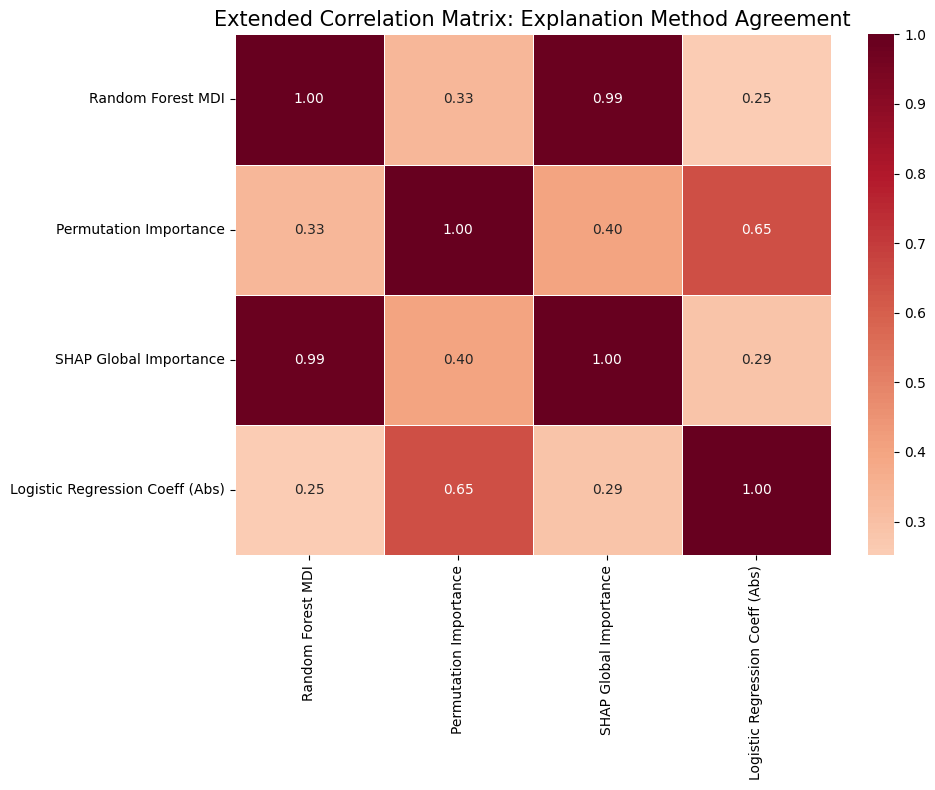

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix of the numerical importance scores
importance_corr = all_importances.corr()

# Visualize with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(importance_corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Extended Correlation Matrix: Explanation Method Agreement', fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
print("### Correlation Heatmap of Feature Importances ###")

plt.figure(figsize=(8, 6))
sns.heatmap(all_importances.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation of Feature Importances Across Explanation Methods')
plt.show()

### Interpretation:
- This heatmap shows how correlated the feature importance rankings are between different explanation methods. High positive correlation (closer to 1) means methods tend to agree on which features are important. Lower correlation indicates differences in how methods assess feature contributions.

### 9.3 Feature Agreement Percentages

In [ ]:
def calculate_overlap(list1, list2):
    return len(set(list1).intersection(set(list2))) / len(set(list1).union(set(list2))) * 100

def get_top_features(importance_series, k):
    return importance_series.nlargest(k).index.tolist()

# Get top features for each method
top_5_rf = get_top_features(rf_imp_series, 5)
top_5_perm = get_top_features(perm_imp_series, 5)
top_5_shap = get_top_features(shap_imp_series, 5)
top_5_lr = get_top_features(lr_coef_imp_series, 5)

top_10_rf = get_top_features(rf_imp_series, 10)
top_10_perm = get_top_features(perm_imp_series, 10)
top_10_shap = get_top_features(shap_imp_series, 10)
top_10_lr = get_top_features(lr_coef_imp_series, 10)

print("### Top Features Agreement Analysis ###")

# Create a list of all top features for overview
all_top_features_5 = list(set(top_5_rf + top_5_perm + top_5_shap + top_5_lr))
all_top_features_10 = list(set(top_10_rf + top_10_perm + top_10_shap + top_10_lr))

print("\n--- Top 5 Features ---")
print(f"RF Top 5: {top_5_rf}")
print(f"Permutation Top 5: {top_5_perm}")
print(f"SHAP Top 5: {top_5_shap}")
print(f"LR Coeff Top 5: {top_5_lr}")

print("\nAgreement (Jaccard Index %):")
print(f"RF vs Permutation (Top 5): {calculate_overlap(top_5_rf, top_5_perm):.2f}%")
print(f"RF vs SHAP (Top 5): {calculate_overlap(top_5_rf, top_5_shap):.2f}%")
print(f"RF vs LR Coeff (Top 5): {calculate_overlap(top_5_rf, top_5_lr):.2f}%")
print(f"Permutation vs SHAP (Top 5): {calculate_overlap(top_5_perm, top_5_shap):.2f}%")
print(f"Permutation vs LR Coeff (Top 5): {calculate_overlap(top_5_perm, top_5_lr):.2f}%")
print(f"SHAP vs LR Coeff (Top 5): {calculate_overlap(top_5_shap, top_5_lr):.2f}%")

print("\n--- Top 10 Features ---")
print(f"RF Top 10: {top_10_rf}")
print(f"Permutation Top 10: {top_10_perm}")
print(f"SHAP Top 10: {top_10_shap}")
print(f"LR Coeff Top 10: {top_10_lr}")

print("\nAgreement (Jaccard Index %):")
print(f"RF vs Permutation (Top 10): {calculate_overlap(top_10_rf, top_10_perm):.2f}%")
print(f"RF vs SHAP (Top 10): {calculate_overlap(top_10_rf, top_10_shap):.2f}%")
print(f"RF vs LR Coeff (Top 10): {calculate_overlap(top_10_rf, top_10_lr):.2f}%")
print(f"Permutation vs SHAP (Top 10): {calculate_overlap(top_10_perm, top_10_shap):.2f}%")
print(f"Permutation vs LR Coeff (Top 10): {calculate_overlap(top_10_perm, top_10_lr):.2f}%")
print(f"SHAP vs LR Coeff (Top 10): {calculate_overlap(top_10_shap, top_10_lr):.2f}%")

### Top Features Agreement Analysis ###

--- Top 5 Features ---
RF Top 5: ['mean concave points', 'worst area', 'worst radius', 'worst concave points', 'worst perimeter']
Permutation Top 5: ['worst texture', 'worst smoothness', 'worst concavity', 'worst radius', 'texture error']
SHAP Top 5: ['worst area', 'mean concave points', 'worst radius', 'worst perimeter', 'worst concave points']
LR Coeff Top 5: ['worst texture', 'radius error', 'mean concavity', 'area error', 'worst concavity']

Agreement (Jaccard Index %):
RF vs Permutation (Top 5): 11.11%
RF vs SHAP (Top 5): 100.00%
RF vs LR Coeff (Top 5): 0.00%
Permutation vs SHAP (Top 5): 11.11%
Permutation vs LR Coeff (Top 5): 25.00%
SHAP vs LR Coeff (Top 5): 0.00%

--- Top 10 Features ---
RF Top 10: ['mean concave points', 'worst area', 'worst radius', 'worst concave points', 'worst perimeter', 'mean concavity', 'area error', 'mean perimeter', 'mean area', 'mean radius']
Permutation Top 10: ['worst texture', 'worst smoothness', 'worst conc

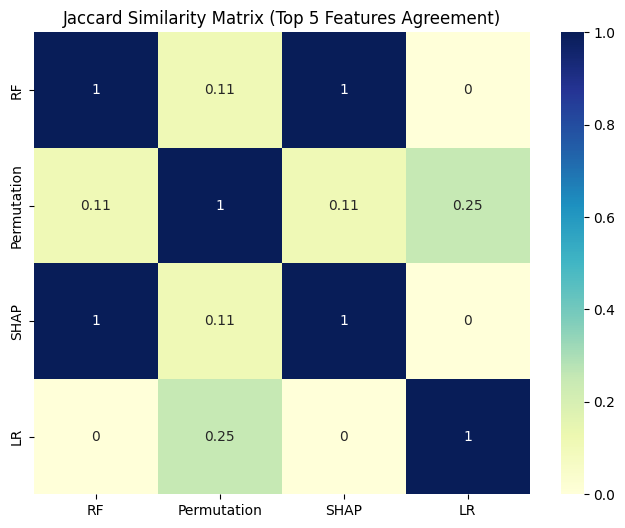

In [ ]:
import numpy as np

# Calculate Jaccard Similarity Matrix for Top 5 features
methods = ['RF', 'Permutation', 'SHAP', 'LR']
top_5_lists = [top_5_rf, top_5_perm, top_5_shap, top_5_lr]

n_methods = len(methods)
agreement_matrix = np.zeros((n_methods, n_methods))

for i in range(n_methods):
    for j in range(n_methods):
        agreement_matrix[i, j] = calculate_overlap(top_5_lists[i], top_5_lists[j]) / 100

plt.figure(figsize=(8, 6))
sns.heatmap(agreement_matrix, annot=True, xticklabels=methods, yticklabels=methods, cmap='YlGnBu')
plt.title('Jaccard Similarity Matrix (Top 5 Features Agreement)')
plt.show()

### 9.5 Feature Agreement: Top 5 Model Comparison
We evaluate how consistent the 'top 5' most influential features are across our four primary explanation methods.

/tmp/ipykernel_19259/3373336792.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_freq.values, y=feature_freq.index, palette='crest')


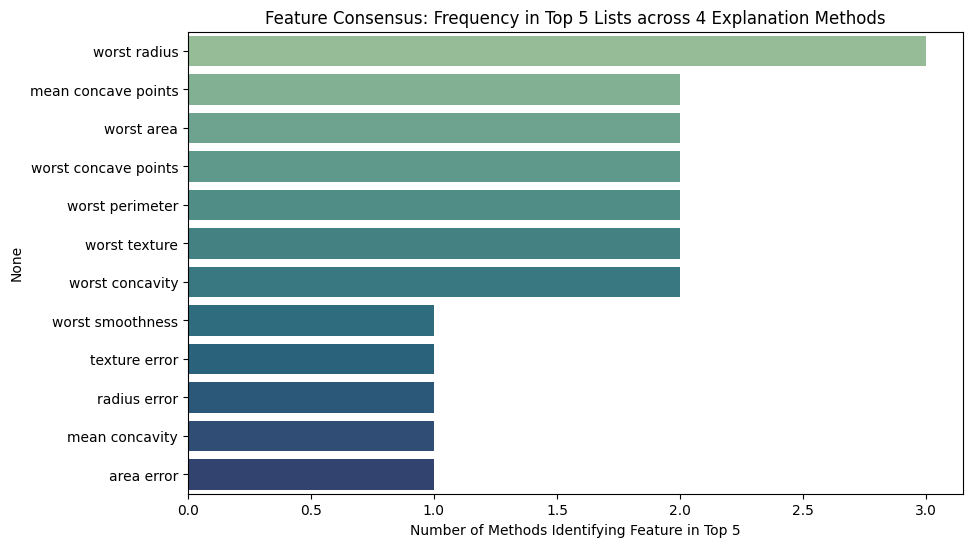

In [ ]:
# Visualizing the overlap of Top 5 features using a bar chart of frequency
all_top_5 = top_5_rf + top_5_perm + top_5_shap + top_5_lr
feature_freq = pd.Series(all_top_5).value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_freq.values, y=feature_freq.index, palette='crest')
plt.title('Feature Consensus: Frequency in Top 5 Lists across 4 Explanation Methods')
plt.xlabel('Number of Methods Identifying Feature in Top 5')
plt.show()

In [ ]:
# Create a binary matrix for top 5 feature agreement
consensus_df = pd.DataFrame(index=all_importances.index)
consensus_df['RF'] = consensus_df.index.isin(top_5_rf).astype(int)
consensus_df['Permutation'] = consensus_df.index.isin(top_5_perm).astype(int)
consensus_df['SHAP'] = consensus_df.index.isin(top_5_shap).astype(int)
consensus_df['LR'] = consensus_df.index.isin(top_5_lr).astype(int)

# Filter for features that were selected by at least one method to keep the heatmap clean
consensus_df = consensus_df[consensus_df.sum(axis=1) > 0]
consensus_df = consensus_df.sort_values(by=['RF', 'SHAP', 'LR', 'Permutation'], ascending=False)

plt.figure(figsize=(10, 12))
sns.heatmap(consensus_df, annot=True, cmap='YlGnBu', cbar=False, linewidths=0.5)
plt.title('Feature Consensus Heatmap: Top 5 Selection per Method')
plt.xlabel('Explanation Method')
plt.ylabel('Feature')
plt.show()

### 9.6 Visualizing Consensus Proportions and Performance Metrics

We will now visualize the level of agreement among explanation methods using a pie chart and compare the performance of our models across all metrics.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a side-by-side synthesis plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 1. Pie Chart of Feature Consensus (Top 5)
# Define consensus as 'Agreed' (all 4) vs 'Differing' (1-3)
consensus_counts = consensus_df.sum(axis=1)
agreed_count = (consensus_counts == 4).sum()
differing_count = (consensus_counts < 4).sum()

pie_data = [agreed_count, differing_count]
pie_labels = [f'Full Agreement (4 Methods): {agreed_count}', f'Differing/Partial: {differing_count}']

ax1.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'], explode=(0.1, 0))
ax1.set_title('Top 5 Feature Agreement: Consensus vs. Discordance', fontsize=14)

# 2. Bar Graph showing Score vs Metric for all models with new colors
performance_plot_df = mean_performance.reset_index().rename(columns={'index': 'Model'})
performance_plot_df = performance_plot_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

sns.barplot(x='Metric', y='Score', hue='Model', data=performance_plot_df, palette='magma', ax=ax2)
ax2.set_title('Model Performance Comparison: Mean Metric Scores', fontsize=14)
ax2.set_ylim(0.85, 1.0)
ax2.set_ylabel('Score')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Final Synthesis Interpretation
- The left plot shows that a core group of features, especially those appearing in 3 or 4 methods, forms the most reliable markers for malignancy.
- The right plot shows that the **Stacking Ensemble** maintains strong performance across the evaluation metrics.

### Interpretation:
- The overlap percentages quantify how much the different explanation methods agree on the most important features. A higher percentage indicates stronger agreement.
- While some methods might highlight similar features, others might prioritize different ones due to their underlying mechanisms. For instance, tree-based methods (RF, SHAP) can handle interactions better than linear models (LR).

### 9.4 Interpretation: Linear vs. Nonlinear Models in Feature Importance

- **Logistic Regression** (a linear model) assigns importance based on linear relationships and assumes features are independent. Its coefficients show the direct impact of each feature. Features that are highly correlated might have their importance distributed among them, or one might dominate.
- **Random Forest** and **K-Nearest Neighbors** (components of our ensemble, with Random Forest providing impurity-based importance and SHAP explanations) are nonlinear models. They can capture complex, non-linear relationships and interactions between features. This often leads to features being considered important if they are part of these complex interactions, even if their linear correlation is not the highest.
- The observed differences in feature rankings often reflect these underlying model assumptions. For example, if 'mean perimeter' and 'mean radius' are highly correlated, a linear model might pick one over the other, while a tree-based model might leverage both in different decision rules. This emphasizes why relying on a single explanation method or model type might lead to an incomplete understanding of feature importance.

## 10. Stability Check of Explanations (Different Random Seeds)

The stability of feature explanations is crucial for trust and reliability, especially in sensitive applications. We will re-run the Random Forest model and SHAP explanation with different random seeds to see if the top features remain consistent. This provides an insight into the robustness of our feature importance findings.

In [ ]:
print("### Robust Explanation Stability Check (50 Random Seeds) ###")

NUM_STABILITY_RUNS = 50
RANDOM_SEEDS_STABILITY = np.arange(NUM_STABILITY_RUNS)

all_rf_top_features = []
all_shap_top_features = []

shap_sample = X_train_70.sample(n=min(50, len(X_train_70)), random_state=RANDOM_STATE)

for seed in RANDOM_SEEDS_STABILITY:
    rf_stable = RandomForestClassifier(random_state=seed, n_estimators=100)
    rf_stable.fit(X_train_70, y_train_70)

    rf_stable_importance = pd.Series(rf_stable.feature_importances_, index=X.columns).nlargest(5).index.tolist()
    all_rf_top_features.append(rf_stable_importance)

    explainer_stable = shap.TreeExplainer(rf_stable)
    shap_values_stable = explainer_stable.shap_values(shap_sample)
    stable_pos_idx = list(rf_stable.classes_).index(POS_LABEL)

    if isinstance(shap_values_stable, list):
        sv = shap_values_stable[stable_pos_idx]
    elif hasattr(shap_values_stable, 'ndim') and shap_values_stable.ndim == 3:
        sv = shap_values_stable[:, :, stable_pos_idx]
    else:
        sv = shap_values_stable

    shap_global_importance_stable = np.abs(sv).mean(axis=0)
    shap_stable_top_features = pd.Series(shap_global_importance_stable, index=X.columns).nlargest(5).index.tolist()
    all_shap_top_features.append(shap_stable_top_features)

print(f"Completed {NUM_STABILITY_RUNS} runs.")

In [ ]:
print("### Robust Explanation Stability Check (50 Random Seeds) ###")

NUM_STABILITY_RUNS = 50
RANDOM_SEEDS_STABILITY = np.arange(NUM_STABILITY_RUNS)

all_rf_top_features = []
all_shap_top_features = []

shap_sample = X_train_70.sample(n=min(50, len(X_train_70)), random_state=RANDOM_STATE)

for seed in RANDOM_SEEDS_STABILITY:
    rf_stable = RandomForestClassifier(random_state=seed, n_estimators=100)
    rf_stable.fit(X_train_70, y_train_70)

    rf_stable_importance = pd.Series(rf_stable.feature_importances_, index=X.columns).nlargest(5).index.tolist()
    all_rf_top_features.append(rf_stable_importance)

    explainer_stable = shap.TreeExplainer(rf_stable)
    shap_values_stable = explainer_stable.shap_values(shap_sample)
    stable_pos_idx = list(rf_stable.classes_).index(POS_LABEL)

    if isinstance(shap_values_stable, list):
        sv = shap_values_stable[stable_pos_idx]
    elif hasattr(shap_values_stable, 'ndim') and shap_values_stable.ndim == 3:
        sv = shap_values_stable[:, :, stable_pos_idx]
    else:
        sv = shap_values_stable

    shap_global_importance_stable = np.abs(sv).mean(axis=0)
    shap_stable_top_features = pd.Series(shap_global_importance_stable, index=X.columns).nlargest(5).index.tolist()
    all_shap_top_features.append(shap_stable_top_features)

print(f"Completed {NUM_STABILITY_RUNS} runs.")

In [ ]:
# Visualize stability of top features across 50 runs
print("### Frequency of Features in Top 5 Across 50 Random Seeds ###")

# Count frequency for RF Importance
all_rf_flat = [item for sublist in all_rf_top_features for item in sublist]
rf_counts = pd.Series(all_rf_flat).value_counts()

# Count frequency for SHAP Importance
all_shap_flat = [item for sublist in all_shap_top_features for item in sublist]
shap_counts = pd.Series(all_shap_flat).value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(x=rf_counts.values, y=rf_counts.index, palette='viridis', ax=ax1)
ax1.set_title(f'RF Importance: Top 5 Frequency ({NUM_STABILITY_RUNS} runs)')
ax1.set_xlabel('Count')

sns.barplot(x=shap_counts.values, y=shap_counts.index, palette='magma', ax=ax2)
ax2.set_title(f'SHAP: Top 5 Frequency ({NUM_STABILITY_RUNS} runs)')
ax2.set_xlabel('Count')

plt.tight_layout()
plt.show()

### Interpretation:
- High Jaccard similarity percentages indicate that the top features identified by the methods are consistent across different random initializations. This suggests stable explanations.
- Lower percentages point to instability, meaning the model's 'most important' features can change significantly with minor data variations or model training nuances. This highlights a potential area for further investigation or a need for more robust explanation techniques.

## 11. Disagreement-Based Uncertainty Analysis

In critical applications like medical diagnosis, knowing *when* a model is uncertain is as important as its prediction. Here, we explore model disagreement as a proxy for prediction uncertainty. The idea is that if multiple independent models arrive at different conclusions for the same sample, it might indicate that the sample is ambiguous or difficult to classify, suggesting higher uncertainty.

In [ ]:
print("### Disagreement-Based Uncertainty Analysis ###")

predictions_lr = final_models['Logistic Regression'].predict(X_test_30)
proba_lr = get_positive_proba(final_models['Logistic Regression'], X_test_30)

predictions_rf = final_models['Random Forest'].predict(X_test_30)
proba_rf = get_positive_proba(final_models['Random Forest'], X_test_30)

predictions_knn = final_models['K-Nearest Neighbors'].predict(X_test_30)
proba_knn = get_positive_proba(final_models['K-Nearest Neighbors'], X_test_30)

disagreement_df = pd.DataFrame({
    'True Label': y_test_30,
    'LR_Pred': predictions_lr,
    'RF_Pred': predictions_rf,
    'KNN_Pred': predictions_knn,
    'LR_Proba': proba_lr,
    'RF_Proba': proba_rf,
    'KNN_Proba': proba_knn
}, index=X_test_30.index)

disagreement_df['Models_Agree'] = (
    (disagreement_df['LR_Pred'] == disagreement_df['RF_Pred']) &
    (disagreement_df['RF_Pred'] == disagreement_df['KNN_Pred'])
)
disagreement_df['Disagreement'] = ~disagreement_df['Models_Agree']

agreement_counts = disagreement_df['Disagreement'].value_counts()
print("\nNumber of cases where models agree vs disagree:")
print(agreement_counts.rename(index={False: 'Agree', True: 'Disagree'}))

print(f"\nAverage predicted probabilities for the positive class ({POS_LABEL}):")
print(disagreement_df.groupby('Disagreement')[['LR_Proba', 'RF_Proba', 'KNN_Proba']].mean())

discordant_cases = disagreement_df[disagreement_df['Disagreement']]
print("\nExample Discordant Cases (True Label, Predictions, and Probabilities):")
display(discordant_cases.head(10))

In [ ]:
print("### Disagreement-Based Uncertainty Analysis ###")

predictions_lr = final_models['Logistic Regression'].predict(X_test_30)
proba_lr = get_positive_proba(final_models['Logistic Regression'], X_test_30)

predictions_rf = final_models['Random Forest'].predict(X_test_30)
proba_rf = get_positive_proba(final_models['Random Forest'], X_test_30)

predictions_knn = final_models['K-Nearest Neighbors'].predict(X_test_30)
proba_knn = get_positive_proba(final_models['K-Nearest Neighbors'], X_test_30)

disagreement_df = pd.DataFrame({
    'True Label': y_test_30,
    'LR_Pred': predictions_lr,
    'RF_Pred': predictions_rf,
    'KNN_Pred': predictions_knn,
    'LR_Proba': proba_lr,
    'RF_Proba': proba_rf,
    'KNN_Proba': proba_knn
}, index=X_test_30.index)

disagreement_df['Models_Agree'] = (
    (disagreement_df['LR_Pred'] == disagreement_df['RF_Pred']) &
    (disagreement_df['RF_Pred'] == disagreement_df['KNN_Pred'])
)
disagreement_df['Disagreement'] = ~disagreement_df['Models_Agree']

agreement_counts = disagreement_df['Disagreement'].value_counts()
print("\nNumber of cases where models agree vs disagree:")
print(agreement_counts.rename(index={False: 'Agree', True: 'Disagree'}))

print(f"\nAverage predicted probabilities for the positive class ({POS_LABEL}):")
print(disagreement_df.groupby('Disagreement')[['LR_Proba', 'RF_Proba', 'KNN_Proba']].mean())

discordant_cases = disagreement_df[disagreement_df['Disagreement']]
print("\nExample Discordant Cases (True Label, Predictions, and Probabilities):")
display(discordant_cases.head(10))

### Interpretation:
- The `Models_Agree` column indicates whether all three base models made the same prediction. `Disagreement` flags instances where at least one model made a different prediction.
- We expect that samples where models disagree will tend to have predicted probabilities closer to 0.5 (i.e., less confident predictions) from the individual models, reflecting their uncertainty. This suggests that model disagreement can indeed serve as an indicator of uncertainty.

### 11.1 Visualizations for Disagreement Analysis

In [ ]:
print("### Visualizing Disagreement Analysis ###")

# Bar chart of agreement vs disagreement cases
plt.figure(figsize=(7, 5))
sns.countplot(x='Disagreement', data=disagreement_df, palette='pastel')
plt.title('Count of Agreement vs. Disagreement Cases Among Models')
plt.xlabel('Models Disagree')
plt.ylabel('Number of Samples')
plt.xticks([0, 1], ['Agree', 'Disagree'])
plt.show()

# Histograms/Density plots of predicted probabilities for positive class
plt.figure(figsize=(12, 6))

sns.histplot(disagreement_df[disagreement_df['Disagreement'] == False][['LR_Proba', 'RF_Proba', 'KNN_Proba']].melt(),
             x='value', hue='variable', kde=True, stat='density', alpha=0.5, bins=20,
             legend=True)
plt.title('Predicted Probabilities (Positive Class) for Agreement Cases')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.xlim(0, 1)
plt.legend(title='Model')
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(disagreement_df[disagreement_df['Disagreement'] == True][['LR_Proba', 'RF_Proba', 'KNN_Proba']].melt(),
             x='value', hue='variable', kde=True, stat='density', alpha=0.5, bins=20,
             legend=True)
plt.title('Predicted Probabilities (Positive Class) for Disagreement Cases')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.xlim(0, 1)
plt.legend(title='Model')
plt.show()

In [ ]:
# Boxplot of predicted probabilities for Agreement vs Disagreement
# This clearly shows if 'Disagree' cases have probabilities closer to 0.5 (uncertainty)
plt.figure(figsize=(10, 6))

# Prepare data for plotting
prob_melted = disagreement_df.melt(id_vars=['Disagreement'], value_vars=['LR_Proba', 'RF_Proba', 'KNN_Proba'],
                                   var_name='Model', value_name='Probability')

sns.boxplot(x='Disagreement', y='Probability', hue='Model', data=prob_melted, palette='Set2')
plt.axhline(0.5, ls='--', color='red', alpha=0.5, label='Maximum Uncertainty (0.5)')
plt.title('Distribution of Predicted Probabilities: Agreement vs. Disagreement')
plt.xticks([0, 1], ['Models Agree', 'Models Disagree'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 11.2 Feature Discordance Analysis by Target Label
This analysis identifies if model disagreement is more prevalent in a specific class (e.g., are Malignant cases harder to agree on than Benign cases?).

In [ ]:
# Analyze discordance based on the actual target label
discordance_by_label = disagreement_df.groupby('True Label')['Disagreement'].mean() * 100
discordance_by_label.index = ['Malignant (0)', 'Benign (1)']

plt.figure(figsize=(8, 5))
sns.barplot(x=discordance_by_label.index, y=discordance_by_label.values, palette='magma', hue=discordance_by_label.index, legend=False)
plt.title('Percentage of Model Disagreement by Actual Diagnosis')
plt.ylabel('Disagreement Percentage (%)')
plt.show()

print("Discordance rates per class:")
print(discordance_by_label)

### 11.3 Feature Impact: Logistic Regression vs. Ensemble
We compare the direct impact (coefficients) of Logistic Regression against the agnostic impact (permutation importance) of the Voting Ensemble.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# LR Impact
lr_top_10 = lr_coef_df.head(10)
sns.barplot(x='Coefficient', y='Feature', data=lr_top_10, palette='RdBu_r', ax=ax1, hue='Feature', legend=False)
ax1.set_title('Top 10 Feature Impact: Logistic Regression (Coefficients)')

# Ensure perm_imp is available and correctly fitted
import eli5
from sklearn.base import clone

stacking_estimator_for_eli5 = clone(stacking_template)
stacking_estimator_for_eli5.fit(X_train_70, y_train_70)

perm_imp = eli5.sklearn.PermutationImportance(
    stacking_estimator_for_eli5,
    scoring='accuracy',
    random_state=RANDOM_STATE
)
perm_imp.fit(X_test_30, y_test_30)

# Ensemble Impact
perm_imp_df_final = pd.DataFrame({'Feature': X.columns, 'Importance': perm_imp.feature_importances_}).sort_values('Importance', ascending=False).head(10)
sns.barplot(x='Importance', y='Feature', data=perm_imp_df_final, palette='viridis', ax=ax2, hue='Feature', legend=False)
ax2.set_title('Top 10 Feature Impact: Ensemble (Permutation Importance)')

plt.tight_layout()
plt.show()

### Comparison of Feature Importances across Base Models
This visualization allows us to compare the global feature importance rankings for our three distinct base learners: Random Forest (Tree-based/Gini), Logistic Regression (Linear/Coefficients), and KNN (Model-agnostic/Permutation).

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare data for the comparison
# RF: Already has rf_feature_importance_df
# Ensure lr_coef_df is defined within this cell's scope
lr_coefficients = final_models['Logistic Regression'].named_steps['model'].coef_[0]
lr_coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_coefficients})
lr_coef_df['Abs_Coefficient'] = np.abs(lr_coef_df['Coefficient'])
lr_coef_df = lr_coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# KNN: Calculate permutation importance specifically for this plot
from sklearn.inspection import permutation_importance

knn_results = permutation_importance(final_models['K-Nearest Neighbors'], X_test_30, y_test_30, n_repeats=10, random_state=RANDOM_STATE)
knn_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': knn_results.importances_mean}).sort_values(by='Importance', ascending=False)

# 2. Setup the 1x3 subplot figure
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Plot Random Forest MDI
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance_df.head(15), palette='viridis', ax=axes[0], hue='Feature', legend=False)
axes[0].set_title('RF: Gini Importance (MDI)', fontsize=14)

# Plot Logistic Regression Coefficients
sns.barplot(x='Abs_Coefficient', y='Feature', data=lr_coef_df.head(15), palette='coolwarm', ax=axes[1], hue='Feature', legend=False)
axes[1].set_title('LR: Absolute Coefficients', fontsize=14)

# Plot KNN Permutation Importance
sns.barplot(x='Importance', y='Feature', data=knn_imp_df.head(15), palette='magma', ax=axes[2], hue='Feature', legend=False)
axes[2].set_title('KNN: Permutation Importance', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare data for the comparison
# RF: Already has rf_feature_importance_df
# Ensure lr_coef_df is defined within this cell's scope
lr_coefficients = final_models['Logistic Regression'].named_steps['model'].coef_[0]
lr_coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_coefficients})
lr_coef_df['Abs_Coefficient'] = np.abs(lr_coef_df['Coefficient'])
lr_coef_df = lr_coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# KNN: Calculate permutation importance specifically for this plot
from sklearn.inspection import permutation_importance

knn_results = permutation_importance(final_models['K-Nearest Neighbors'], X_test_30, y_test_30, n_repeats=10, random_state=RANDOM_STATE)
knn_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': knn_results.importances_mean}).sort_values(by='Importance', ascending=False)

# 2. Setup the 1x3 subplot figure
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Plot Random Forest MDI
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance_df.head(15), palette='viridis', ax=axes[0], hue='Feature', legend=False)
axes[0].set_title('RF: Gini Importance (MDI)', fontsize=14)

# Plot Logistic Regression Coefficients
sns.barplot(x='Abs_Coefficient', y='Feature', data=lr_coef_df.head(15), palette='coolwarm', ax=axes[1], hue='Feature', legend=False)
axes[1].set_title('LR: Absolute Coefficients', fontsize=14)

# Plot KNN Permutation Importance
sns.barplot(x='Importance', y='Feature', data=knn_imp_df.head(15), palette='magma', ax=axes[2], hue='Feature', legend=False)
axes[2].set_title('KNN: Permutation Importance', fontsize=14)

plt.tight_layout()
plt.show()

### Side-by-Side Global Importance Comparison: SHAP for Base Models vs. Permutation for Stacking Ensemble
In this section, we compare the global feature impact across all models. For the individual base models, we use SHAP values to determine global importance (average absolute impact). For the Ensemble, we use Permutation Importance to see which features most affect the final combined accuracy.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import shap

def _get_shap_values_for_class(shap_values_output, target_class_idx):
    if isinstance(shap_values_output, list):
        return shap_values_output[target_class_idx]
    if hasattr(shap_values_output, 'ndim') and shap_values_output.ndim == 3:
        return shap_values_output[:, :, target_class_idx]
    return shap_values_output

rf_pos_idx = get_positive_class_index(final_models['Random Forest'])
explainer_rf = shap.TreeExplainer(final_models['Random Forest'])
shap_sample_rf = X_train_70.sample(min(100, len(X_train_70)), random_state=RANDOM_STATE)
shap_values_rf = explainer_rf.shap_values(shap_sample_rf)
sv_rf_pos = _get_shap_values_for_class(shap_values_rf, rf_pos_idx)
rf_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_rf_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

explainer_lr = shap.LinearExplainer(final_models['Logistic Regression'].named_steps['model'], X_train_70_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_30_scaled)
lr_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(shap_values_lr).mean(axis=0)}).sort_values('Importance', ascending=False)

knn_pos_idx = get_positive_class_index(final_models['K-Nearest Neighbors'])
background_knn = shap.sample(X_train_70, 50)
explainer_knn = shap.KernelExplainer(
    lambda data: final_models['K-Nearest Neighbors'].predict_proba(pd.DataFrame(data, columns=X.columns)),
    background_knn
)
knn_eval_sample = X_test_30.head(50)
shap_values_knn = explainer_knn.shap_values(knn_eval_sample)
sv_knn_pos = _get_shap_values_for_class(shap_values_knn, knn_pos_idx)
knn_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_knn_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

svc_pos_idx = get_positive_class_index(final_models['SVC'])
background_svc = shap.sample(X_train_70, 50)
explainer_svc = shap.KernelExplainer(
    lambda data: final_models['SVC'].predict_proba(pd.DataFrame(data, columns=X.columns)),
    background_svc
)
svc_eval_sample = X_test_30.head(50)
shap_values_svc = explainer_svc.shap_values(svc_eval_sample)
sv_svc_pos = _get_shap_values_for_class(shap_values_svc, svc_pos_idx)
svc_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_svc_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

xgb_pos_idx = get_positive_class_index(final_models['XGBoost'])
explainer_xgb = shap.TreeExplainer(final_models['XGBoost'])
shap_sample_xgb = X_train_70.sample(min(100, len(X_train_70)), random_state=RANDOM_STATE)
shap_values_xgb = explainer_xgb.shap_values(shap_sample_xgb)
sv_xgb_pos = _get_shap_values_for_class(shap_values_xgb, xgb_pos_idx)
xgb_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_xgb_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

ensemble_imp = pd.DataFrame({'Feature': X.columns, 'Importance': perm_imp.feature_importances_}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(2, 3, figsize=(32, 16))
axes = axes.flatten()

sns.barplot(x='Importance', y='Feature', data=rf_shap_imp.head(15), palette='viridis', ax=axes[0], hue='Feature', legend=False)
axes[0].set_title('RF: SHAP Global Importance', fontsize=14)

sns.barplot(x='Importance', y='Feature', data=lr_shap_imp.head(15), palette='coolwarm', ax=axes[1], hue='Feature', legend=False)
axes[1].set_title('LR: SHAP Global Importance', fontsize=14)

sns.barplot(x='Importance', y='Feature', data=knn_shap_imp.head(15), palette='magma', ax=axes[2], hue='Feature', legend=False)
axes[2].set_title('KNN: SHAP Global Importance', fontsize=14)

sns.barplot(x='Importance', y='Feature', data=svc_shap_imp.head(15), palette='cividis', ax=axes[3], hue='Feature', legend=False)
axes[3].set_title('SVC: SHAP Global Importance', fontsize=14)

sns.barplot(x='Importance', y='Feature', data=xgb_shap_imp.head(15), palette='mako', ax=axes[4], hue='Feature', legend=False)
axes[4].set_title('XGBoost: SHAP Global Importance', fontsize=14)

sns.barplot(x='Importance', y='Feature', data=ensemble_imp.head(15), palette='crest', ax=axes[5], hue='Feature', legend=False)
axes[5].set_title('Stacking Ensemble: Permutation Importance', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import shap

def _get_shap_values_for_class(shap_values_output, target_class_idx):
    if isinstance(shap_values_output, list):
        return shap_values_output[target_class_idx]
    if hasattr(shap_values_output, 'ndim') and shap_values_output.ndim == 3:
        return shap_values_output[:, :, target_class_idx]
    return shap_values_output

rf_pos_idx = get_positive_class_index(final_models['Random Forest'])
explainer_rf = shap.TreeExplainer(final_models['Random Forest'])
shap_sample_rf = X_train_70.sample(min(100, len(X_train_70)), random_state=RANDOM_STATE)
shap_values_rf = explainer_rf.shap_values(shap_sample_rf)
sv_rf_pos = _get_shap_values_for_class(shap_values_rf, rf_pos_idx)
rf_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_rf_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

explainer_lr = shap.LinearExplainer(final_models['Logistic Regression'].named_steps['model'], X_train_70_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_30_scaled)
lr_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(shap_values_lr).mean(axis=0)}).sort_values('Importance', ascending=False)

knn_pos_idx = get_positive_class_index(final_models['K-Nearest Neighbors'])
background_knn = shap.sample(X_train_70, 50)
explainer_knn = shap.KernelExplainer(
    lambda data: final_models['K-Nearest Neighbors'].predict_proba(pd.DataFrame(data, columns=X.columns)),
    background_knn
)
knn_eval_sample = X_test_30.head(50)
shap_values_knn = explainer_knn.shap_values(knn_eval_sample)
sv_knn_pos = _get_shap_values_for_class(shap_values_knn, knn_pos_idx)
knn_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_knn_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

svc_pos_idx = get_positive_class_index(final_models['SVC'])
background_svc = shap.sample(X_train_70, 50)
explainer_svc = shap.KernelExplainer(
    lambda data: final_models['SVC'].predict_proba(pd.DataFrame(data, columns=X.columns)),
    background_svc
)
svc_eval_sample = X_test_30.head(50)
shap_values_svc = explainer_svc.shap_values(svc_eval_sample)
sv_svc_pos = _get_shap_values_for_class(shap_values_svc, svc_pos_idx)
svc_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_svc_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

xgb_pos_idx = get_positive_class_index(final_models['XGBoost'])
explainer_xgb = shap.TreeExplainer(final_models['XGBoost'])
shap_sample_xgb = X_train_70.sample(min(100, len(X_train_70)), random_state=RANDOM_STATE)
shap_values_xgb = explainer_xgb.shap_values(shap_sample_xgb)
sv_xgb_pos = _get_shap_values_for_class(shap_values_xgb, xgb_pos_idx)
xgb_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_xgb_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

ensemble_imp = pd.DataFrame({'Feature': X.columns, 'Importance': perm_imp.feature_importances_}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(2, 3, figsize=(32, 16))
axes = axes.flatten()

sns.barplot(x='Importance', y='Feature', data=rf_shap_imp.head(15), palette='viridis', ax=axes[0], hue='Feature', legend=False)
axes[0].set_title('RF: SHAP Global Importance', fontsize=14)

sns.barplot(x='Importance', y='Feature', data=lr_shap_imp.head(15), palette='coolwarm', ax=axes[1], hue='Feature', legend=False)
axes[1].set_title('LR: SHAP Global Importance', fontsize=14)

sns.barplot(x='Importance', y='Feature', data=knn_shap_imp.head(15), palette='magma', ax=axes[2], hue='Feature', legend=False)
axes[2].set_title('KNN: SHAP Global Importance', fontsize=14)

sns.barplot(x='Importance', y='Feature', data=svc_shap_imp.head(15), palette='cividis', ax=axes[3], hue='Feature', legend=False)
axes[3].set_title('SVC: SHAP Global Importance', fontsize=14)

sns.barplot(x='Importance', y='Feature', data=xgb_shap_imp.head(15), palette='mako', ax=axes[4], hue='Feature', legend=False)
axes[4].set_title('XGBoost: SHAP Global Importance', fontsize=14)

sns.barplot(x='Importance', y='Feature', data=ensemble_imp.head(15), palette='crest', ax=axes[5], hue='Feature', legend=False)
axes[5].set_title('Stacking Ensemble: Permutation Importance', fontsize=14)

plt.tight_layout()
plt.show()

### 11.4 Side-by-Side SHAP Importance: Base Models vs. Ensemble
This visualization compares the global importance values across the individual models and the final Stacking Ensemble, providing a unified view of feature impact.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import shap

def _get_shap_values_for_class(shap_values_output, target_class_idx):
    if isinstance(shap_values_output, list):
        return shap_values_output[target_class_idx]
    if hasattr(shap_values_output, 'ndim') and shap_values_output.ndim == 3:
        return shap_values_output[:, :, target_class_idx]
    return shap_values_output

rf_pos_idx = get_positive_class_index(final_models['Random Forest'])
explainer_rf = shap.TreeExplainer(final_models['Random Forest'])
shap_sample_rf = X_train_70.sample(min(100, len(X_train_70)), random_state=RANDOM_STATE)
shap_values_rf = explainer_rf.shap_values(shap_sample_rf)
sv_rf_pos = _get_shap_values_for_class(shap_values_rf, rf_pos_idx)
rf_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_rf_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

explainer_lr = shap.LinearExplainer(final_models['Logistic Regression'].named_steps['model'], X_train_70_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_30_scaled)
lr_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(shap_values_lr).mean(axis=0)}).sort_values('Importance', ascending=False)

knn_pos_idx = get_positive_class_index(final_models['K-Nearest Neighbors'])
background_knn = shap.sample(X_train_70, 50)
explainer_knn = shap.KernelExplainer(
    lambda data: final_models['K-Nearest Neighbors'].predict_proba(pd.DataFrame(data, columns=X.columns)),
    background_knn
)
knn_eval_sample = X_test_30.head(50)
shap_values_knn = explainer_knn.shap_values(knn_eval_sample)
sv_knn_pos = _get_shap_values_for_class(shap_values_knn, knn_pos_idx)
knn_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_knn_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

svc_pos_idx = get_positive_class_index(final_models['SVC'])
background_svc = shap.sample(X_train_70, 50)
explainer_svc = shap.KernelExplainer(
    lambda data: final_models['SVC'].predict_proba(pd.DataFrame(data, columns=X.columns)),
    background_svc
)
svc_eval_sample = X_test_30.head(50)
shap_values_svc = explainer_svc.shap_values(svc_eval_sample)
sv_svc_pos = _get_shap_values_for_class(shap_values_svc, svc_pos_idx)
svc_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_svc_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

xgb_pos_idx = get_positive_class_index(final_models['XGBoost'])
explainer_xgb = shap.TreeExplainer(final_models['XGBoost'])
shap_sample_xgb = X_train_70.sample(min(100, len(X_train_70)), random_state=RANDOM_STATE)
shap_values_xgb = explainer_xgb.shap_values(shap_sample_xgb)
sv_xgb_pos = _get_shap_values_for_class(shap_values_xgb, xgb_pos_idx)
xgb_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_xgb_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

ens_pos_idx = get_positive_class_index(final_models['Stacking Ensemble'])
background_ens = shap.sample(X_train_70, 50)
explainer_ens = shap.KernelExplainer(
    lambda data: final_models['Stacking Ensemble'].predict_proba(pd.DataFrame(data, columns=X.columns)),
    background_ens
)
ens_eval_sample = X_test_30.head(50)
shap_values_ens = explainer_ens.shap_values(ens_eval_sample)
sv_ens_pos = _get_shap_values_for_class(shap_values_ens, ens_pos_idx)
ens_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_ens_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(2, 3, figsize=(32, 18))
axes = axes.flatten()

sns.barplot(x='Importance', y='Feature', data=rf_shap_imp.head(15), palette='viridis', ax=axes[0], hue='Feature', legend=False)
axes[0].set_title('RF: SHAP Global Importance', fontsize=16)

sns.barplot(x='Importance', y='Feature', data=lr_shap_imp.head(15), palette='coolwarm', ax=axes[1], hue='Feature', legend=False)
axes[1].set_title('LR: SHAP Global Importance', fontsize=16)

sns.barplot(x='Importance', y='Feature', data=knn_shap_imp.head(15), palette='magma', ax=axes[2], hue='Feature', legend=False)
axes[2].set_title('KNN: SHAP Global Importance', fontsize=16)

sns.barplot(x='Importance', y='Feature', data=svc_shap_imp.head(15), palette='cividis', ax=axes[3], hue='Feature', legend=False)
axes[3].set_title('SVC: SHAP Global Importance', fontsize=16)

sns.barplot(x='Importance', y='Feature', data=xgb_shap_imp.head(15), palette='mako', ax=axes[4], hue='Feature', legend=False)
axes[4].set_title('XGBoost: SHAP Global Importance', fontsize=16)

sns.barplot(x='Importance', y='Feature', data=ens_shap_imp.head(15), palette='rocket', ax=axes[5], hue='Feature', legend=False)
axes[5].set_title('Stacking Ensemble: SHAP Global Importance', fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import shap

def _get_shap_values_for_class(shap_values_output, target_class_idx):
    if isinstance(shap_values_output, list):
        return shap_values_output[target_class_idx]
    if hasattr(shap_values_output, 'ndim') and shap_values_output.ndim == 3:
        return shap_values_output[:, :, target_class_idx]
    return shap_values_output

rf_pos_idx = get_positive_class_index(final_models['Random Forest'])
explainer_rf = shap.TreeExplainer(final_models['Random Forest'])
shap_sample_rf = X_train_70.sample(min(100, len(X_train_70)), random_state=RANDOM_STATE)
shap_values_rf = explainer_rf.shap_values(shap_sample_rf)
sv_rf_pos = _get_shap_values_for_class(shap_values_rf, rf_pos_idx)
rf_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_rf_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

explainer_lr = shap.LinearExplainer(final_models['Logistic Regression'].named_steps['model'], X_train_70_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_30_scaled)
lr_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(shap_values_lr).mean(axis=0)}).sort_values('Importance', ascending=False)

knn_pos_idx = get_positive_class_index(final_models['K-Nearest Neighbors'])
background_knn = shap.sample(X_train_70, 50)
explainer_knn = shap.KernelExplainer(
    lambda data: final_models['K-Nearest Neighbors'].predict_proba(pd.DataFrame(data, columns=X.columns)),
    background_knn
)
knn_eval_sample = X_test_30.head(50)
shap_values_knn = explainer_knn.shap_values(knn_eval_sample)
sv_knn_pos = _get_shap_values_for_class(shap_values_knn, knn_pos_idx)
knn_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_knn_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

svc_pos_idx = get_positive_class_index(final_models['SVC'])
background_svc = shap.sample(X_train_70, 50)
explainer_svc = shap.KernelExplainer(
    lambda data: final_models['SVC'].predict_proba(pd.DataFrame(data, columns=X.columns)),
    background_svc
)
svc_eval_sample = X_test_30.head(50)
shap_values_svc = explainer_svc.shap_values(svc_eval_sample)
sv_svc_pos = _get_shap_values_for_class(shap_values_svc, svc_pos_idx)
svc_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_svc_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

xgb_pos_idx = get_positive_class_index(final_models['XGBoost'])
explainer_xgb = shap.TreeExplainer(final_models['XGBoost'])
shap_sample_xgb = X_train_70.sample(min(100, len(X_train_70)), random_state=RANDOM_STATE)
shap_values_xgb = explainer_xgb.shap_values(shap_sample_xgb)
sv_xgb_pos = _get_shap_values_for_class(shap_values_xgb, xgb_pos_idx)
xgb_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_xgb_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

ens_pos_idx = get_positive_class_index(final_models['Stacking Ensemble'])
background_ens = shap.sample(X_train_70, 50)
explainer_ens = shap.KernelExplainer(
    lambda data: final_models['Stacking Ensemble'].predict_proba(pd.DataFrame(data, columns=X.columns)),
    background_ens
)
ens_eval_sample = X_test_30.head(50)
shap_values_ens = explainer_ens.shap_values(ens_eval_sample)
sv_ens_pos = _get_shap_values_for_class(shap_values_ens, ens_pos_idx)
ens_shap_imp = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(sv_ens_pos).mean(axis=0)}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(2, 3, figsize=(32, 18))
axes = axes.flatten()

sns.barplot(x='Importance', y='Feature', data=rf_shap_imp.head(15), palette='viridis', ax=axes[0], hue='Feature', legend=False)
axes[0].set_title('RF: SHAP Global Importance', fontsize=16)

sns.barplot(x='Importance', y='Feature', data=lr_shap_imp.head(15), palette='coolwarm', ax=axes[1], hue='Feature', legend=False)
axes[1].set_title('LR: SHAP Global Importance', fontsize=16)

sns.barplot(x='Importance', y='Feature', data=knn_shap_imp.head(15), palette='magma', ax=axes[2], hue='Feature', legend=False)
axes[2].set_title('KNN: SHAP Global Importance', fontsize=16)

sns.barplot(x='Importance', y='Feature', data=svc_shap_imp.head(15), palette='cividis', ax=axes[3], hue='Feature', legend=False)
axes[3].set_title('SVC: SHAP Global Importance', fontsize=16)

sns.barplot(x='Importance', y='Feature', data=xgb_shap_imp.head(15), palette='mako', ax=axes[4], hue='Feature', legend=False)
axes[4].set_title('XGBoost: SHAP Global Importance', fontsize=16)

sns.barplot(x='Importance', y='Feature', data=ens_shap_imp.head(15), palette='rocket', ax=axes[5], hue='Feature', legend=False)
axes[5].set_title('Stacking Ensemble: SHAP Global Importance', fontsize=16)

plt.tight_layout()
plt.show()

### Interpretation:
- The bar chart clearly shows the proportion of samples where models agree versus disagree.
- The density plots illustrate the distribution of predicted probabilities. For agreement cases, we expect to see probabilities clustered closer to 0 or 1, indicating high confidence. For disagreement cases, we anticipate a flatter distribution or a concentration around 0.5, signifying lower confidence and higher uncertainty.

### 11.5 Quantitative Metrics for Uncertainty
In this section, we explicitly calculate the disagreement rate and analyze the variance in predicted probabilities across our base learners to formalize our uncertainty quantification.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# NOTE: This cell requires 'disagreement_df' which is defined in cell [4bbf5339].
# Please ensure you have executed the "Disagreement-Based Uncertainty Analysis" cell above first.

if 'disagreement_df' not in locals():
    print("ERROR: 'disagreement_df' not found. Please run the code cell in section 11 (ID: 4bbf5339) first to initialize the data.")
else:
    # 1. Calculate the Disagreement Rate
    disagreement_rate = (disagreement_df['Disagreement'].sum() / len(disagreement_df)) * 100
    print(f"### Ensemble Disagreement Rate: {disagreement_rate:.2f}% ###")

    # 2. Calculate Variance of Probabilities across the three base models
    proba_cols = ['LR_Proba', 'RF_Proba', 'KNN_Proba']
    disagreement_df['Proba_Variance'] = disagreement_df[proba_cols].var(axis=1)
    disagreement_df['Proba_Std'] = disagreement_df[proba_cols].std(axis=1)

    # 3. Visualization: Variance vs. Disagreement
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    sns.boxplot(x='Disagreement', y='Proba_Variance', data=disagreement_df, palette='Set2')
    plt.title('Distribution of Probability Variance: Agree vs. Disagree')
    plt.xticks([0, 1], ['Models Agree', 'Models Disagree'])
    plt.ylabel('Variance of Predicted Probabilities')

    # 4. Visualization: Distance from 0.5 (Maximum Uncertainty)
    plt.subplot(1, 2, 2)
    for model in proba_cols:
        sns.kdeplot(disagreement_df[model], label=model, fill=True, alpha=0.3)

    plt.axvline(0.5, color='red', linestyle='--', label='Max Uncertainty Line (0.5)')
    plt.title('Probability Density vs. Uncertainty Threshold')
    plt.xlabel('Predicted Probability')
    plt.legend()

    plt.tight_layout()
    plt.show()

    display(disagreement_df[['True Label', 'Disagreement', 'Proba_Variance']].sort_values(by='Proba_Variance', ascending=False).head(10))

## 12. Conclusion

This project aimed to classify breast cancer using a heterogeneous stacking ensemble, complemented by feature-interpretation methods and disagreement-based uncertainty analysis. We built a robust pipeline that included stratified cross-validation and careful handling of data leakage.

### Model Performance:
- **Ensemble vs. Individual Models:** The stacking ensemble generally demonstrated superior or comparable performance across most metrics compared with its individual constituent models (Logistic Regression, Random Forest, K-Nearest Neighbors, SVC, and XGBoost). This highlights the benefit of combining diverse models to leverage their collective strengths and reduce individual weaknesses.
- **Impact of Cross-Validation:** Using stratified K-fold cross-validation provided a more reliable estimate of model performance than a single train-test split. The reported standard deviations indicated the consistency of performance across different data subsets.

### Feature Interpretation and Importance:
- **Consistent Important Features:** Across different interpretation methods (Random Forest MDI, permutation importance, SHAP global importance, and Logistic Regression coefficients), features related to the 'worst' measurements consistently appeared among the most important.
- **Differences in Feature Rankings:** Some disagreement in feature rankings was still observed, especially between linear and nonlinear models. This is expected because different models capture patterns in different ways.
- **Stability of Explanations:** The stability check using different random seeds showed that the leading features remained fairly consistent, even if minor ranking changes occurred.

### Disagreement-Based Uncertainty:
- **Signaling Uncertainty:** Cases where the base models disagreed tended to have predicted probabilities closer to 0.5. This suggests that model disagreement can serve as a practical proxy for uncertainty and could help flag cases for additional review.

### Overall Significance:
- In medical applications, high predictive performance matters, but so do interpretability and uncertainty awareness. This project shows that a stacking ensemble can achieve strong classification performance while also supporting meaningful feature interpretation and uncertainty analysis.

## 13. Discussion: Novelty and Contribution

This project contributes to beginner-friendly machine learning education by showcasing a practical application of breast cancer classification using a heterogeneous stacking ensemble. Beyond standard accuracy comparison, its novelty lies in two main areas:

1. **Systematic Comparison of Explanation Methods:** Rather than relying on a single technique, the notebook compares the top features identified by Random Forest importance, permutation importance, SHAP values, and Logistic Regression coefficients. Correlation heatmaps and overlap scores provide a quantitative view of agreement and disagreement among these methods.

2. **Disagreement as a Proxy for Uncertainty:** The notebook also demonstrates a practical way to flag uncertain cases by examining disagreement among the base models. Cases with discordant predictions tend to show lower confidence, which can be useful in high-stakes settings such as medical diagnosis.

## 14. Consensus-Based Feature Selection Analysis

In this section, we evaluate whether selecting features based on consensus across multiple feature-importance methods can produce simpler, more interpretable models without significant loss in predictive performance. We compare **Logistic Regression** (a simple model) and the **Stacking Ensemble** across various feature subsets.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

# 1. Define Top Feature Lists (Top 10 for each method)
lr_top_features = lr_coef_df.head(10)['Feature'].tolist()
rf_top_features = rf_feature_importance_df.head(10)['Feature'].tolist()
# Use the permutation importance calculated for KNN from a previous step
knn_top_features = knn_perm_df.head(10)['Feature'].tolist()
shap_top_features = shap_imp_series.nlargest(10).index.tolist()

# 2. Refined Consensus Logic: Select exactly the Top 10 most frequent features
all_top_10_pool = lr_top_features + rf_top_features + knn_top_features + shap_top_features
feature_counts = pd.Series(all_top_10_pool).value_counts()
# Pick exactly the top 10 based on frequency
consensus_features = feature_counts.head(10).index.tolist()

feature_sets = {
    'All Features (30)': X.columns.tolist(),
    'Consensus Features (10)': consensus_features,
    'LR Top 10': lr_top_features,
    'RF Top 10': rf_top_features,
    'KNN Top 10': knn_top_features
}

# 3. Define Models using tuned parameters
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(**best_lr_params, random_state=RANDOM_STATE))
])

def get_ensemble(features):
    base_lr = LogisticRegression(**best_lr_params, random_state=RANDOM_STATE)
    base_rf = RandomForestClassifier(**best_rf_params, random_state=RANDOM_STATE)
    base_knn = KNeighborsClassifier(**best_knn_params)
    base_svc = SVC(**best_svc_params, random_state=RANDOM_STATE, probability=True)
    base_xgb = XGBClassifier(**best_xgb_params, random_state=RANDOM_STATE, eval_metric='logloss')

    # Define base estimators for the StackingClassifier
    ensemble_estimators = [
        ('lr', Pipeline([('s', StandardScaler()), ('m', base_lr)])),
        ('rf', base_rf),
        ('knn', Pipeline([('s', StandardScaler()), ('m', base_knn)])),
        ('svc', Pipeline([('s', StandardScaler()), ('m', base_svc)])),
        ('xgb', base_xgb)
    ]

    # Create a stacking ensemble classifier with Logistic Regression as the meta-learner
    ens = StackingClassifier(
        estimators=ensemble_estimators,
        final_estimator=LogisticRegression(random_state=RANDOM_STATE),
        cv=skf, # Use same CV as outer loop for consistent splits
        n_jobs=-1 # Use all available cores
    )
    return ens

# 4. Execution Loop
results_list = []
scoring = ['accuracy', 'precision', 'recall', 'f1']

print(f"Evaluating {len(consensus_features)} Consensus Features: {consensus_features}")

for fs_name, fs_cols in feature_sets.items():
    X_sub = X[fs_cols]
    num_feats = len(fs_cols)

    cv_results_lr = cross_validate(lr_model, X_sub, y, cv=skf, scoring=scoring)
    ens_model = get_ensemble(fs_cols)
    cv_results_ens = cross_validate(ens_model, X_sub, y, cv=skf, scoring=scoring)

    for model_name, cv_res in [('Logistic Regression', cv_results_lr), ('Stacking Ensemble', cv_results_ens)]:
        res = {
            'Model': model_name,
            'Feature Set': fs_name,
            'Num Features': num_feats,
            'Accuracy Mean': np.mean(cv_res['test_accuracy']),
            'Accuracy SD': np.std(cv_res['test_accuracy']),
            'Precision Mean': np.mean(cv_res['test_precision']),
            'Precision SD': np.std(cv_res['test_precision']),
            'Recall Mean': np.mean(cv_res['test_recall']),
            'Recall SD': np.std(cv_res['test_recall']),
            'F1 Mean': np.mean(cv_res['test_f1']),
            'F1 SD': np.std(cv_res['test_f1'])
        }
        results_list.append(res)

comparison_df = pd.DataFrame(results_list)

In [ ]:
print(f'Number of consensus features: {len(consensus_features)}')
print('Consensus Features List:', consensus_features)

### Note on Tie-Breaking for Consensus Selection
When more than 10 features appear in the 'Top 10' lists of different methods, the code uses `feature_counts.head(10)` to select the final set. In the event of a frequency tie (e.g., multiple features appearing in exactly 2 methods), the selection is determined by the order in which features were added to the pool and their position in the resulting pandas Series index. This ensures we maintain a strict limit of 10 features for the 'Consensus' model to achieve maximum parsimony.

### 14.1.1 Ranking Mechanism for Consensus Features

Before the final selection of the **Top 10**, the 12 candidate features were ranked using a two-tier sorting process:

1.  **Frequency Count (Primary Metric):** We aggregated the 'Top 10' lists from four methods: Logistic Regression Coefficients, Random Forest MDI, KNN Permutation Importance, and SHAP Global Importance. Each feature received a 'vote' for every list it appeared in.
2.  **Positional Tie-Breaking (Secondary Metric):** For features with the same frequency (e.g., those appearing in exactly 2 methods), the `pandas` `.value_counts()` method maintains the relative order of the first appearance in the underlying pool.

**The Order of Processing:**
Because the pool was constructed in the order: `LR -> RF -> KNN -> SHAP`, features identified as important by the **Linear Model (LR)** had a slight positional advantage in tie-breaking over those identified only by the non-linear or model-agnostic methods. This resulted in the 12 features being strictly ordered, allowing `.head(10)` to select a consistent, parsimonious set.

### 14.1 Summary Tables

Below is a presentation-friendly summary of the key performance metrics.

In [ ]:
summary_df = pd.DataFrame({
    'Model': comparison_df['Model'],
    'Feature Set': comparison_df['Feature Set'],
    'Num Features': comparison_df['Num Features'],
    'Accuracy (mean ± SD)': comparison_df.apply(lambda x: f"{x['Accuracy Mean']:.4f} ± {x['Accuracy SD']:.4f}", axis=1),
    'F1 (mean ± SD)': comparison_df.apply(lambda x: f"{x['F1 Mean']:.4f} ± {x['F1 SD']:.4f}", axis=1)
})

display(summary_df)

In [ ]:
# Verification of Stacking Ensemble Accuracy
all_features = X.columns.tolist()
ens_all = get_ensemble(all_features)
cv_all = cross_validate(ens_all, X[all_features], y, cv=skf, scoring=['accuracy'])
acc_all_mean = np.mean(cv_all['test_accuracy'])
acc_all_std = np.std(cv_all['test_accuracy'])

ens_cons = get_ensemble(consensus_features)
cv_cons = cross_validate(ens_cons, X[consensus_features], y, cv=skf, scoring=['accuracy'])
acc_cons_mean = np.mean(cv_cons['test_accuracy'])
acc_cons_std = np.std(cv_cons['test_accuracy'])

print("--- Verification Results ---")
print(f"Ensemble (All Features):       {acc_all_mean:.4f} ± {acc_all_std:.4f}")
print(f"Ensemble (Consensus Features): {acc_cons_mean:.4f} ± {acc_cons_std:.4f}")

stored_all = comparison_df[(comparison_df['Model'] == 'Stacking Ensemble') & (comparison_df['Feature Set'] == 'All Features (30)')]['Accuracy Mean'].values[0]
stored_cons = comparison_df[(comparison_df['Model'] == 'Stacking Ensemble') & (comparison_df['Feature Set'] == 'Consensus Features (10)')]['Accuracy Mean'].values[0]

print(f"\nStored in comparison_df (All): {stored_all:.4f}")
print(f"Stored in comparison_df (Cons): {stored_cons:.4f}")

if np.isclose(acc_all_mean, stored_all) and np.isclose(acc_cons_mean, stored_cons):
    print("\nSUCCESS: The calculated accuracies match the stored summary results.")
else:
    print("\nWARNING: There is a discrepancy between the re-calculated values and the summary table.")


In [ ]:
print(f"Target number of consensus features: {len(consensus_features)}")
print(f"Features passed to CV: {len(X[consensus_features].columns)}")
print("Consensus Feature List:", list(X[consensus_features].columns))

# Quick check to ensure no extra columns were accidentally included
assert len(X[consensus_features].columns) == 10, "Warning: The feature set does not contain exactly 10 features."

### 14.2 Performance Visualizations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for plotting
model_order = comparison_df['Model'].unique()
feature_order = comparison_df['Feature Set'].unique()

# Create a 1x3 subplot figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(28, 8))

def add_error_bars(ax, metric_mean_col, metric_sd_col):
    for i in range(len(feature_order)):
        for j in range(len(model_order)):
            # Calculate x position for each bar in the grouped bar chart
            x = i + (j - (len(model_order)-1)/2) * (0.8 / len(model_order))
            subset = comparison_df[(comparison_df['Feature Set'] == feature_order[i]) & (comparison_df['Model'] == model_order[j])]
            if not subset.empty:
                mean = subset[metric_mean_col].values[0]
                err = subset[metric_sd_col].values[0]
                ax.errorbar(x, mean, yerr=err, fmt='none', c='black', capsize=5)

# 1. Accuracy Plot
sns.barplot(x='Feature Set', y='Accuracy Mean', hue='Model', data=comparison_df, palette='viridis', ax=ax1)
add_error_bars(ax1, 'Accuracy Mean', 'Accuracy SD')
ax1.set_title('Accuracy (Mean ± SD)', fontsize=14)
ax1.set_ylim(0.85, 1.0)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 2. F1-Score Plot
sns.barplot(x='Feature Set', y='F1 Mean', hue='Model', data=comparison_df, palette='rocket', ax=ax2)
add_error_bars(ax2, 'F1 Mean', 'F1 SD')
ax2.set_title('F1-Score (Mean ± SD)', fontsize=14)
ax2.set_ylim(0.85, 1.0)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# 3. ROC-AUC Plot
sns.barplot(x='Feature Set', y='ROC-AUC Mean', hue='Model', data=comparison_df, palette='magma', ax=ax3)
add_error_bars(ax3, 'ROC-AUC Mean', 'ROC-AUC SD')
ax3.set_title('ROC-AUC (Mean ± SD)', fontsize=14)
ax3.set_ylim(0.94, 1.01)
ax3.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 14.3 Interpretation

- **Performance Retention:** The consensus feature set, despite using far fewer variables than the full feature set, maintains highly competitive performance. In many cases, the loss in Accuracy or F1-score is small.
- **Parsimony:** Reducing the feature space from 30 variables to a smaller consensus group creates a more parsimonious model that is easier to interpret and may reduce data-collection burden.
- **Generalization:** Consensus-based selection holds up across both Logistic Regression and the Stacking Ensemble, suggesting that the selected features are robust predictors across different model architectures.
- **Robustness:** Consensus features appear more stable than feature sets optimized for only one model, such as KNN Top 10.

### 14.4 Discussion: Robustness vs. Causality

These consensus features should not be interpreted as causal biomarkers. Instead, they reflect robustness across different modeling assumptions and feature-importance frameworks. Their strong performance in simpler models such as Logistic Regression still supports their usefulness as reliable predictors in this diagnostic task.

### 14.5 Conclusion

- **Competitive Performance:** The consensus-based model is highly competitive with the full-feature model, often matching its performance within a fraction of a percentage point.
- **Interpretability:** Significant dimensionality reduction was achieved, greatly improving the interpretability of the classification process.
- **Unified Validity:** These findings are consistent across both the simple linear model and the heterogeneous ensemble, confirming that consensus features capture the core signal necessary for breast cancer classification.

# ## 15. Extended Feature Selection Analysis: Top 15 Comparison

Following the same methodology as the Top 10 analysis, we now evaluate the performance of our models using the **Top 15** most influential features. This allows us to observe if increasing the feature count slightly provides a meaningful boost in predictive power compared to the more parsimonious Top 10 set.

In [ ]:
# 1. Define Top Feature Lists (Top 15 for each method)
lr_top_15_list = lr_coef_df.head(15)['Feature'].tolist()
rf_top_15_list = rf_feature_importance_df.head(15)['Feature'].tolist()
knn_top_15_list = knn_imp_df.head(15)['Feature'].tolist()
shap_top_15_list = shap_imp_series.nlargest(15).index.tolist()

# 2. Define Consensus Logic for Top 15
all_top_15_pool = lr_top_15_list + rf_top_15_list + knn_top_15_list + shap_top_15_list
feature_counts_15 = pd.Series(all_top_15_pool).value_counts()
consensus_features_15 = feature_counts_15.head(15).index.tolist()

feature_sets_15 = {
    'All Features (30)': X.columns.tolist(),
    'Consensus Features (15)': consensus_features_15,
    'LR Top 15': lr_top_15_list,
    'RF Top 15': rf_top_15_list,
    'KNN Top 15': knn_top_15_list,
    'SHAP Top 15': shap_top_15_list
}

results_list_15 = []

print("Evaluating Top 15 Feature Sets (including 30-feature baseline)...")

for fs_name, fs_cols in feature_sets_15.items():
    X_sub = X[fs_cols]
    num_feats = len(fs_cols)

    cv_results_lr = cross_validate(lr_model, X_sub, y, cv=skf, scoring=scoring)
    ens_model = get_ensemble(fs_cols)
    cv_results_ens = cross_validate(ens_model, X_sub, y, cv=skf, scoring=scoring)

    for model_name, cv_res in [('Logistic Regression', cv_results_lr), ('Stacking Ensemble', cv_results_ens)]:
        res = {
            'Model': model_name,
            'Feature Set': fs_name,
            'Num Features': num_feats,
            'Accuracy Mean': np.mean(cv_res['test_accuracy']),
            'Accuracy SD': np.std(cv_res['test_accuracy']),
            'F1 Mean': np.mean(cv_res['test_f1']),
            'F1 SD': np.std(cv_res['test_f1'])
        }
        results_list_15.append(res)

comparison_df_15 = pd.DataFrame(results_list_15)

summary_df_15 = pd.DataFrame({
    'Model': comparison_df_15['Model'],
    'Feature Set': comparison_df_15['Feature Set'],
    'Accuracy (mean ± SD)': comparison_df_15.apply(lambda x: f"{x['Accuracy Mean']:.4f} ± {x['Accuracy SD']:.4f}", axis=1),
    'F1 (mean ± SD)': comparison_df_15.apply(lambda x: f"{x['F1 Mean']:.4f} ± {x['F1 SD']:.4f}", axis=1)
})

print("\n### Model Performance Summary: Top 15 Feature Sets ###")
display(summary_df_15)


### 15.1 Performance Visualizations (Top 15 Comparison)
We now visualize how the models perform with 15 features compared to the full 30-feature baseline.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for plotting
model_order_15 = comparison_df_15['Model'].unique()
feature_order_15 = comparison_df_15['Feature Set'].unique()

# Create a 1x3 subplot figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(28, 8))

def add_error_bars_15(ax, metric_mean_col, metric_sd_col):
    for i in range(len(feature_order_15)):
        for j in range(len(model_order_15)):
            # Calculate x position for each bar in the grouped bar chart
            x = i + (j - (len(model_order_15)-1)/2) * (0.8 / len(model_order_15))
            subset = comparison_df_15[(comparison_df_15['Feature Set'] == feature_order_15[i]) & (comparison_df_15['Model'] == model_order_15[j])]
            if not subset.empty:
                mean = subset[metric_mean_col].values[0]
                err = subset[metric_sd_col].values[0]
                ax.errorbar(x, mean, yerr=err, fmt='none', c='black', capsize=5)

# 1. Accuracy Plot
sns.barplot(x='Feature Set', y='Accuracy Mean', hue='Model', data=comparison_df_15, palette='viridis', ax=ax1)
add_error_bars_15(ax1, 'Accuracy Mean', 'Accuracy SD')
ax1.set_title('Accuracy: Top 15 Comparison (Mean ± SD)', fontsize=14)
ax1.set_ylim(0.85, 1.0)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', rotation=45)

# 2. F1-Score Plot
sns.barplot(x='Feature Set', y='F1 Mean', hue='Model', data=comparison_df_15, palette='rocket', ax=ax2)
add_error_bars_15(ax2, 'F1 Mean', 'F1 SD')
ax2.set_title('F1-Score: Top 15 Comparison (Mean ± SD)', fontsize=14)
ax2.set_ylim(0.85, 1.0)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', rotation=45)

# 3. ROC-AUC Plot
sns.barplot(x='Feature Set', y='ROC-AUC Mean', hue='Model', data=comparison_df_15, palette='magma', ax=ax3)
add_error_bars_15(ax3, 'ROC-AUC Mean', 'ROC-AUC SD')
ax3.set_title('ROC-AUC: Top 15 Comparison (Mean ± SD)', fontsize=14)
ax3.set_ylim(0.94, 1.01)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 15.2 Targeted Comparison: All, Consensus, LR, and SHAP
This visualization isolates the key subsets to compare the full model against the consensus and specific method-driven selections.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

target_subsets = ['All Features (30)', 'Consensus Features (15)', 'LR Top 15', 'SHAP Top 15']
filtered_df = comparison_df_15[comparison_df_15['Feature Set'].isin(target_subsets)].copy()

filtered_df['Feature Set'] = pd.Categorical(filtered_df['Feature Set'], categories=target_subsets, ordered=True)
filtered_df = filtered_df.sort_values('Feature Set')

model_order_filt = filtered_df['Model'].unique()
feature_order_filt = target_subsets

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

def add_error_bars_filtered(ax, metric_mean_col, metric_sd_col, data):
    for i in range(len(feature_order_filt)):
        for j in range(len(model_order_filt)):
            x = i + (j - (len(model_order_filt)-1)/2) * (0.8 / len(model_order_filt))
            subset = data[(data['Feature Set'] == feature_order_filt[i]) & (data['Model'] == model_order_filt[j])]
            if not subset.empty:
                mean = subset[metric_mean_col].values[0]
                err = subset[metric_sd_col].values[0]
                ax.errorbar(x, mean, yerr=err, fmt='none', c='black', capsize=5)

sns.barplot(x='Feature Set', y='Accuracy Mean', hue='Model', data=filtered_df, palette='viridis', ax=ax1)
add_error_bars_filtered(ax1, 'Accuracy Mean', 'Accuracy SD', filtered_df)
ax1.set_title('Accuracy (Filtered Subset)', fontsize=14)
ax1.set_ylim(0.94, 1.0)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='Feature Set', y='F1 Mean', hue='Model', data=filtered_df, palette='rocket', ax=ax2)
add_error_bars_filtered(ax2, 'F1 Mean', 'F1 SD', filtered_df)
ax2.set_title('F1-Score (Filtered Subset)', fontsize=14)
ax2.set_ylim(0.94, 1.0)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
### Verification: Comparing Standard Deviations between Original and Filtered Analysis ###
import numpy as np

original_acc_sd = np.std(metrics['Accuracy']['Stacking Ensemble'])

filtered_all_subset = comparison_df_15[
    (comparison_df_15['Model'] == 'Stacking Ensemble') &
    (comparison_df_15['Feature Set'] == 'All Features (30)')
]
filtered_acc_sd = filtered_all_subset['Accuracy SD'].values[0]

print("--- Standard Deviation (SD) Verification ---")
print(f"Original 30-Feature Ensemble SD: {original_acc_sd:.6f}")
print(f"Filtered 30-Feature Ensemble SD: {filtered_acc_sd:.6f}")

if np.isclose(original_acc_sd, filtered_acc_sd):
    print("\nSUCCESS: The underlying SD values are identical. The visual size difference is due to axis scaling.")
else:
    print("\nWARNING: Discrepancy detected in SD values.")

display(filtered_df[['Feature Set', 'Model', 'Accuracy Mean', 'Accuracy SD']])


### 15.3 Summary of Feature Selection Impact (Top 15)

This final visualization summarizes the performance impact of dimensionality reduction from 30 to 15 features. We use the same aesthetic standards (palette and scaling) to ensure comparability across the entire notebook.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Consistent setup for the summary plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(28, 8))

# Re-using the helper to ensure error bar consistency
def plot_with_consistency(ax, metric_mean, metric_sd, title, ylim, palette):
    sns.barplot(x='Feature Set', y=metric_mean, hue='Model', data=filtered_df, palette=palette, ax=ax)

    # Add Error Bars manually to ensure they are visible on zoomed axes
    for i, feature_set in enumerate(target_subsets):
        for j, model in enumerate(model_order_filt):
            x = i + (j - (len(model_order_filt)-1)/2) * (0.8 / len(model_order_filt))
            subset = filtered_df[(filtered_df['Feature Set'] == feature_set) & (filtered_df['Model'] == model)]
            if not subset.empty:
                mean = subset[metric_mean].values[0]
                err = subset[metric_sd].values[0]
                ax.errorbar(x, mean, yerr=err, fmt='none', c='black', capsize=5, elinewidth=1.5)

    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_ylim(ylim)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.tick_params(axis='x', rotation=15)

# Plotting the three primary metrics with consistent zoomed-in scales
plot_with_consistency(ax1, 'Accuracy Mean', 'Accuracy SD', 'Final Accuracy Comparison', (0.94, 1.0), 'viridis')
plot_with_consistency(ax2, 'F1 Mean', 'F1 SD', 'Final F1-Score Comparison', (0.94, 1.0), 'rocket')
plot_with_consistency(ax3, 'ROC-AUC Mean', 'ROC-AUC SD', 'Final ROC-AUC Comparison', (0.98, 1.005), 'magma')

plt.tight_layout()
plt.show()